# Pacotes

In [1]:
# ---------------------------------------------------------
# Análise de Séries Temporais - Global Average Temperatures - NASA/GISTEMP
# ---------------------------------------------------------


############################################################
# Etapa 0 - Carregamento dos pacotes e funções
############################################################

# Carregue os pacotes
install.packages("pacman")
library("pacman")
p_load(
  "tidyverse",
  "rio",
  "forecast",
  "tsibble",
  "lubridate",
  "fabletools",
  "ggtime",
  "gt",
  "rlang",
  "seastests",
  "tseries",
  "lmtest",
  "Kendall",
  "randtests",
	"nortest",
	"FinTS",
  "trend",
	"extraDistr",
	"katex"
)

Installing package into ‘/home/alisson/R/x86_64-suse-linux-gnu-library/4.6’
(as ‘lib’ is unspecified)



# Algumas opções

In [2]:
# Remove notação científica.
options(scipen=9999)

# Nível de significância.
sig_level = 0.05

# Exibe gráficos maiores. Facilita a visualização.
options(repr.plot.width = 16, repr.plot.height = 10)
options(repr.plot.res = 200)

# Funções para análise da série

In [3]:
### Imprimir tabelas gt
print_gt <- function(gt_table){
    gt:::as.tags.gt_tbl(gt_table)
}

### -> Diagnósticos

diagnosticar_arima <- function(sig_level = 0.05,
                               fit,
                               m = 12,
                               caso = "serie",
                               salvar = FALSE,
                               ic = "aic") {
  if (salvar) dir.create("figs", showWarnings = FALSE)
  
  # A partir daqui, os passos seguintes usam o modelo ajustado acima.
  res <- residuals(fit)
  # ============================================================
  # PASSO 3 –- PARÂMETROS E GRÁFICOS DE DIAGNÓSTICO
  # (Obtemos h e fitdf - gráficos e no teste de Ljung-Box)
  # ============================================================
  # m = período sazonal (ex.: mensal -> 12)
  # Regra de bolso: se sazonal, usar h=2m; se não, h=10
  h_use <- if (!is.null(m) && m > 1) 2*m else 10
  # fitdf = p+q+P+Q (número total de termos AR/MA estimados)
  ord <- forecast::arimaorder(fit)
  p <- ord["p"]; d <- ord["d"]; q <- ord["q"]
  P <- ord["P"]; D <- ord["D"]; Q <- ord["Q"]
  fitdf <- sum(c(p,q,P,Q), na.rm = TRUE)
  #cat("\nValores usados no diagnóstico:\n")
  #cat("Frequência da série (m) = ", m, "\n", sep = "")
  #cat("Lag h usado = ", h_use, "\n", sep = "")
  #cat("fitdf (p+q+P+Q) = ", fitdf, "\n", sep = "")
  #cat("Ordem do modelo: (p,d,q)=(", p, ",", d, ",", q, ") e (P,D,Q)[m]=(", P, ",", D, ",", Q, ")[", m, "]\n", sep = "")
  if (salvar) {
    cat("\nSalvando PDFs em figs/ ...\n")
    pdf(file.path("figs", paste0(caso, "_checkresiduals.pdf")), width = 8, height = 4)
    forecast::checkresiduals(fit)
    dev.off()
    cat("OK:", paste0(caso, "_checkresiduals.pdf"), "\n")
    pdf(file.path("figs", paste0(caso, "_tsdiag.pdf")), width = 8, height = 6)
    tsdiag(fit, gof.lag = h_use)
    dev.off()
    cat("OK:", paste0(caso, "_tsdiag.pdf"), "\n")
    pdf(file.path("figs", paste0(caso, "_qqplot.pdf")), width = 6, height = 5)
    qqnorm(res); qqline(res, col="gray40", lty=2)
    title(paste0("QQ-plot –- ", caso))
    dev.off()
    cat("OK:", paste0(caso, "_qqplot.pdf"), "\n")
  }
  # ============================================================
  # PASSO 4 –- TESTES DE DIAGNOSTICO
  # ============================================================
  #cat("\n============================================================\n")
  #cat(" TESTES DE DIAGNOSTICO\n")
  #cat("============================================================\n")
  #cat("\n(1) Ljung–Box (principal)\n")
  #cat("H0: resíduos independentes (sem autocorrelação até lag h)\n")
  lb <- Box.test(res, lag = h_use, type = "Ljung-Box", fitdf = fitdf)
  #print(lb)
  #cat("\n(2) Normalidade\n")
  sh <- shapiro.test(res)
  jb <- tseries::jarque.bera.test(res)
  li <- nortest::lillie.test(res)
  #cat("\nShapiro-Wilk:\n"); print(sh)
  #cat("\nJarque-Bera:\n"); print(jb)
  #cat("\nLilliefors:\n");
  #print(li)
  #cat("\n(3) ARCH (variância constante)\n")
  arch_lags <- if (!is.null(m) && m > 1) m else 12
  arch <- FinTS::ArchTest(res, lags = arch_lags)
  #print(arch)
 
  # ============================================================
  # PASSO 5 –- INTERPRETAÇÃO/DECISÃO
  # ============================================================
  #cat("\n============================================================\n")
  #cat("INTERPRETAÇÃO/DECISÃO\n")
  #cat("============================================================\n")
  ok_indep <- is.finite(lb$p.value) && lb$p.value > sig_level
  ok_arch <- is.finite(arch$p.value) && arch$p.value > sig_level
  #cat(paste("* Independência: p(Ljung-Box) > ", sig_level, "=> ok\n"))
  #cat(paste("* Homocedasticidade: p(ARCH) > ", sig_level, "=> ok\n"))
  #cat("* Normalidade\n")
  #cat("* Se falhar independência ou homocedasticidade: \nreestimar / revisar ,→ especificação\n")
  #cat("\nResumo automático:\n")
  #cat("Independência OK? ", if (ok_indep) "SIM" else "NÃO", "\n")
  #cat("Homocedasticdade OK? ", if (ok_arch) "SIM" else "NÃO", "\n")
  recomendacao <- if (ok_indep && ok_arch) {
    "Modelo aceitável para previsão (resíduos ~ ruído branco)."
  } else {
    "Modelo NÃO passou no diagnóstico, então, recomece a seleção do modelo"
  }
  #cat("\nRECOMENDAÇÃO: ", recomendacao, "\n")
  #cat("============================================================\n")
  invisible(list(
    fit = fit,
    h = h_use,
    residuals = res,
    fitdf = fitdf,
    tests = list(LjungBox = lb, ARCH = arch, Shapiro = sh, JarqueBera = jb, Lilliefors = li),
    decisao = list(
      aceitavel_para_previsao = ok_indep && ok_arch,
      independencia_ok = ok_indep,
      arch_ok = ok_arch,
      recomendacao = recomendacao
    )
  ))
}

executa_auto <- function(ts_series, criterio, n, xreg = NULL) {

  saida <- capture.output(
    auto.arima(
      ts_series,
      ic = criterio,
      stepwise = FALSE,
      approximation = FALSE,
      trace = TRUE,
      xreg = xreg
    )
  )
 
  linhas <- saida[grepl("ARIMA\\(", saida)]
 
  modelo <- sub(":.*", "", linhas)
  valor  <- sub(".*: ", "", linhas)
 
  valor[valor == "Inf"] <- NA
  valor <- as.numeric(valor)
 
  tabela <- data.frame(Modelo = modelo,
                       IC = valor)
 
  tabela <- tabela[order(tabela$IC), ]
 
  # Retorna os n melhores modelos
  return(head(tabela, n))
}


ajusta_modelo <- function(ts_series, criterio, n, sig_level = 0.05, xreg = NULL) {

  nome_modelo <- executa_auto(ts_series, criterio, n, xreg = xreg)$Modelo

  lista_modelos <- vector("list", n)
 
  for(i in 1:n){

    # Extrair ordens
    padrao <- "ARIMA\\((\\d+),(\\d+),(\\d+)\\)(?:\\((\\d+),(\\d+),(\\d+)\\)\\[(\\d+)\\])?"
    m <- regexec(padrao, nome_modelo[i])
    partes <- as.numeric(regmatches(nome_modelo[i], m)[[1]])
    partes[is.na(partes)] <- 0

    p <- as.numeric(partes[2])
    d <- as.numeric(partes[3])
    q <- as.numeric(partes[4])
    P <- as.numeric(partes[5])
    D <- as.numeric(partes[6])
    Q <- as.numeric(partes[7])
    S <- as.numeric(partes[8])

    fit <- Arima(
      ts_series,
      order = c(p, d, q),
      seasonal = list(order = c(P, D, Q), period = S),
      xreg = xreg
    )

    lista_modelos[[i]]$name <- nome_modelo[i]
    lista_modelos[[i]]$criterio <- criterio
    lista_modelos[[i]]$fit <- fit
    lista_modelos[[i]]$orders <- c("p" = p, d = d, "q" = q, "P" = P, "D" = D, "Q" = Q, "S" = S)
    lista_modelos[[i]]$metricas <- as.data.frame(accuracy(fit))
    lista_modelos[[i]]$diagnosis <- diagnosticar_arima(
      sig_level,
      fit,
      salvar = FALSE
    )
  }

  return(lista_modelos[n])

}

ajusta_alisamento <- function(ts_series, tendency = FALSE, seasonal = FALSE, seasonal_type = "additive", sig_level = 0.05) {

  beta <- NULL
  gamma <- NULL

  if(tendency){
    beta <- NULL
  }

  if(seasonal){
    gamma <- NULL
  }

  fit <- HoltWinters(ts_series, beta = beta, gamma = gamma, seasonal = seasonal_type)

  modelo <- list(
    name = "Alisamento",
    fit = fit
  )

  return(modelo)

}

separar_treino_test <- function(ts_series, h = 12){

  n_series <- length(ts_series)

  ts_training_h <- window(ts_series, end = time(ts_series)[n_series - h])
  ts_test_h <- window(ts_series, start = time(ts_series)[n_series - h + 1])

  return(
    list(
      training = ts_training_h,
      test = ts_test_h,
      h = h
    )
  )
}

gerar_previsoes <- function(ts_test, fit, h = 12, xreg = NULL){

  y_test <- ts_test

  prev <- forecast(fit, h = h, xreg = xreg)
  anos <- floor(time(y_test))
  meses <- cycle(y_test)
  periodo_formatado <- sprintf("%02d/%d", meses, anos)
  tabela <- data.frame(
    Periodo = periodo_formatado,
    Real = as.numeric(y_test),
    Previsto = as.numeric(prev$mean),
    Erro = as.numeric(y_test - prev$mean)
  )

  acc <- accuracy(prev, as.numeric(y_test))
  acc_test <- acc[nrow(acc), ]
  metricas <- acc_test[c("ME","RMSE","MAE","MPE","MAPE","MASE")]
  # ============================================================
  # RETORNO PARA COMPARAÇÃO
  # ============================================================
  return(
    list(
      h = h,
      fit = fit,
      previsoes = tabela,
      Modelo = as.character(fit),
      ME = acc_test["ME"],
      RMSE = acc_test["RMSE"],
      MAE = acc_test["MAE"],
      MPE = acc_test["MPE"],
      MAPE = acc_test["MAPE"],
      MASE = acc_test["MASE"]
    )
  )
}

auto_predict <- function(horizonte){
  return(lapply(horizonte$models, \(x) c(x, prev = list(gerar_previsoes(horizonte$window$test, x$fit, 12)))))
}

In [55]:
library(extraDistr)

gbparma.fit <- function(y, ar, ma, mu.link, prec.link, names_phi, names_theta, 
                        names_beta, h1, X, X_hat, resid, diag){
  
  linkstr1 <- mu.link
  linkobj1 <- make.link(linkstr1)
  linkfun1 <- linkobj1$linkfun
  linkinv1 <- linkobj1$linkinv
  mu.eta1 <-  linkobj1$mu.eta

  linkstr2 <- prec.link
  linkobj2 <- make.link(linkstr2)
  linkfun2 <- linkobj2$linkfun
  linkinv2 <- linkobj2$linkinv
  mu.eta2 <-  linkobj2$mu.eta
  
  ynew <- linkfun1(y)
  
  p <- max(ar)
  q <- max(ma)
  n <- length(y)
  m <- max(p,q,2,na.rm=T)
  p1 <- length(ar)
  q1 <- length(ma)
  
  y_prev <- c(rep(NA,(n+h1)))
  prec_prev <- c(rep(NA,(n+h1)))
  
  # initial values
  if(any(is.na(ar)==F))
  {
    P <- matrix(rep(NA,(n-(m+1))*p1),ncol=p1)
    
    for(i in 1:(n-(m+1)))
    {
      P[i,] <- ynew[i+(m+1)-ar]
    }
    
    Z <- cbind(rep(1,(n-(m+1))),P)
  }else{
    Z <- as.matrix(rep(1,(n-(m+1))))
  }
  
  if(any(is.na(X)==F)){
    X_hat <- as.matrix(X_hat)
    X <- as.matrix(X)
    x <- cbind(as.matrix(Z),X[(m+2):n,])
    Y <- y[(m+2):n]
    Ynew <- linkfun1(Y)
    Ystar <- log(Y/(1+Y))
    ajuste <- lm.fit(x, Ynew)
    mqo <- c(ajuste$coef)
  }
  
  # BPAR --------------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==T) && any(is.na(X)==T)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[p1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) 
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[p1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) 
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      rP <- P
      vI <- rep(1, n.menos.m)
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- mu.eta1(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- mu.eta2(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(vI, f)
      Uphi <<- crossprod(rP, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      
      rval <- cbind(Ualpha1, t(Uphi), Ualpha2, Udelta)
      return(rval)
      
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    alpha2.ini <- 3
    delta.ini <- -1
    
    reg <- c(alpha1.ini, phi.ini, alpha2.ini, delta.ini)
    
    names_par <- c("alpha1",names_phi,"alpha2","delta")
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),0.01,-Inf),
                 upper = c(10,rep(0.999,p1),15,-0.01),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")

      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,p1),0.01,-Inf),
                   upper = c(10,rep(0.999,p1),15,-0.01),
                   control = list(fnscale = -1, maxit = 1000))

      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+3)]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    alpha2 <- coef[p1+2]
    delta <- coef[p1+3]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$alpha2 <- alpha2
    z$delta <- delta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + (phi%*%ynew[i-ar]) 
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- linkinv1(eta1hat[seq1])
    prechat <- linkinv2(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    rP <- P
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(mu.eta1(eta1hat[seq1]))
    pT <- diag(mu.eta2(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(vI) %*% D %*% vI
    Ka1p <- t(vI) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1a2 <- t(vI) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(vI) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1a2,Ka1d),
      cbind(Kpa1 ,Kpp ,Kpa2 ,Kpd ),
      cbind(Ka2a1,Ka2p,Ka2a2,Ka2d),
      cbind(Kda1 ,Kdp ,Kda2 ,Kdd )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + (phi%*%ynew_prev[n+i-ar])
      y_prev[n+i] <- linkinv1(ynew_prev[n+i])
      prec_prev[n+i] <- linkinv2(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    z$forecast <- y_prev[(n+1):(n+h1)]
    
  }
  
  # BPMA --------------------------------------------------------------------
  if(any(is.na(ar)==T) && any(is.na(ma)==F) && any(is.na(X)==T)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      theta <- z[2:(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      theta <- z[2:(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rR <- deta.dtheta[seq1,]
      vI <- rep(1, n.menos.m)
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- mu.eta1(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- mu.eta2(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      
      rval <- cbind(Ualpha1, t(Utheta), Ualpha2, Udelta)
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    
    reg <- c(alpha1.ini, theta.ini, alpha2.ini, delta.ini)
    
    names_par <- c("alpha1",names_theta,"alpha2","delta")
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,q1),0.01,-Inf),
                 upper = c(10,rep(0.999,q1),15,-0.01),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,q1),0.01,-Inf),
                   upper = c(10,rep(0.999,q1),15,-0.01),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    
    z$conv <- opt$conv
    coef <- (opt$par)[1:(q1+3)]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    theta <- coef[2:(q1+1)]
    alpha2 <- coef[q1+2]
    delta <- coef[q1+3]
    
    z$alpha1 <- alpha1
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- linkinv1(eta1hat[seq1])
    prechat <- linkinv2(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rR <- deta.dtheta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(mu.eta1(eta1hat[seq1]))
    pT <- diag(mu.eta2(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    K <- rbind(
      cbind(Ka1a1,Ka1t,Ka1a2,Ka1d),
      cbind(Kta1 ,Ktt ,Kta2 ,Ktd ),
      cbind(Ka2a1,Ka2t,Ka2a2,Ka2d),
      cbind(Kda1 ,Kdt ,Kda2 ,Kdd )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- linkinv1(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- linkinv2(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    
  }
  
  # BPARMA ------------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==F) && any(is.na(X)==T)){
    
    loglik <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dphi <- matrix(0, ncol=p1, nrow=n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dphi[i,] <- P[(i-(m+1)),] - theta %*% deta.dphi[i.menos.ma,]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rP <- deta.dphi[seq1,]
      rR <- deta.dtheta[seq1,]
      vI <- rep(1, n.menos.m)
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- mu.eta1(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- mu.eta2(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Uphi <<- crossprod(rP, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      
      rval <- cbind(Ualpha1, t(Uphi), t(Utheta), Ualpha2, Udelta)
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    
    reg <- c(alpha1.ini, phi.ini, theta.ini, alpha2.ini, delta.ini)
    
    names_par <- c("alpha1",names_phi,names_theta,"alpha2","delta")
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf),
                 upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf),
                   upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+q1+3)]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    theta <- coef[(p1+2):(p1+q1+1)]
    alpha2 <- coef[p1+q1+2]
    delta <- coef[p1+q1+3]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + (phi%*%ynew[i-ar]) + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- linkinv1(eta1hat[seq1])
    prechat <- linkinv2(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dphi <- matrix(0, ncol=p1,nrow=n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dphi[i,] <- P[(i-(m+1)),] - theta%*%deta.dphi[i.menos.ma,]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rP <- deta.dphi[seq1,]
    rR <- deta.dtheta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(mu.eta1(eta1hat[seq1]))
    pT <- diag(mu.eta2(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1p <- t(v) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpt <- t(rP) %*% D %*% rR
    Ktp <- t(Kpt)
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1t,Ka1a2,Ka1d),
      cbind(Kpa1 ,Kpp ,Kpt ,Kpa2 ,Kpd ),
      cbind(Kta1 ,Ktp ,Ktt ,Kta2 ,Ktd ),
      cbind(Ka2a1,Ka2p,Ka2t,Ka2a2,Ka2d),
      cbind(Kda1 ,Kdp ,Kdt ,Kda2 ,Kdd )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + (phi%*%ynew_prev[n+i-ar]) + (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- linkinv1(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- linkinv2(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    
  }
  
  # BPARX -------------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==T) && any(is.na(X)==F)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[(p1+2)]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[(p1+3)]
      delta <- min(delta, -0.001)
      beta <- z[(p1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta)))
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[(p1+2)]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[(p1+3)]
      delta <- min(delta, -0.001)
      beta <- z[(p1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta)))
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
      for(i in 1:n.menos.m)
      {
        P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
      }
      
      k1<- length(beta)
      M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
      for(i in 1:n.menos.m)
      {
        for(j in 1:k1)
          M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
      }
      
      v <- matrix(rep(1,(n-(m+1))),ncol=1)
      rP <- P
      rM <- M
      vI <- rep(1, n-(m+1))
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- exp(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- exp(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Uphi <<- crossprod(rP, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      Ubeta <<- crossprod(rM, f)
      
      rval <- cbind(Ualpha1, t(Uphi), Ualpha2, Udelta, t(Ubeta))
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    alpha2.ini <- 3
    delta.ini <- -1
    beta.ini <- rep(0,ncol(X))
    
    reg <- c(alpha1.ini, phi.ini, alpha2.ini, delta.ini, beta.ini)
    
    names_par <- c("alpha1",names_phi,"alpha2","delta",names_beta)
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),0.01,-Inf, rep(-10, ncol(X))),
                 upper = c(10,rep(0.999,p1),15,-0.01, rep(10, ncol(X))),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")

      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,p1),0.01,-Inf, rep(-10, ncol(X))),
                   upper = c(10,rep(0.999,p1),15,-0.01, rep(10, ncol(X))),
                   control = list(fnscale = -1, maxit = 1000))

      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+3+ncol(X))]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    alpha2 <- coef[p1+2]
    delta <- coef[p1+3]
    beta <- coef[(p1+4):length(coef)]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$alpha2 <- alpha2
    z$delta <- delta
    z$beta <- beta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
        (phi%*%(ynew[i-ar]-X[i-ar,]%*%as.matrix(beta)))
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- exp(eta1hat[seq1])
    prechat <- exp(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
    for(i in 1:n.menos.m)
    {
      P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
    }
    
    k1<- length(beta)
    M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
    for(i in 1:n.menos.m)
    {
      for(j in 1:k1)
        M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
    }
    
    v <- matrix(rep(1,n.menos.m),ncol=1)
    rP <- P
    rM <- M
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(exp(eta1hat[seq1]))
    pT <- diag(exp(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1p <- t(v) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    Ka1b <- t(v) %*% D %*% rM
    Kba1 <- t(Ka1b)
    Kpb <- t(rP) %*% D %*% rM
    Kbp <- t(Kpb)
    Ka2b <- t(vI) %*% L %*% rM
    Kba2 <- t(Ka2b)
    Kdb <- t(y.y2) %*% L %*% rM
    Kbd <- t(Kdb)
    Kbb <- t(rM) %*% D %*% rM
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1a2,Ka1d,Ka1b),
      cbind(Kpa1 ,Kpp ,Kpa2 ,Kpd ,Kpb ),
      cbind(Ka2a1,Ka2p,Ka2a2,Ka2d,Ka2b),
      cbind(Kda1 ,Kdp ,Kda2 ,Kdd ,Kdb ),
      cbind(Kba1 ,Kbp ,Kba2 ,Kbd ,Kbb )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    X_prev<- rbind(X,X_hat)
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + X_prev[n+i,]%*%as.matrix(beta) +
        (phi%*%(ynew_prev[n+i-ar]-X_prev[n+i-ar,]%*%as.matrix(beta))) 
      y_prev[n+i] <- exp(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- exp(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    z$forecast <- y_prev[(n+1):(n+h1)]
    z$forecast_prev <- prec_prev[(n+1):(n+h1)]
    
  }
  
  # BPMAX -------------------------------------------------------------------
  if(any(is.na(ar)==T) && any(is.na(ma)==F) && any(is.na(X)==F)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      theta <- z[(2):(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      theta <- z[(2):(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      k1<- length(beta)
      M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
      for(i in 1:n.menos.m)
      {
        for(j in 1:k1)
          M[i,j] <- X[i+(m+1),j]
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      deta.dbeta<- matrix(0, ncol=k1,nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
        deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rR <- deta.dtheta[seq1,]
      rM <- deta.dbeta[seq1,]
      vI <- rep(1, n-(m+1))
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- exp(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- exp(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      Ubeta <<- crossprod(rM, f)
      
      rval <- cbind(Ualpha1, t(Utheta), Ualpha2, Udelta, t(Ubeta))
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    beta.ini <- mqo[(2):length(mqo)]
    
    reg <- c(alpha1.ini, theta.ini, alpha2.ini, delta.ini, beta.ini)
    
    names_par <- c("alpha1",names_theta,"alpha2","delta",names_beta)
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B", 
                 lower = c(-10,rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                 upper = c(10,rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B", 
                   lower = c(-10,rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                   upper = c(10,rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    z$conv <- opt$conv
    coef <- (opt$par)[1:(q1+3+ncol(X))]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    theta <- coef[(2):(q1+1)]
    alpha2 <- coef[q1+2]
    delta <- coef[q1+3]
    beta <- coef[(q1+4):length(coef)]
    
    z$alpha1 <- alpha1
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    z$beta <- beta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + X[i,]%*%as.matrix(beta) + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- exp(eta1hat[seq1])
    prechat <- exp(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    k1<- length(beta)
    M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
    for(i in 1:n.menos.m)
    {
      for(j in 1:k1)
        M[i,j] <- X[i+(m+1),j]
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    deta.dbeta<- matrix(0, ncol=k1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
      deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rR <- deta.dtheta[seq1,]
    rM <- deta.dbeta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(exp(eta1hat[seq1]))
    pT <- diag(exp(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    Ka1b <- t(v) %*% D %*% rM
    Kba1 <- t(Ka1b)
    Ktb <- t(rR) %*% D %*% rM
    Kbt <- t(Ktb)
    Ka2b <- t(vI) %*% L %*% rM
    Kba2 <- t(Ka2b)
    Kdb <- t(y.y2) %*% L %*% rM
    Kbd <- t(Kdb)
    Kbb <- t(rM) %*% D %*% rM
    
    K <- rbind(
      cbind(Ka1a1,Ka1t,Ka1a2,Ka1d,Ka1b),
      cbind(Kta1 ,Ktt ,Kta2 ,Ktd ,Ktb ),
      cbind(Ka2a1,Ka2t,Ka2a2,Ka2d,Ka2b),
      cbind(Kda1 ,Kdt ,Kda2 ,Kdd ,Kdb ),
      cbind(Kba1 ,Kbt ,Kba2 ,Kbd ,Kbb )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    X_prev<- rbind(X,X_hat)
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + X_prev[n+i,]%*%as.matrix(beta) +
        (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- exp(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- exp(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    z$forecast_prev <- prec_prev[(n+1):(n+h1)]
    
  }
  
  # BPARMAX -----------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==F) && any(is.na(X)==F)){
    
    loglik <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(p1.mais.q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta))) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(p1.mais.q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta))) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
      for(i in 1:n.menos.m)
      {
        P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
      }
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      k1<- length(beta)
      M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
      for(i in 1:(n-(m+1)))
      {
        for(j in 1:k1)
          M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dphi <- matrix(0, ncol=p1, nrow=n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      deta.dbeta<- matrix(0, ncol=k1,nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dphi[i,] <- P[(i-(m+1)),] - theta %*% deta.dphi[i.menos.ma,]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
        deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rP <- deta.dphi[seq1,]
      rR <- deta.dtheta[seq1,]
      rM <- deta.dbeta[seq1,]
      vI <- rep(1, n-(m+1))
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- exp(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- exp(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Uphi <<- crossprod(rP, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      Ubeta <<- crossprod(rM, f)
      
      rval <- cbind(Ualpha1, t(Uphi), t(Utheta), Ualpha2, Udelta, t(Ubeta))
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    beta.ini <- rep(0,ncol(X))
    
    reg <- c(alpha1.ini, phi.ini, theta.ini, alpha2.ini, delta.ini, beta.ini)
    
    names_par <- c("alpha1",names_phi,names_theta,"alpha2","delta",names_beta)
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                 upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B", 
                   lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                   upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+q1+3+ncol(X))]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    theta <- coef[(p1+2):(p1+q1+1)]
    alpha2 <- coef[p1+q1+2]
    delta <- coef[p1+q1+3]
    beta <- coef[(p1+q1+4):length(coef)]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    z$beta <- beta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
        (phi%*%(ynew[i-ar]-X[i-ar,]%*%as.matrix(beta))) + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- exp(eta1hat[seq1])
    prechat <- exp(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
    for(i in 1:n.menos.m)
    {
      P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
    }
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    k1<- length(beta)
    M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
    for(i in 1:n.menos.m)
    {
      for(j in 1:k1)
        M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dphi <- matrix(0, ncol=p1,nrow=n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    deta.dbeta<- matrix(0, ncol=k1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dphi[i,] <- P[(i-(m+1)),] - theta%*%deta.dphi[i.menos.ma,]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
      deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rP <- deta.dphi[seq1,]
    rR <- deta.dtheta[seq1,]
    rM <- deta.dbeta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(exp(eta1hat[seq1]))
    pT <- diag(exp(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1p <- t(v) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpt <- t(rP) %*% D %*% rR
    Ktp <- t(Kpt)
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    Ka1b <- t(v) %*% D %*% rM
    Kba1 <- t(Ka1b)
    Kpb <- t(rP) %*% D %*% rM
    Kbp <- t(Kpb)
    Ktb <- t(rR) %*% D %*% rM
    Kbt <- t(Ktb)
    Ka2b <- t(vI) %*% L %*% rM
    Kba2 <- t(Ka2b)
    Kdb <- t(y.y2) %*% L %*% rM
    Kbd <- t(Kdb)
    Kbb <- t(rM) %*% D %*% rM
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1t,Ka1a2,Ka1d,Ka1b),
      cbind(Kpa1 ,Kpp ,Kpt ,Kpa2 ,Kpd ,Kpb ),
      cbind(Kta1 ,Ktp ,Ktt ,Kta2 ,Ktd ,Ktb ),
      cbind(Ka2a1,Ka2p,Ka2t,Ka2a2,Ka2d,Ka2b),
      cbind(Kda1 ,Kdp ,Kdt ,Kda2 ,Kdd ,Kdb ),
      cbind(Kba1 ,Kbp ,Kbt ,Kba2 ,Kbd ,Kbb )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    X_prev<- rbind(X,X_hat)
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + X_prev[n+i,]%*%as.matrix(beta) +
        (phi%*%(ynew_prev[n+i-ar]-X_prev[n+i-ar,]%*%as.matrix(beta))) +
        (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- exp(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- exp(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    z$forecast_prev <- prec_prev[(n+1):(n+h1)]
    
  }
  
  ################# RESIDUALS ##################
  
  res1 <- y-z$fitted
  vary <- z$fitted * (1+z$fitted)/z$fitted_prec
  
  z$resid1 <- (res1/sqrt(vary))[(m+1):n]
  
  a1 <- y * (1 + z$fitted_prec)
  b1 <- 2 + z$fitted_prec
  
  a2 <- z$fitted * (1 + z$fitted_prec)
  b2 <- 2 + z$fitted_prec
  
  # corrigir isso aqui
  l_tilde <- suppressWarnings(log(dbetapr(x = y,shape1 = a1,shape2 = b1,scale = 1.0)))
  l_hat <- suppressWarnings(log(dbetapr(x = y,shape1 = a2,shape2 = b2,scale = 1.0)))
  
  dt <- (l_tilde-l_hat)[(m+1):n]
  dt[which(dt<0)] <- 0
  
  z$resid2 <- sign(y[(m+1):n]-z$fitted[(m+1):n])*sqrt(2*(dt))
  
  z$resid3 <- as.vector(qnorm(pbetapr(q = y[(m+1):n],shape1 = a2[(m+1):n],
                                      shape2 = b2[(m+1):n],scale = 1.0)))
  
  
  ################# SAIDAS ##################
  
  z$deviance <- 2*sum(dt)
  
  k <- sum(c(p1,q1),na.rm=T) # numero de parametros
  
  z$rank <- k
  
  Kchol <- tryCatch(chol(z$K), error = function(e) return("error"),
                    warning = function(o) return("error"))
  
  if(Kchol[1] == "error")
  {
    z$vcov <- try(chol2inv(z$K))
    warning("We have problems with information matrix inversion!")
    
  }else{
    vcov <- try(chol2inv(Kchol))
    z$vcov <- vcov
  }
  
  stderror <- sqrt(diag(z$vcov))
  z$stderror <- stderror
  
  z$zstat <- abs(z$coef/stderror)
  z$pvalues <- 2*(1 - pnorm(z$zstat))
  
  z$loglik <- opt$value
  z$counts <- as.numeric(opt$counts[1])
  
  if(any(is.na(X)==F))
  {
    z$aic <- -2*z$loglik+2*(p1+q1+3+length(beta))
    z$bic <- -2*z$loglik+log(n)*(p1+q1+3+length(beta))
  }else{
    z$aic <- -2*z$loglik+2*(p1+q1+3)
    z$bic <- -2*z$loglik+log(n)*(p1+q1+3)
  }
  
  model_presentation <- cbind(round(z$coef,4),round(z$stderror,4),round(z$zstat,4),
                              round(z$pvalues,4))
  colnames(model_presentation) <- c("Estimate","Std. Error","z value","Pr(>|z|)")
  
  z$model <- model_presentation
  
  if(diag == 0){
    print(model_presentation)
    print(" ",quote=F)
    print(c("Log-likelihood:",round(z$loglik,4)),quote=F)
    print(c("Number of iterations in BFGS optim:",z$counts),quote=F)
    print(c("AIC:",round(z$aic,4)," BIC:",round(z$bic,4)),quote=F)
  }
  
  return(z)
  
}

In [56]:
gbparma <- function(y, ar=NA, ma=NA, mu.link="log", prec.link="log", h1=6, X=NA, 
                    X_hat=NA,resid=3,diag=1){
  
  
  if (min(y) <= 0)
    stop("OUT OF RANGE (0,Inf)!")
  
  if(is.ts(y)==T)
  {
    freq<-frequency(y)
  }else stop("data can be a time-series object")
  
  if(any(is.na(ar))==F) names_phi <- c(paste("phi",ar,sep=""))
  
  if(any(is.na(ma))==F) names_theta <- c(paste("theta",ma,sep=""))
  
  if(any(is.na(X))==F)
  {
    names_beta <- c(paste("beta",1:ncol( as.matrix(X) ),sep=""))
  }
  
  p <- max(ar)
  q <- max(ma)
  n <- length(y)
  m <- max(p,q,na.rm=T)
  p1 <- length(ar)
  q1 <- length(ma)
  
  linktemp1 <- substitute(mu.link)
  if (!is.character(linktemp1))
  {
    linktemp1 <- deparse(linktemp1)
    if (linktemp1 == "mu.link")
      linktemp1 <- eval(mu.link)
  }
  if (any(linktemp1 == c("log", "sqrt", "identity"))){
    stats <- make.link(linktemp1)
  } else stop(paste(linktemp1, "prec.link not available, available links are log, sqrt and identity"))
  
  mu.link <- structure(list(link = linktemp1,
                         linkfun = stats$linkfun,
                         linkinv = stats$linkinv,
                         mu.eta = stats$mu.eta,
                         diflink = function(t) 1/(stats$mu.eta(stats$linkfun(t)))
  ))
  
  linkfun1 <- mu.link[[2]]
  linkinv1 <- mu.link[[3]]
  mu.eta1 <-  mu.link[[4]]
  diflink1 <- mu.link[[5]]
  
  linktemp2 <- substitute(prec.link)
  if (!is.character(linktemp2))
  {
    linktemp2 <- deparse(linktemp2)
    if (linktemp2 == "prec.link")
      linktemp2 <- eval(prec.link)
  }
  if (any(linktemp2 == c("log", "sqrt", "identity"))){
    stats <- make.link(linktemp2)
  } else stop(paste(linktemp2, "prec.link not available, available links are log, sqrt and identity"))
  
  prec.link <- structure(list(link = linktemp2,
                          linkfun = stats$linkfun,
                          linkinv = stats$linkinv,
                          mu.eta = stats$mu.eta,
                          diflink = function(t) 1/(stats$mu.eta(stats$linkfun(t)))
  ))
  
  linkfun2 <- prec.link[[2]]
  linkinv2 <- prec.link[[3]]
  mu.eta2 <-  prec.link[[4]]
  diflink2 <- prec.link[[5]]
  
  fit <- gbparma.fit(y, ar, ma, mu.link, prec.link, names_phi, names_theta, 
                     names_beta, h1, X, X_hat, resid=resid, diag=diag)
  
  return(fit)
}


# Análise da Série Temporal das Anomalias Médias de Temperatura Globais

## Série principal

A série temporal escolhida é constituída de observações mensais do período de janeiro de 2015 até o dezembro de 2025.

Os dados são providos pelo [GISTEMP](https://data.giss.nasa.gov/gistemp/) (GISTEMP Global Land-Ocean Temperature Index), projeto mantido pela NASA que fornece estimativas de mudanças na temperatura da Terra desde 1880.

A série em si não trata de temperaturas absolutas mas sim das médias mensais das chamadas anomalias de temperatura global, mensuradas em graus Celsius.

Os dados são encontrados na seção de anomalias combinadas de temperatura do ar na superfície da terra e da água na superfície do mar (“Combined Land-Surface Air and Sea-Surface Water Temperature Anomalies”), no item de médias globais mensais, sazonais e anuais.

A anomalia de temperatura é uma medida que representa o quanto a temperatura observada em alguma estação meteorológica, em algum momento,
difere de uma temperatura média estabelecida dentro de um período de referência para aquela estação.

De forma simplicada, numa determinada região do planeta:
$$\mathrm{Anomalia}_{(\text{estação}, \text{mês.ano})} = Temp_{obs_{(\text{estação}, \text{mês.ano})}} - Temp_{ref_{(\text{estação}, \text{mês})}}$$

em que:

- $Temp_{obs}$: temperatura observada da estação meteorológica;
- $Temp_{ref}$: temperatura média do período de referência para o determinado mês para aquela estação.

O **GISTEMP** estabelece como referência o período de 1951-1980 para calcular as temperaturas médias das estações que estão espalhadas pelo planeta.

A partir desse ponto, as temperaturas para as estações meteorológicas distribuídas ao redor do planeta, sejam elas terrestres
ou situadas no mar, são coletadas.

Com essas mensurações, obtém-se em cada mês as variações de temperatura por estação (as anomalias). Por fim, é calculada uma média
a partir das anomalias de temperatura das estações para todo o planeta.

E essa é a informação abordada nesta série temporal: as anomalias médias de temperatura global (ºC), por mês e ano.

### Algumas observações da série

In [5]:

############################################################
# Etapa 1 - Inspeção
############################################################

# Ler o arquivo CSV. Obter somente as observações do GISTEMP.
avg_gtemp <- import("db/temperatures.csv", HEADER = TRUE) |>
  select(1:13) |>
  mutate(across(.cols = -Year, .fns = as.numeric)) |>
  pivot_longer(cols = -Year, names_to = "Month", values_to = "Mean", values_drop_na = TRUE) |>
  mutate(Date = yearmonth(paste(Year, Month)), .before = Mean) |>
	filter(Date >= yearmonth("2010 Jan"), Date < yearmonth("2026 Apr")) |>
  as_tsibble(index = Date)


# Criar série clássica
ts_m <- as.ts(avg_gtemp, value = Mean)

# Criar tsibble
serie_avg_gtemp <- as_tsibble(avg_gtemp, index = Date)


ts_m <- list(
  ts = as.ts(avg_gtemp, value = Mean),
  tsibble = as_tsibble(avg_gtemp, index = Date),
  stationary = FALSE,
  tendency = FALSE,
  seasonal = FALSE,
  freq = frequency(as.ts(avg_gtemp, value = Mean)),
  title = "Série temporal das Anomalias de temperatura média global",
  subtitle = "2010-2026",
  xlabel = "Mês",
  ylabel = "Anomalia média (ºC)"
)

ts_m$tsibble |>
  filter(Date %in% c("2015 Jan", "2018 Mar", "2020 Jun", "2023 Oct", "2026 Mar")) |>
  gt() |>
	tab_header("5 observações da série") |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  print_gt()

Warning message:
“There were 9 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(.cols = -Year, .fns = as.numeric)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 8 remaining warnings.”


Shiny tags cannot be represented in plain text (need html)

### Medidas descritivas

In [6]:
summary(ts_m$ts) |>
  as.list() |>
  as.data.frame() |>
  relocate(Mean, .after = "Max.") |>
  mutate(sd = sd(ts_m$ts)) |>
  mutate(cv = sd / Mean) |>
  gt() |>
	tab_header("Principais medidas descritivas da série") |>
  cols_label(
    X1st.Qu. = md("1º Quartil"),
    Median = "Mediana",
    X3rd.Qu. = "3º Quartil",
    Mean = "Média",
    sd = "Desvio-Padrão",
    cv = "Coeficiente de Variação"
  ) |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

quantile(ts_m$ts) |>
  as.list() |>
  as.data.frame() |>
  gt() |>
	tab_header("Quantis da série") |>
  cols_label(
    X0. = "0%",
    X25. = "25%",
    X50. = "50%",
    X75. = "75%",
    X100. = "100%",
  ) |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

Shiny tags cannot be represented in plain text (need html)

### Valores extremos

In [7]:
extremos <- ts_m$tsibble |>
  filter(Mean == max(Mean, na.rm = TRUE) | Mean == min(Mean, na.rm = TRUE)) |>
  arrange(Mean) |>
  select(Date, Mean)

extremos |>
  gt() |>
	tab_header("Valores extremos da série") |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

### Gráfico: Série temporal + regressão para Tendência

`geom_smooth()` using formula = 'y ~ x'


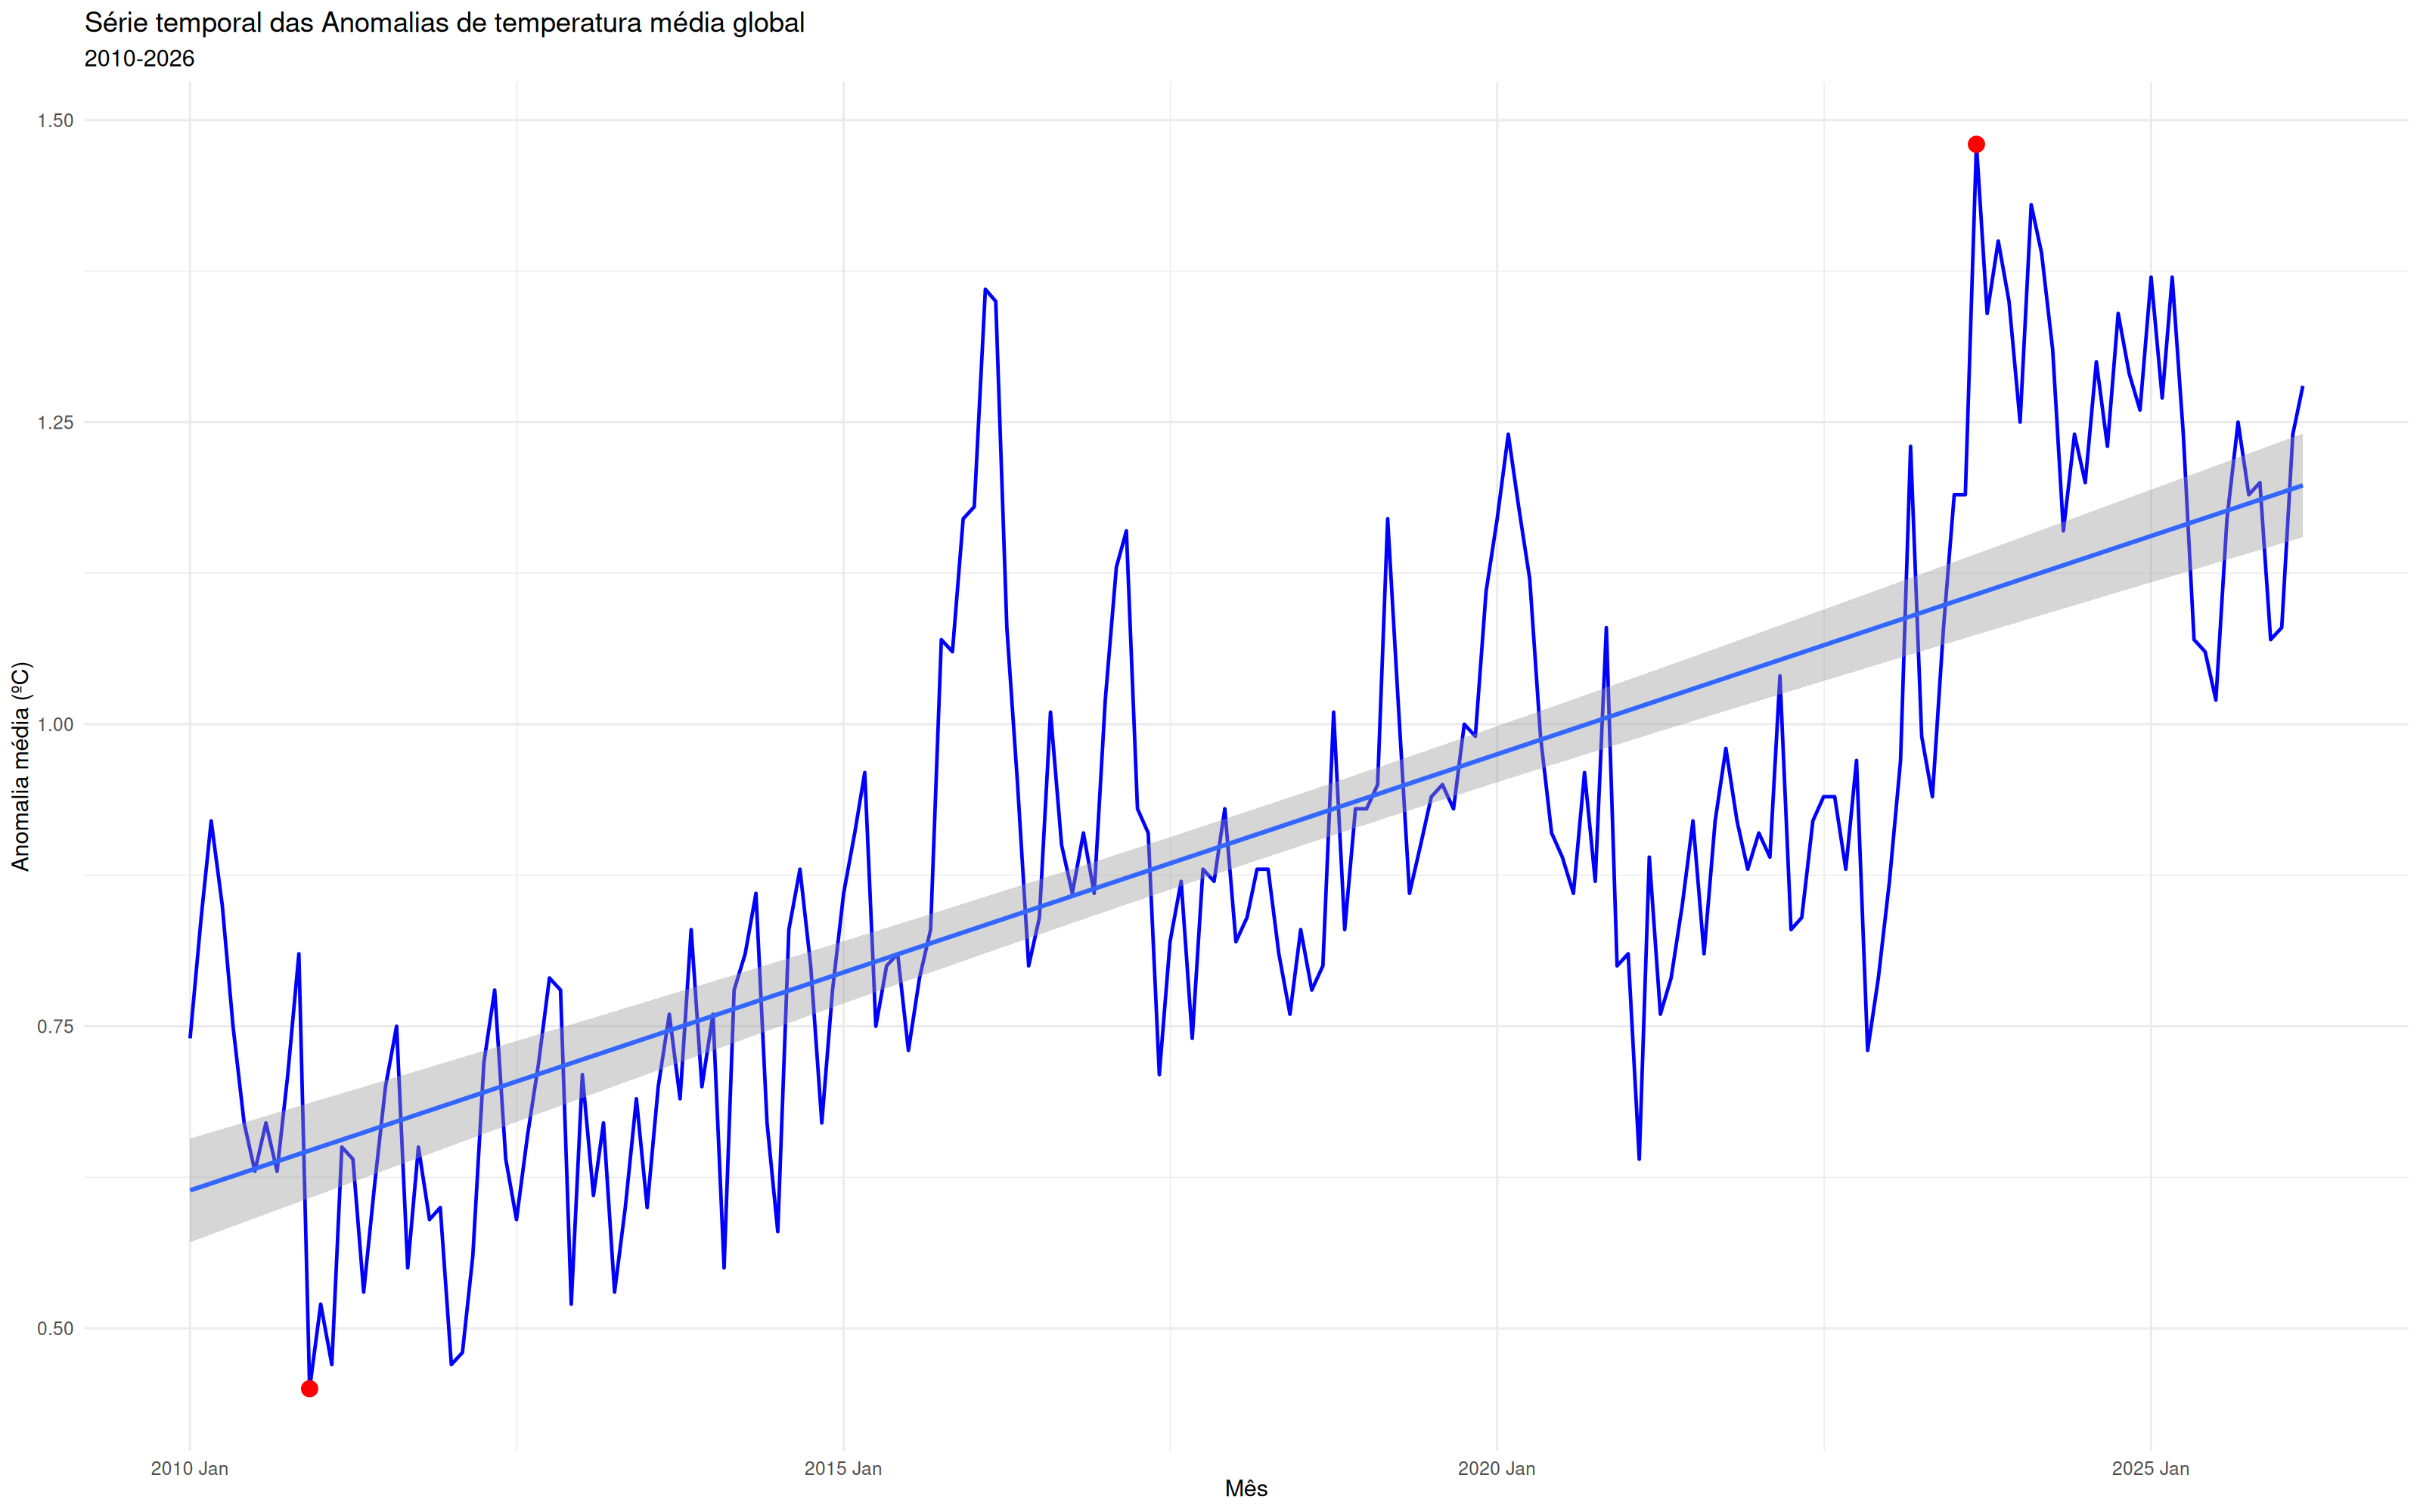

In [8]:
ggplot(ts_m$tsibble, aes(x = Date, y = Mean)) +
  geom_line(color = "blue", linewidth = 0.8) +
  geom_point(data = extremos, aes(x = Date, y = Mean), color = "red", size = 3.2) +
  geom_smooth(method = "lm") +
  labs(title = ts_m$title, subtitle = ts_m$subtitle, x = ts_m$xlabel, y = ts_m$ylabel) +
  theme_minimal()

### Gráfico: Sazonalidade

Dividimos o período de 2015-2026 em dois para facilitar a visualização do gráfico de sazonalidade: 2005-2015 e 2016-2026.

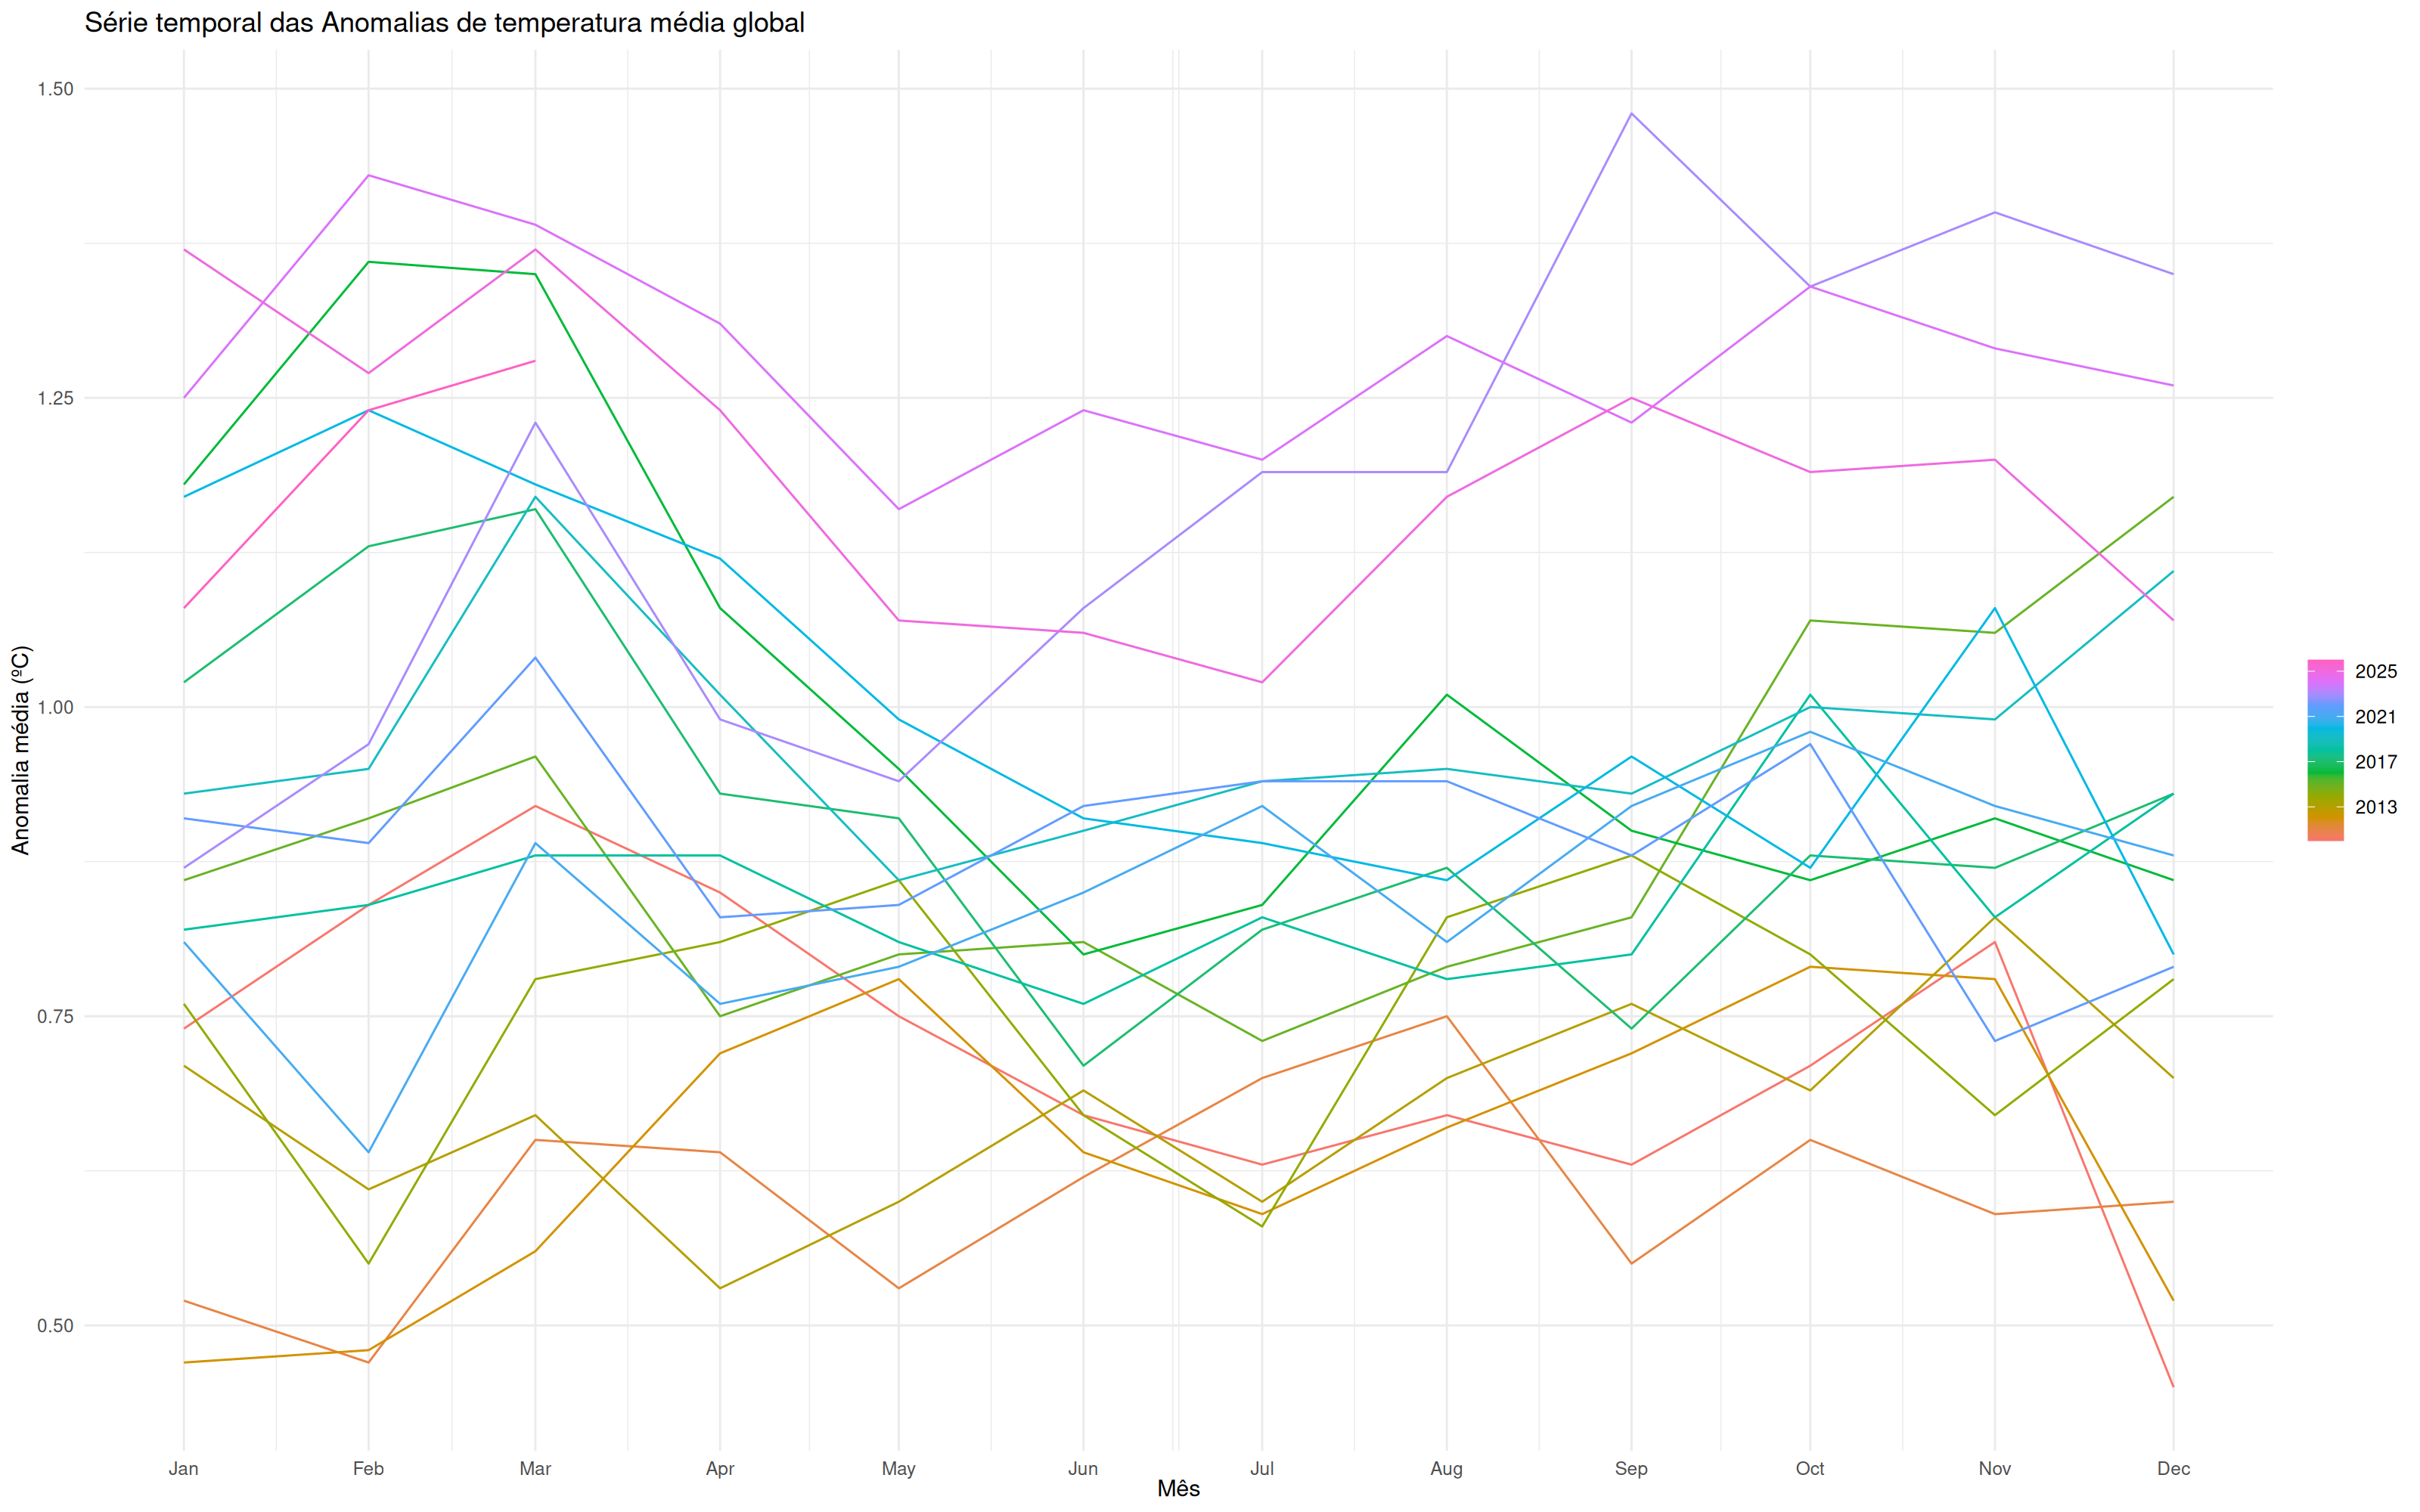

In [9]:
gg_season(ts_m$tsibble,  y = Mean) +
  labs(title = ts_m$title, x = ts_m$xlabel, y = ts_m$ylabel) +
  theme_minimal()

#gg_season(ts_m$tsibble |> filter(Date > yearmonth("2015-12")), y = Mean) +
#  labs(title = ts_m$title, x = ts_m$xlabel, y = ts_m$ylabel) +
#  theme_minimal()

### Gráfico: subséries

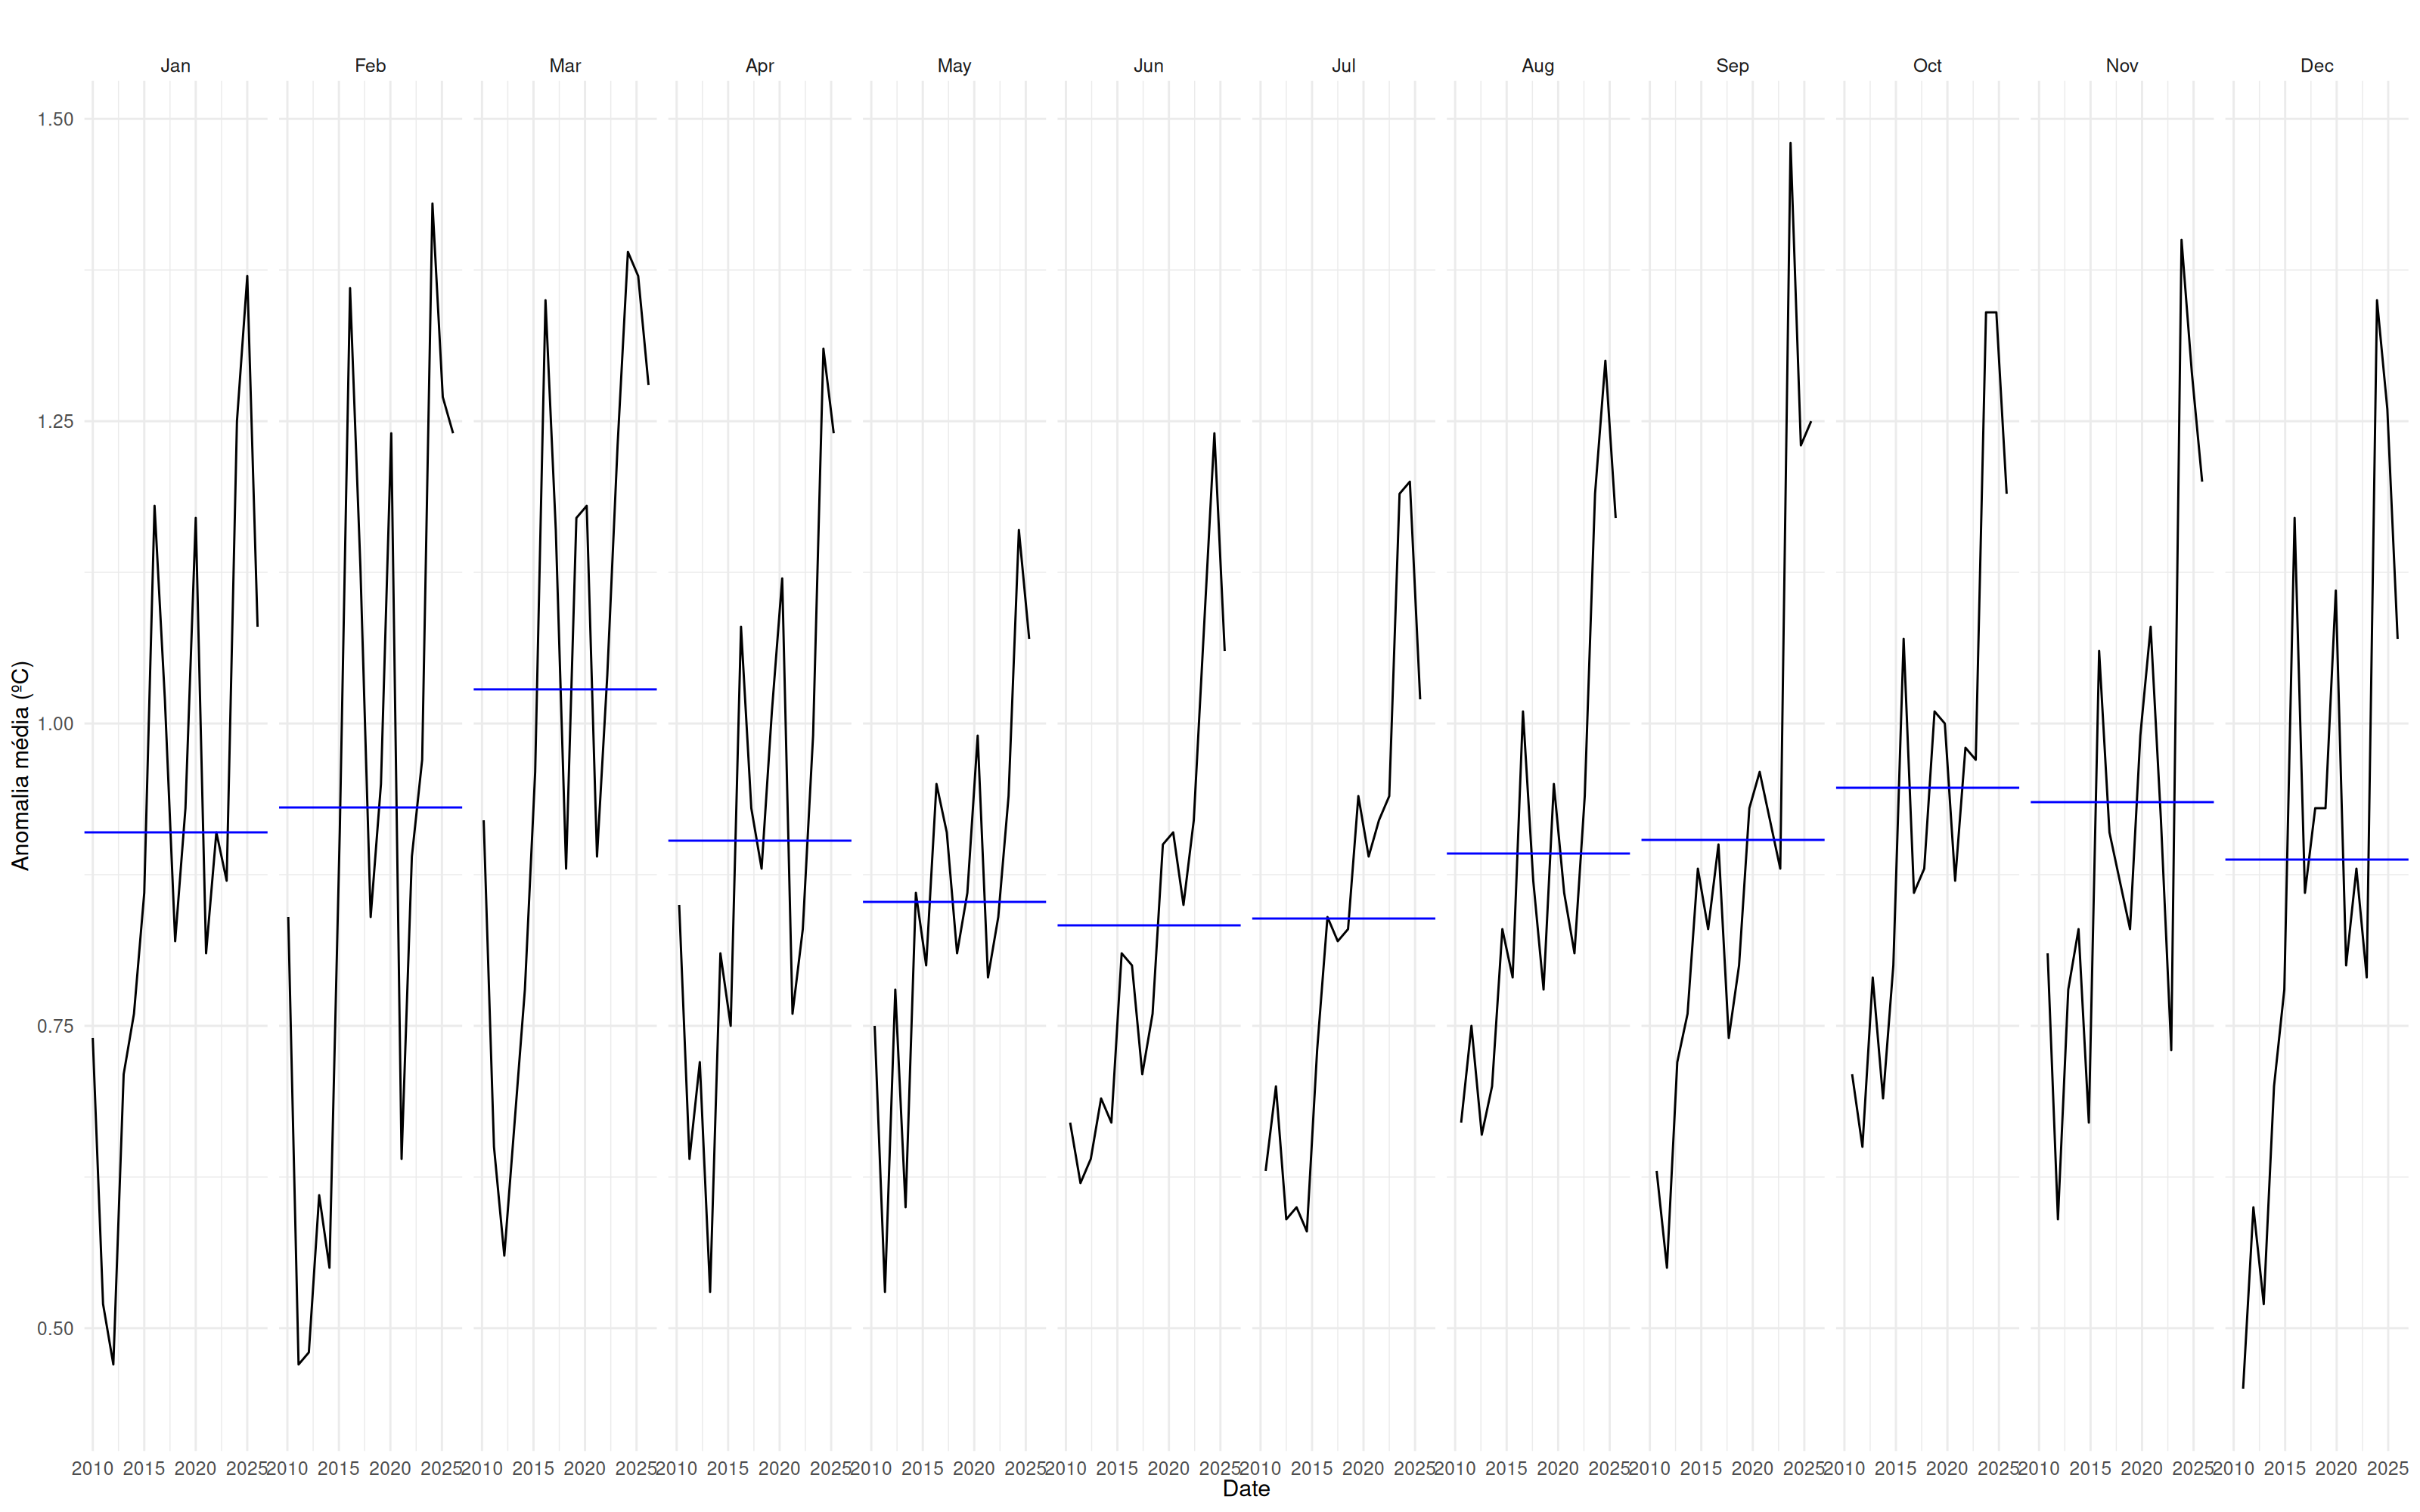

In [10]:
p_sub <- ts_m$tsibble |>
  gg_subseries(Mean) +
  labs(
    title="",
    y = ts_m$ylabel
  ) +
  theme_minimal()
print(p_sub)

### Gráfico: boxplots mensais

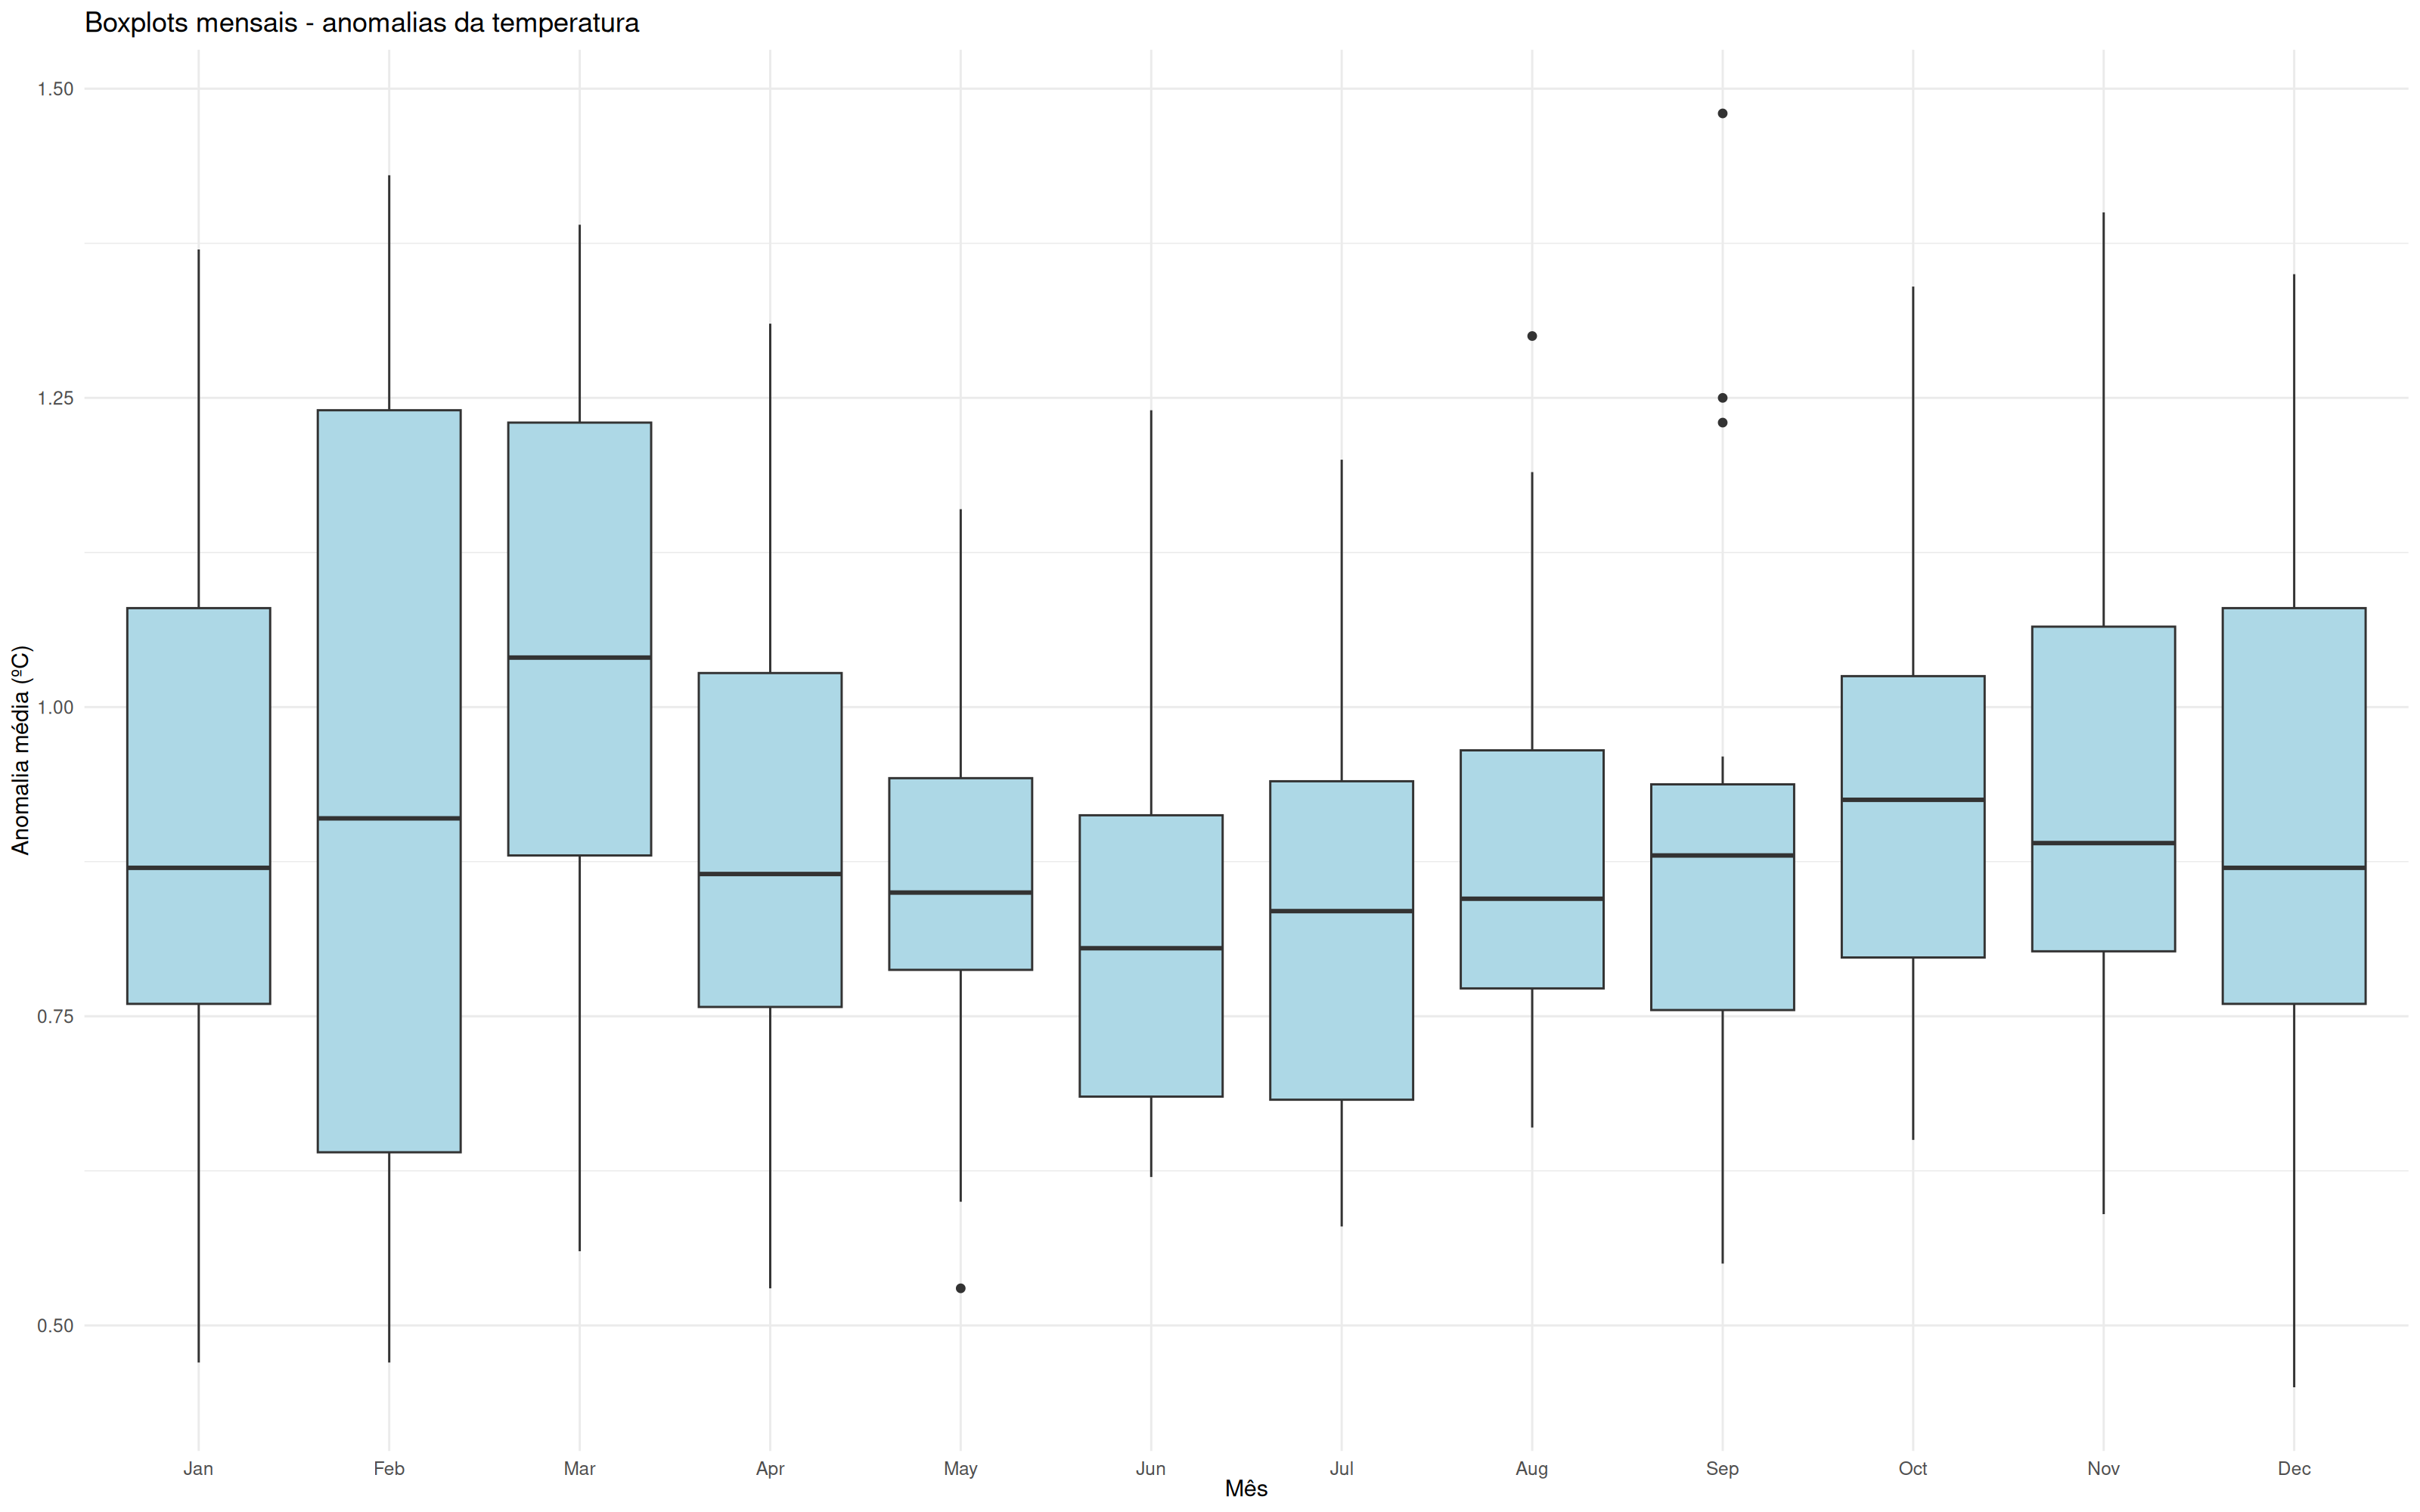

In [11]:
p_box <- ts_m$tsibble |>
  mutate(Mes = factor(month(Date), labels=month.abb)) |>
  ggplot(aes(x=Mes, y=Mean)) +
  geom_boxplot(fill="lightblue") +
  labs(
    title="Boxplots mensais - anomalias da temperatura",
    x = ts_m$xlabel,
    y = ts_m$ylabel
  ) +
  theme_minimal()
print(p_box)

### Gráfico: histograma da série

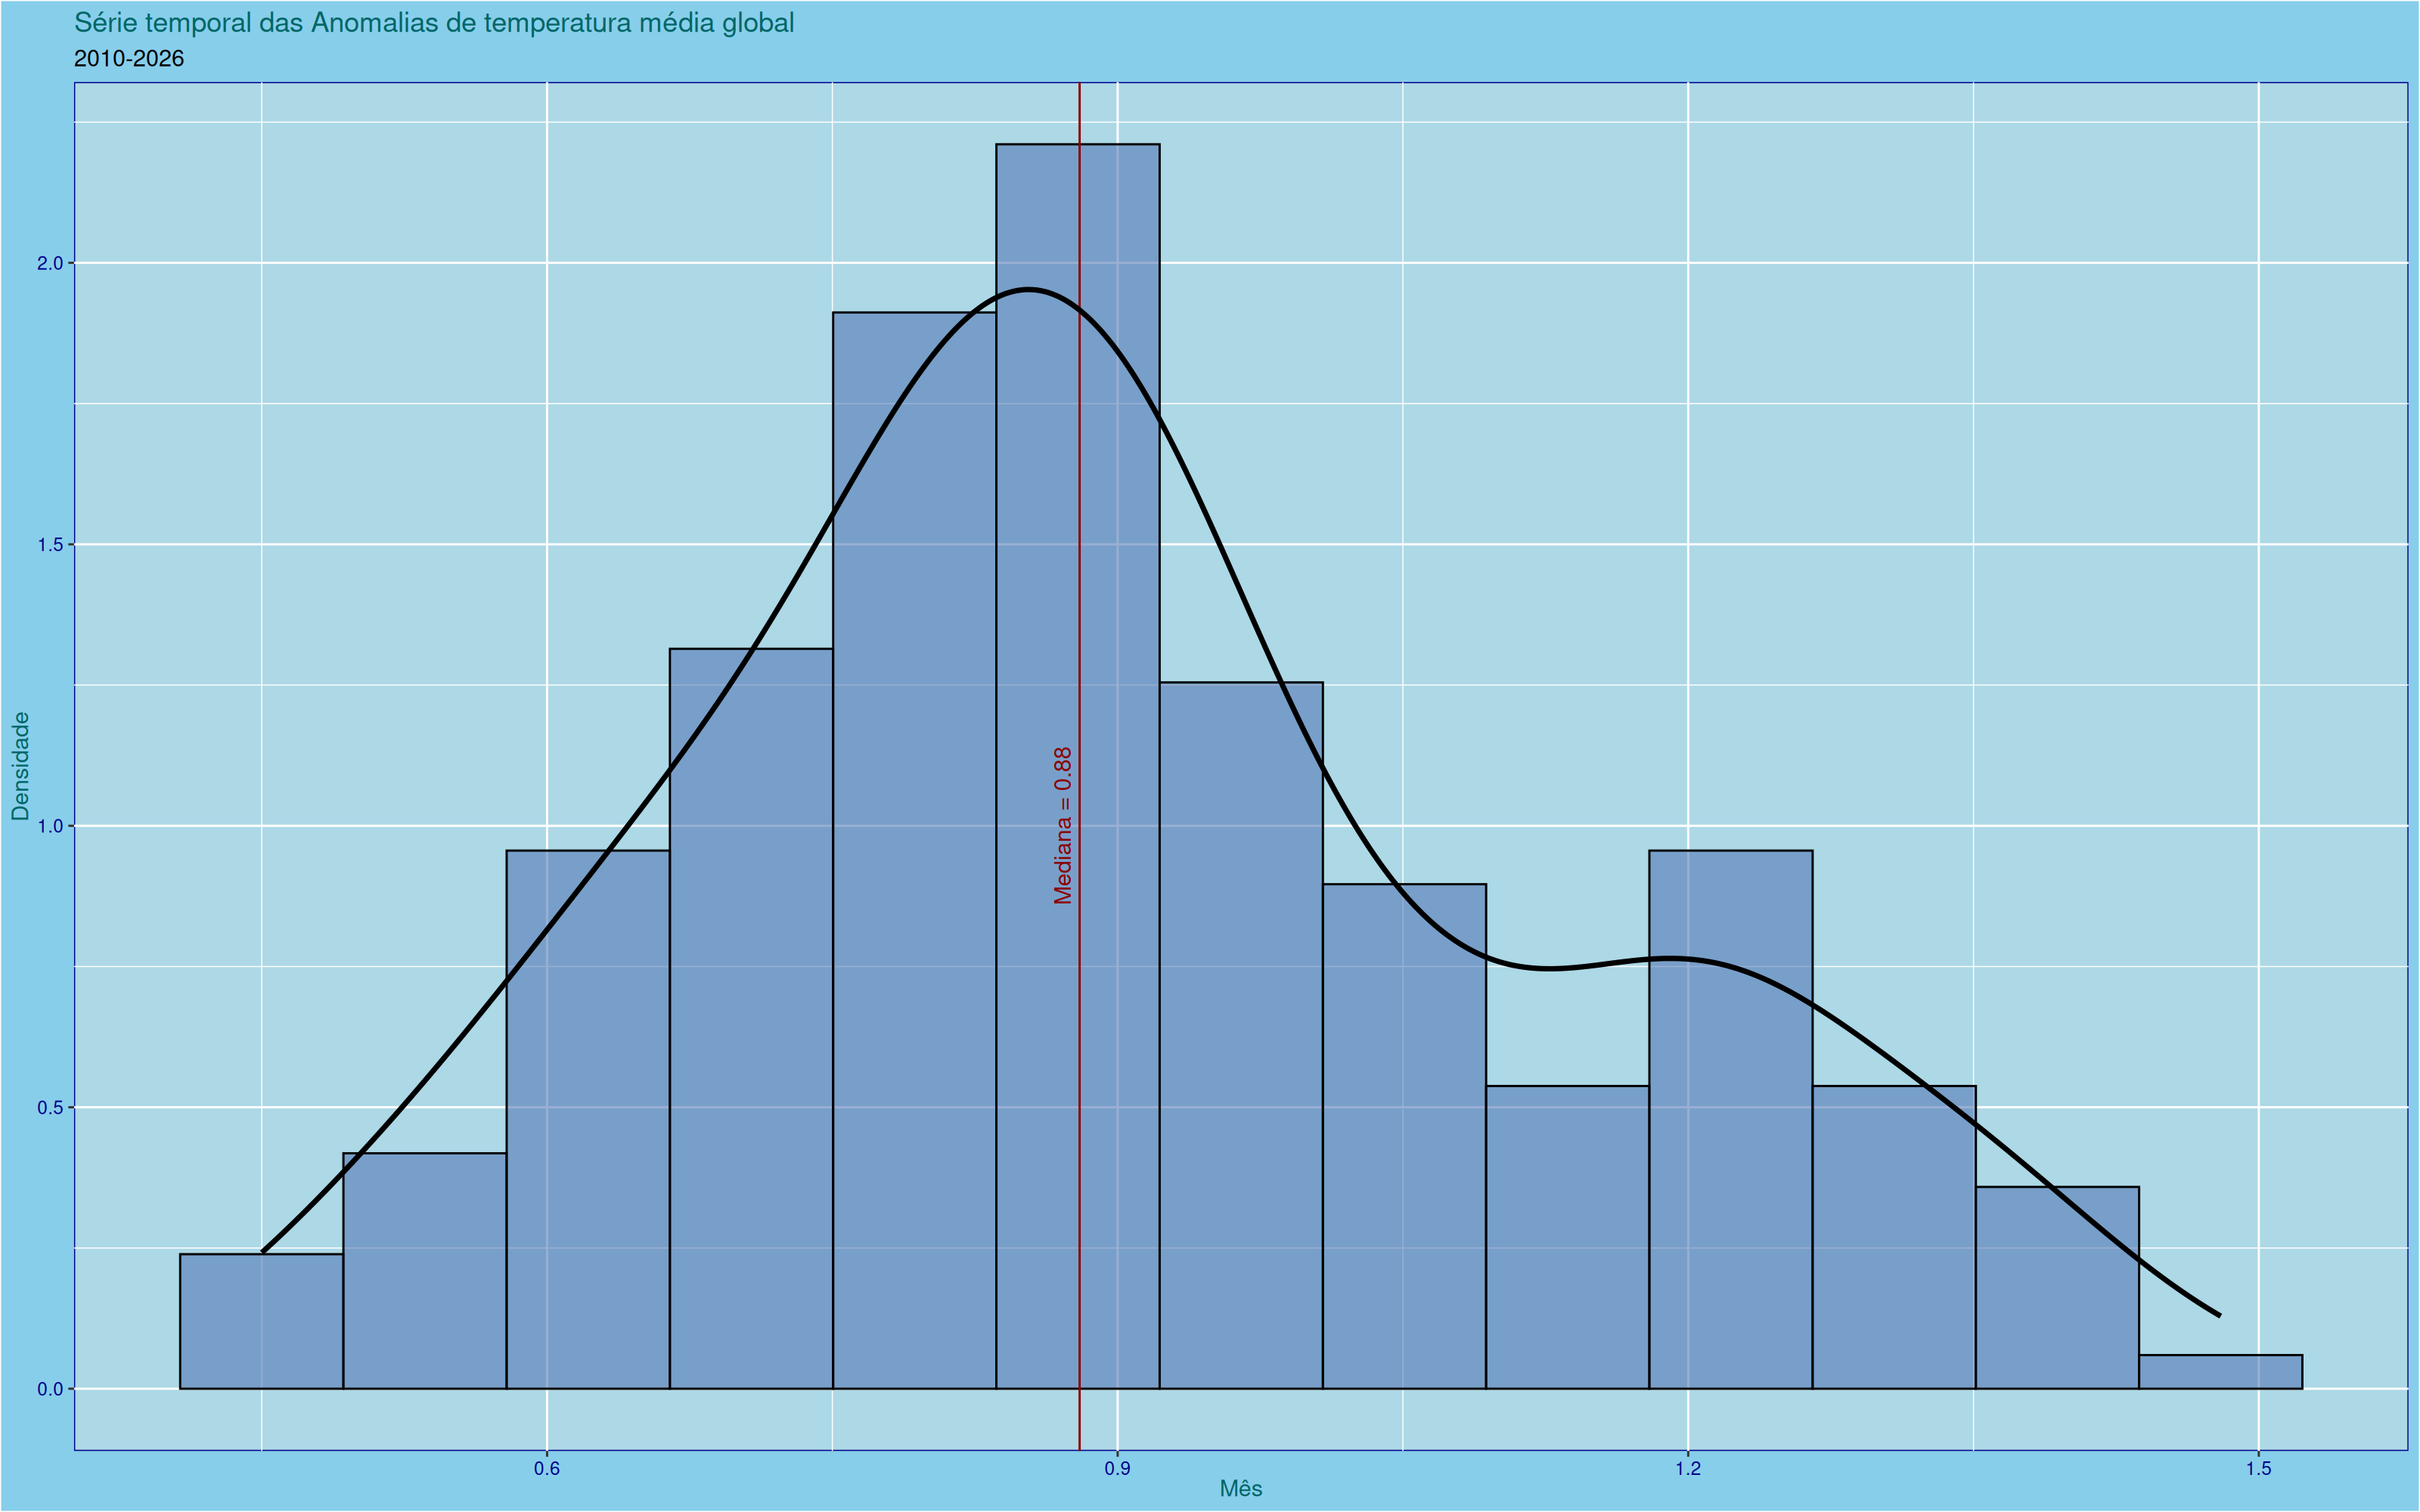

In [12]:
mediana <- summary(ts_m$ts)["Median"]

p_hist <- ts_m$tsibble |>
  ggplot(aes(x=Mean)) +
    geom_histogram(aes(y=after_stat(density)), bins=13, color = "black", fill = "#557ab5", alpha=.6) +
    geom_vline(xintercept = mediana, linetype = "solid", color = "darkred") +
    geom_density(linewidth=1.2) +
    annotate("text", x = mediana - 0.009, y = 1, label = paste("Mediana =", mediana), color = "darkred", angle = 90) +
    labs(
      title = ts_m$title,
      subtitle = ts_m$subtitle,
      x = ts_m$xlabel,
      y = "Densidade"
    ) +
    theme(
      title = element_text(color = "#006666"),
      axis.text.x = element_text(color = "darkblue"), # Change x-axis text color
      axis.text.y = element_text(color = "darkblue"), # Change y-axis text color
      plot.background = element_rect(fill = "skyblue"),
      panel.background = element_rect(fill = "lightblue", color = "darkblue")
    )
print(p_hist)

### Gráfico: decomposição da série temporal

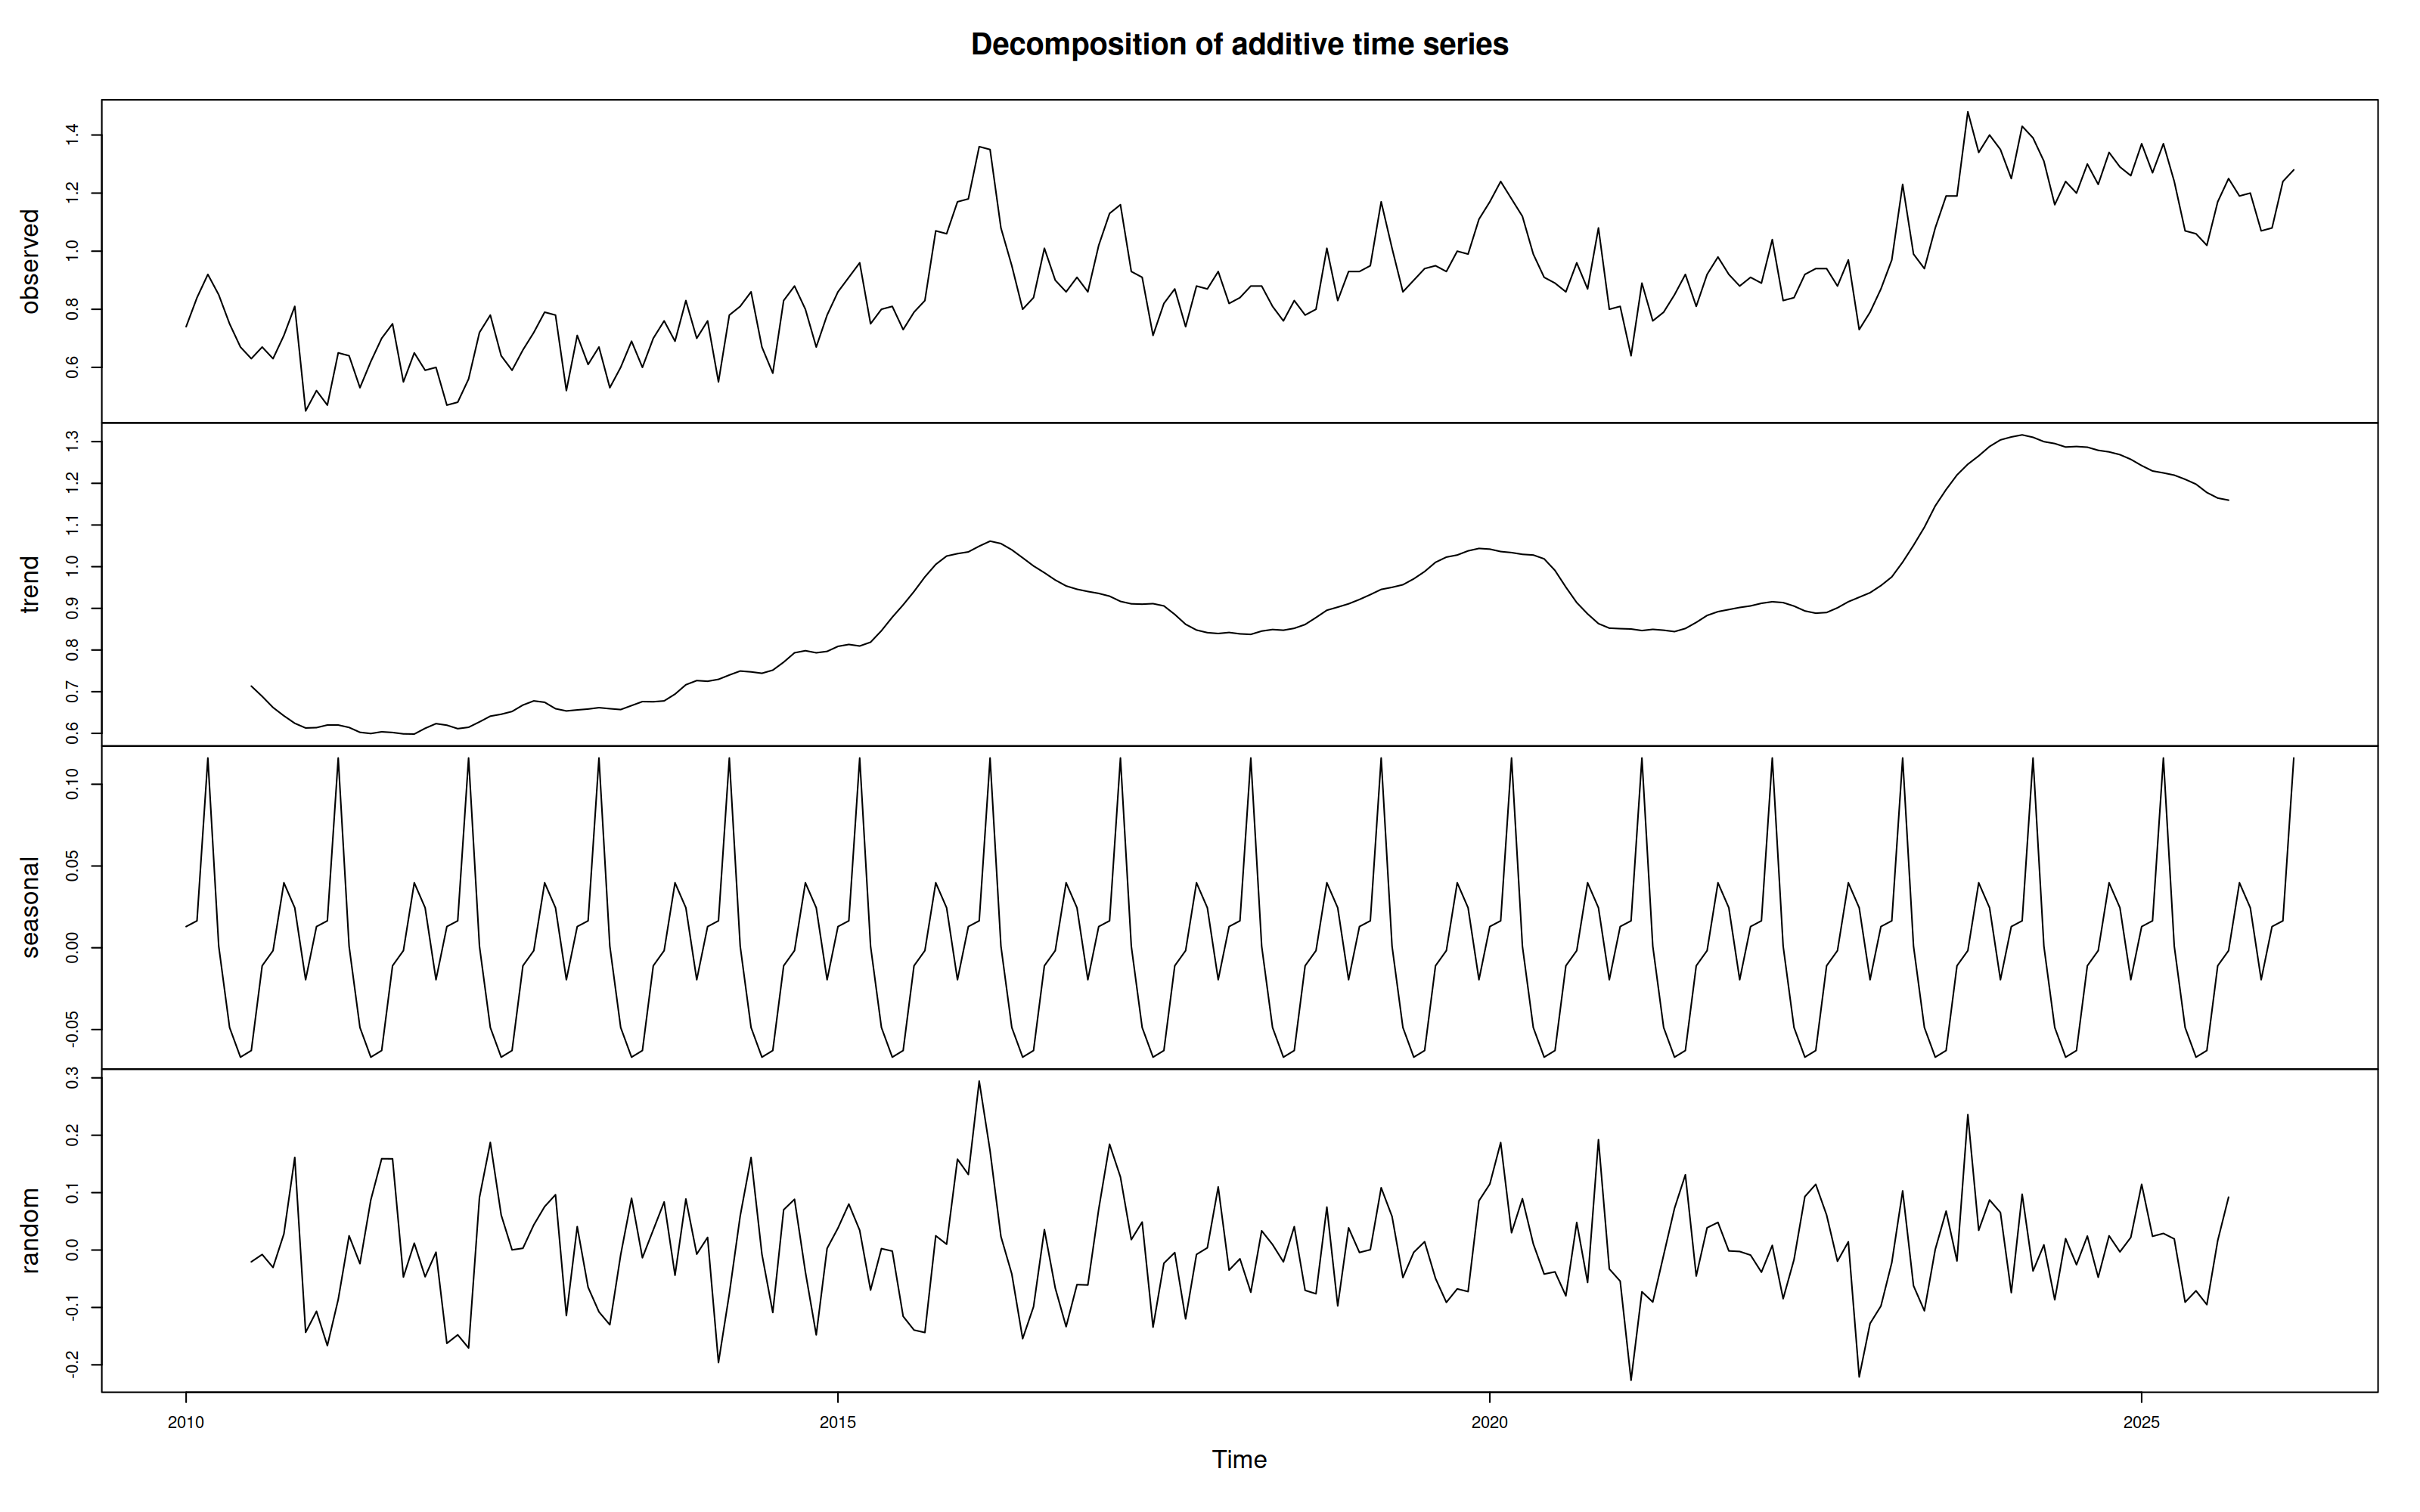

In [13]:
dec <- decompose(ts_m$ts, type="additive")
plot(dec)

### ACF da série original

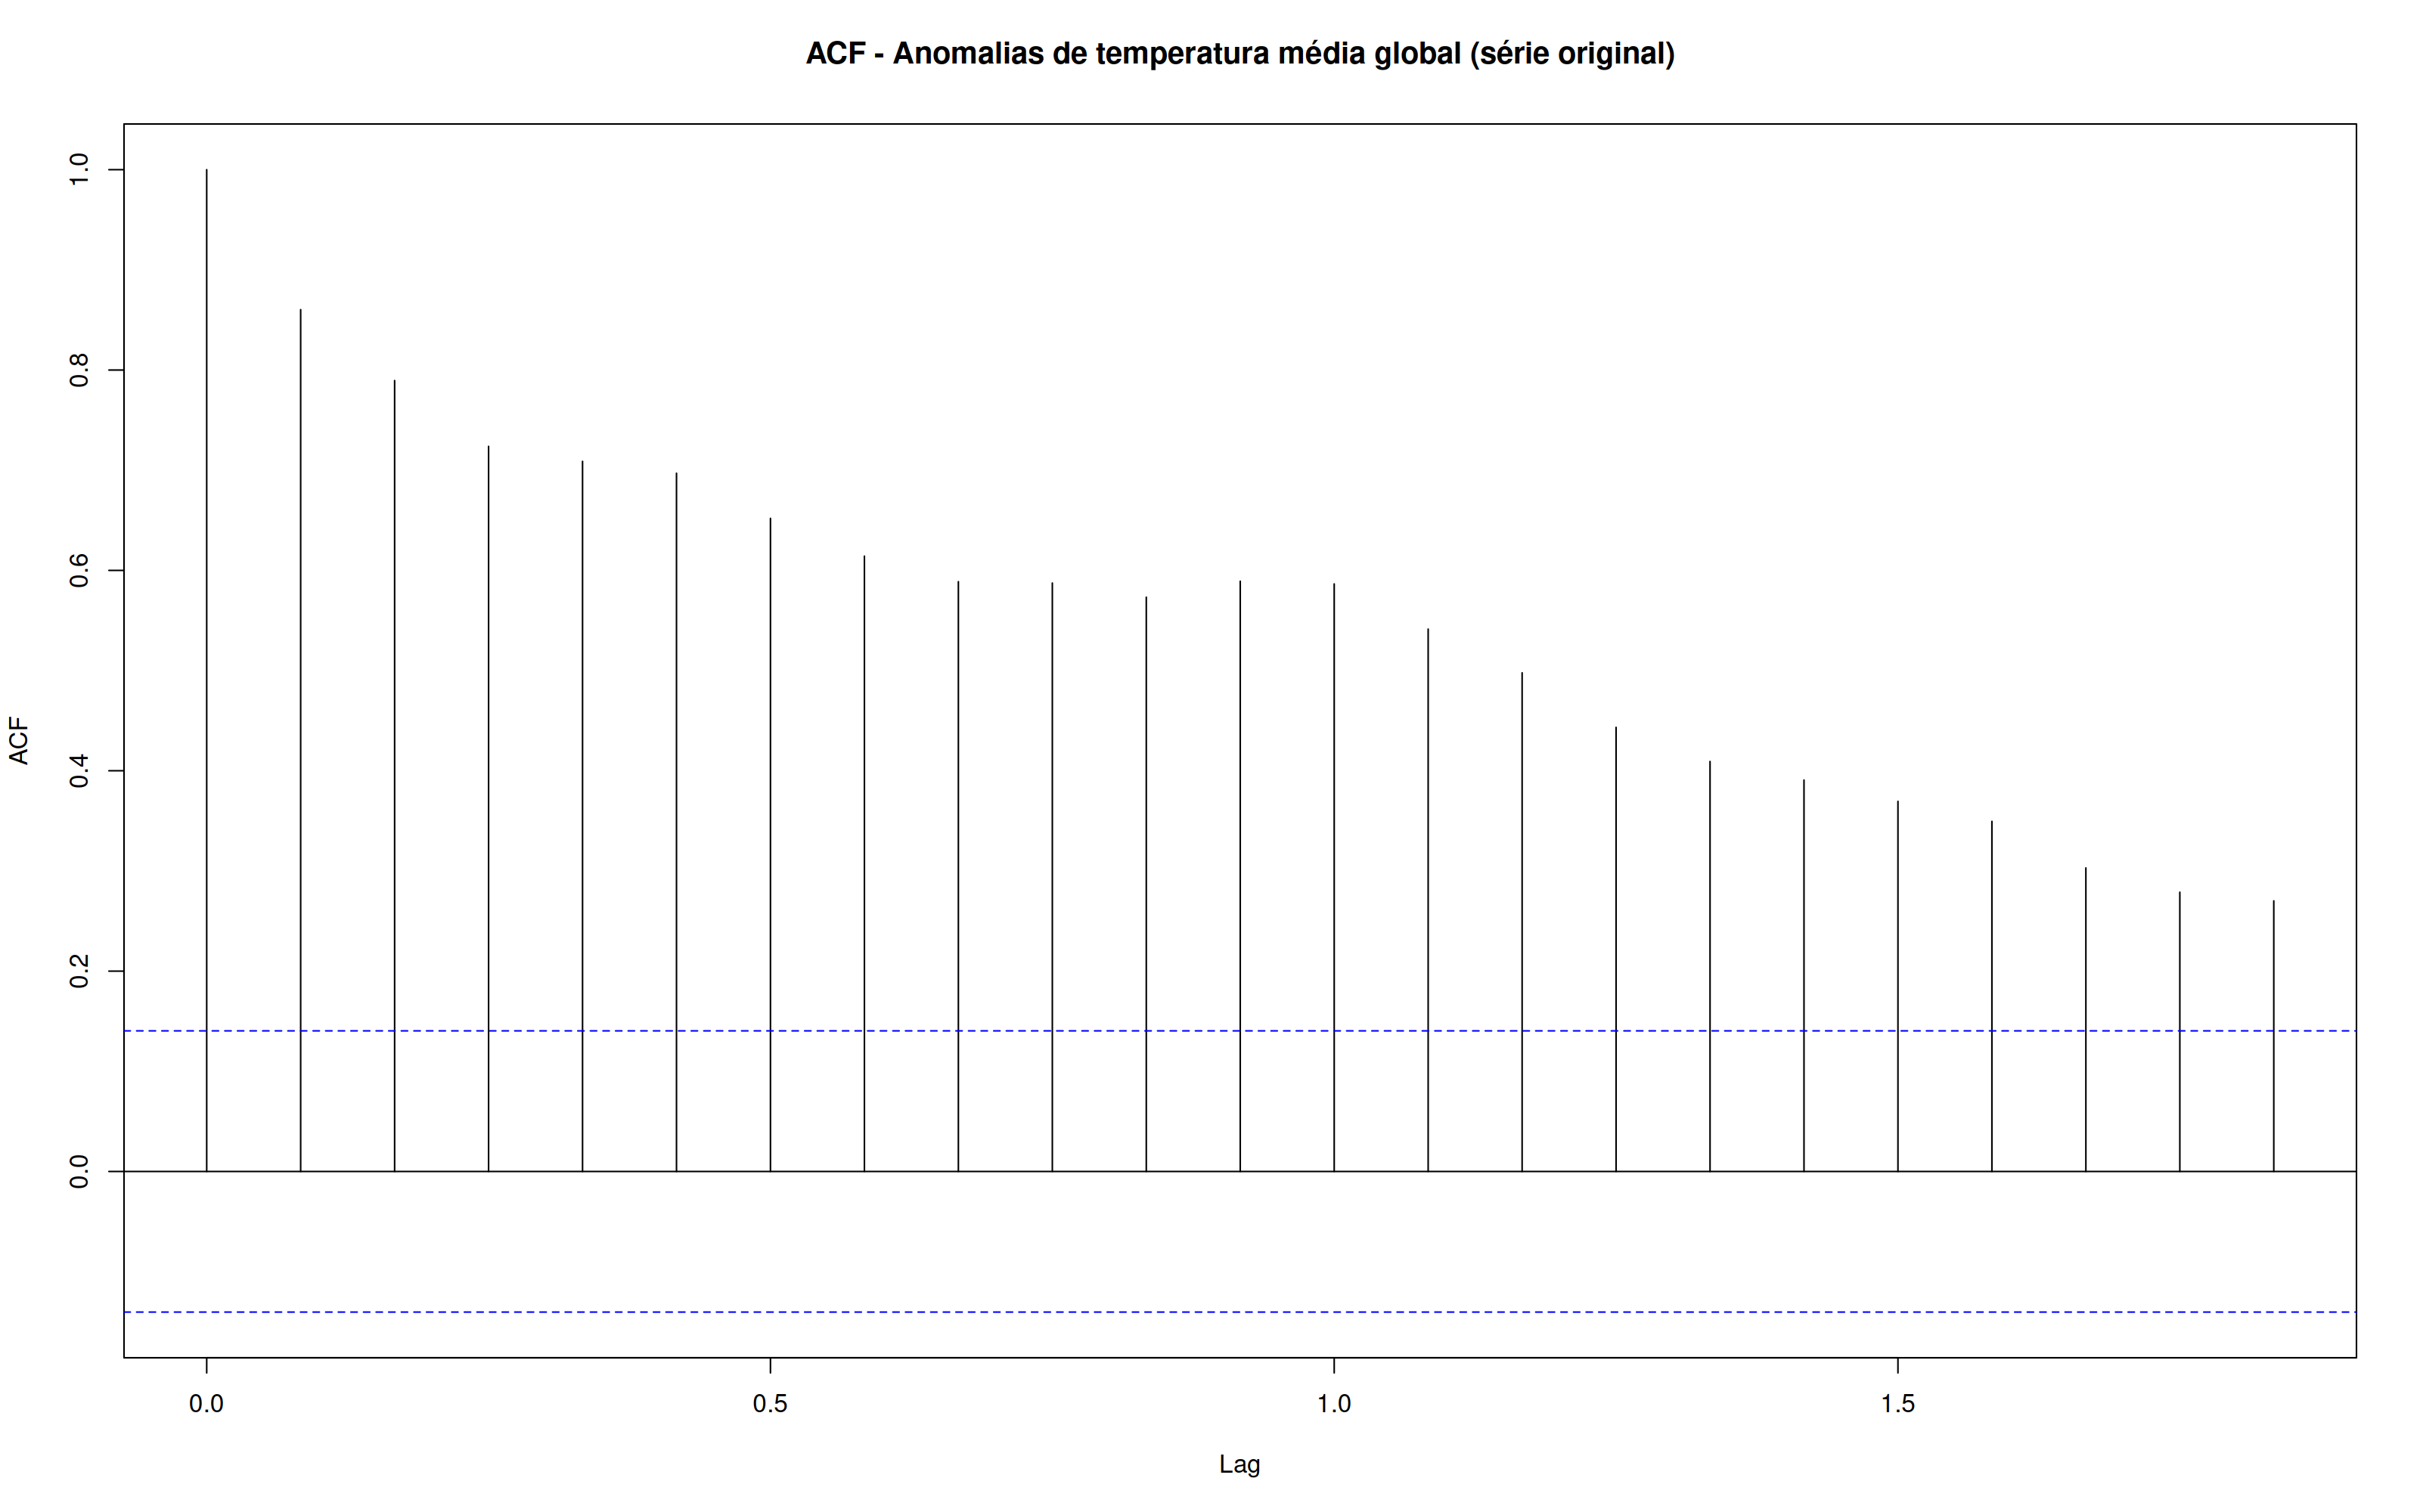

In [14]:
acf(ts_m$ts, main="ACF - Anomalias de temperatura média global (série original)")

### Testes de tendência

In [15]:
mannkendal_obj <- MannKendall(ts_m$ts)
coxstuart_obj <- cs.test(ts_m$ts)

testes_tendencia <- tibble(
  teste = c("Mann-Kendall", "Cox-Stuart"),
  alfa = sig_level,
  p.valor = c(mannkendal_obj$p.value, coxstuart_obj$p.value),
  h0 = c("não há tendência", "não há tendência"),
  reject_h0 = c(mannkendal_obj$p.value < sig_level, coxstuart_obj$p.value < sig_level),
  is_stationary = c(mannkendal_obj$p.value < sig_level, coxstuart_obj$p.value < sig_level)
)

testes_tendencia |>
  gt() |>
	tab_header("Testes de tendência") |>
  cols_label(
    teste = "Teste",
    alfa = "Nível de Significância",
    p.valor = "P-valor",
    h0 = md("$\\mathcal{H}_0$"),
    reject_h0 = md("Rejeitar $\\mathcal{H}_0$?"),
    is_stationary = "Há tendência?"
  ) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(align = "center", columns = everything()) |>
	print_gt()

ts_m$tendency <- TRUE

Shiny tags cannot be represented in plain text (need html)

### Testes de estacionariedade

In [16]:
adf_obj <- adf.test(ts_m$ts)
kpss_obj <- kpss.test(ts_m$ts)
pp_obj <- pp.test(ts_m$ts)

testes_estacionariedade <- tibble(
  teste = c("ADF", "KPSS", "PP"),
  alfa = sig_level,
  p.valor = c(adf_obj$p.value, kpss_obj$p.value, pp_obj$p.value),
  h0 = c("não estacionária", "estacionária", "não estacionária"),
  reject_h0 = c(adf_obj$p.value < sig_level, kpss_obj$p.value < sig_level, pp_obj$p.value < sig_level),
  is_stationary = c(adf_obj$p.value < sig_level, kpss_obj$p.value > sig_level, pp_obj$p.value < sig_level)
)

testes_estacionariedade |>
  gt() |>
	tab_header("Testes de estacionariedade") |>
  cols_label(
    teste = "Teste",
    alfa = "Nível de Significância",
    p.valor = "P-valor",
    h0 = md("$\\mathcal{H}_0$"),
    reject_h0 = md("Rejeitar $\\mathcal{H}_0$?"),
    is_stationary = "É estacionária?"
  ) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(align = "center", columns = everything()) |>
	print_gt()

ts_m$stationary <- FALSE

Warning message in kpss.test(ts_m$ts):
“p-value smaller than printed p-value”
Warning message in pp.test(ts_m$ts):
“p-value smaller than printed p-value”


Shiny tags cannot be represented in plain text (need html)

Apenas um dos testes, o **KPSS**, indica que a série é não estacionária. Temos também que o comando **ndiffs** indica a necessidade de pelo menos uma diferenciação.

In [17]:
data.frame(ndiffs = ndiffs(ts_m$ts), nsdiffs = nsdiffs(ts_m$ts)) |>
	gt() |>
	cols_label(
		ndiffs = "componente sistemática",
		nsdiffs = "componente sazonal"
	) |>
	tab_header("Número de diferenciações da série por componente") |>
  tab_options(
    table.width = "50%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

### Testes de sazonalidade

In [18]:
res_qs <- qs(ts_m$ts)
res_kw <- kw(ts_m$ts)
res_sd <- seasdum(ts_m$ts)

p_qs <- res_qs$Pval
p_kw <- res_kw$Pval
p_sd <- res_sd$Pval

data.frame(
  test = c("QS", "Kruskal-Wallis", "Dummies"),
  p.value = c(p_qs, p_kw, p_sd),
  h0 = rep("não sazonal", 3)
  ) |>
  mutate(reject_h0 = p.value < sig_level) |>
  mutate(is_seasonal = p.value < sig_level) |>
  add_row(test = "Combined", p.value = NA, h0 = "", reject_h0 = NA, is_seasonal = isSeasonal(ts_m$ts)) |>
 gt() |>
 cols_label(
    test = "Teste",
    p.value = "P-valor",
    h0 = md("$\\mathcal{H}_0$"),
    reject_h0 = md("Rejeitar $\\mathcal{H}_0$?"),
    is_seasonal = "É sazonal?"
 ) |>
 tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
	) |>
	cols_align(columns = everything(), align = "center") |>
	print_gt()

ts_m$seasonal <- TRUE

Teste,P-valor,H0\mathcal{H}_0H0​,Rejeitar H0\mathcal{H}_0H0​?,É sazonal?
QS,0.00225976852,não sazonal,TRUE,TRUE
Kruskal-Wallis,0.00021325823,não sazonal,TRUE,TRUE
Dummies,0.00000185019,não sazonal,TRUE,TRUE
Combined,NA,,NA,TRUE


Todos os testes indicam que a série possui componente sazonal.

## Série auxiliar

A série de **Índice de temperatura da superfície do mar (TSM) Niño 3.4 do NOAA ERSST V5** mede as anomalias médias da temperatura da superfície do mar em uma região específica do Oceano Pacífico equatorial central-leste: a região Niño 3.4, que está localizada entre 5°N-5°S e 170°W-120°W.

A região **Niño 3.4** serve de termômetro para monitorar os fenônemos ciglobais **El Niño** e **La Niña**.

- El Niño: caracteriza o fenômemo climático em que as temperaturas da superfície do mar permanecem iguais ou acima de $0.5$ºC da média durante 5 meses consecutivos;
- La Niña:  caracteriza o fenômemo climático em que as temperaturas da superfície do mar permanecem iguais ou abaixo de $-0.5$ºC da média durante 5 meses consecutivos;

Esta série será utilizada como variável exógena para o ajuste de modelos ARIMAX da série principal.

Fonte: [Nino34_CPC](https://psl.noaa.gov/data/timeseries/month/DS/Nino34_CPC/)

### Algumas observações da série auxiliar

In [19]:
nina34 <- import("db/nina34.anom.csv", HEADER = TRUE) |>
  mutate(Date = yearmonth(Date)) |>
  filter(Date >= yearmonth("2010-01"), Date < yearmonth("2026-04")) |>
	mutate(Mean = parse_number(Mean, locale = locale(decimal_mark = ","))) |>
	na.omit()

tail(nina34) |>
  gt() |>
	tab_header("Algumas observações das anomalias das temperaturas") |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(align = "center", columns = everything()) |>
	print_gt()

stopifnot(length(nina34$Mean) == length(ts_m$ts))

Shiny tags cannot be represented in plain text (need html)

### Medidas descritivas

In [20]:
summary(nina34$Mean) |>
  as.list() |>
  as.data.frame() |>
  relocate(Mean, .after = "Max.") |>
  mutate(sd = sd(ts_m$ts)) |>
  mutate(cv = sd / Mean) |>
  gt() |>
	tab_header("Principais medidas descritivas da série") |>
  cols_label(
    X1st.Qu. = md("1º Quartil"),
    Median = "Mediana",
    X3rd.Qu. = "3º Quartil",
    Mean = "Média",
    sd = "Desvio-Padrão",
    cv = "Coeficiente de Variação"
  ) |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

quantile(nina34$Mean) |>
  as.list() |>
  as.data.frame() |>
  gt() |>
	tab_header("Quantis da série") |>
  cols_label(
    X0. = "0%",
    X25. = "25%",
    X50. = "50%",
    X75. = "75%",
    X100. = "100%",
  ) |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

Shiny tags cannot be represented in plain text (need html)

### Valores extremos

In [21]:
extremos <- nina34 |>
  filter(Mean == max(Mean, na.rm = TRUE) | Mean == min(Mean, na.rm = TRUE)) |>
  arrange(Mean) |>
  select(Date, Mean)

extremos |>
  gt() |>
	tab_header("Valores extremos da série") |>
  cols_align(align = "center", columns = everything()) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

`geom_smooth()` using formula = 'y ~ x'


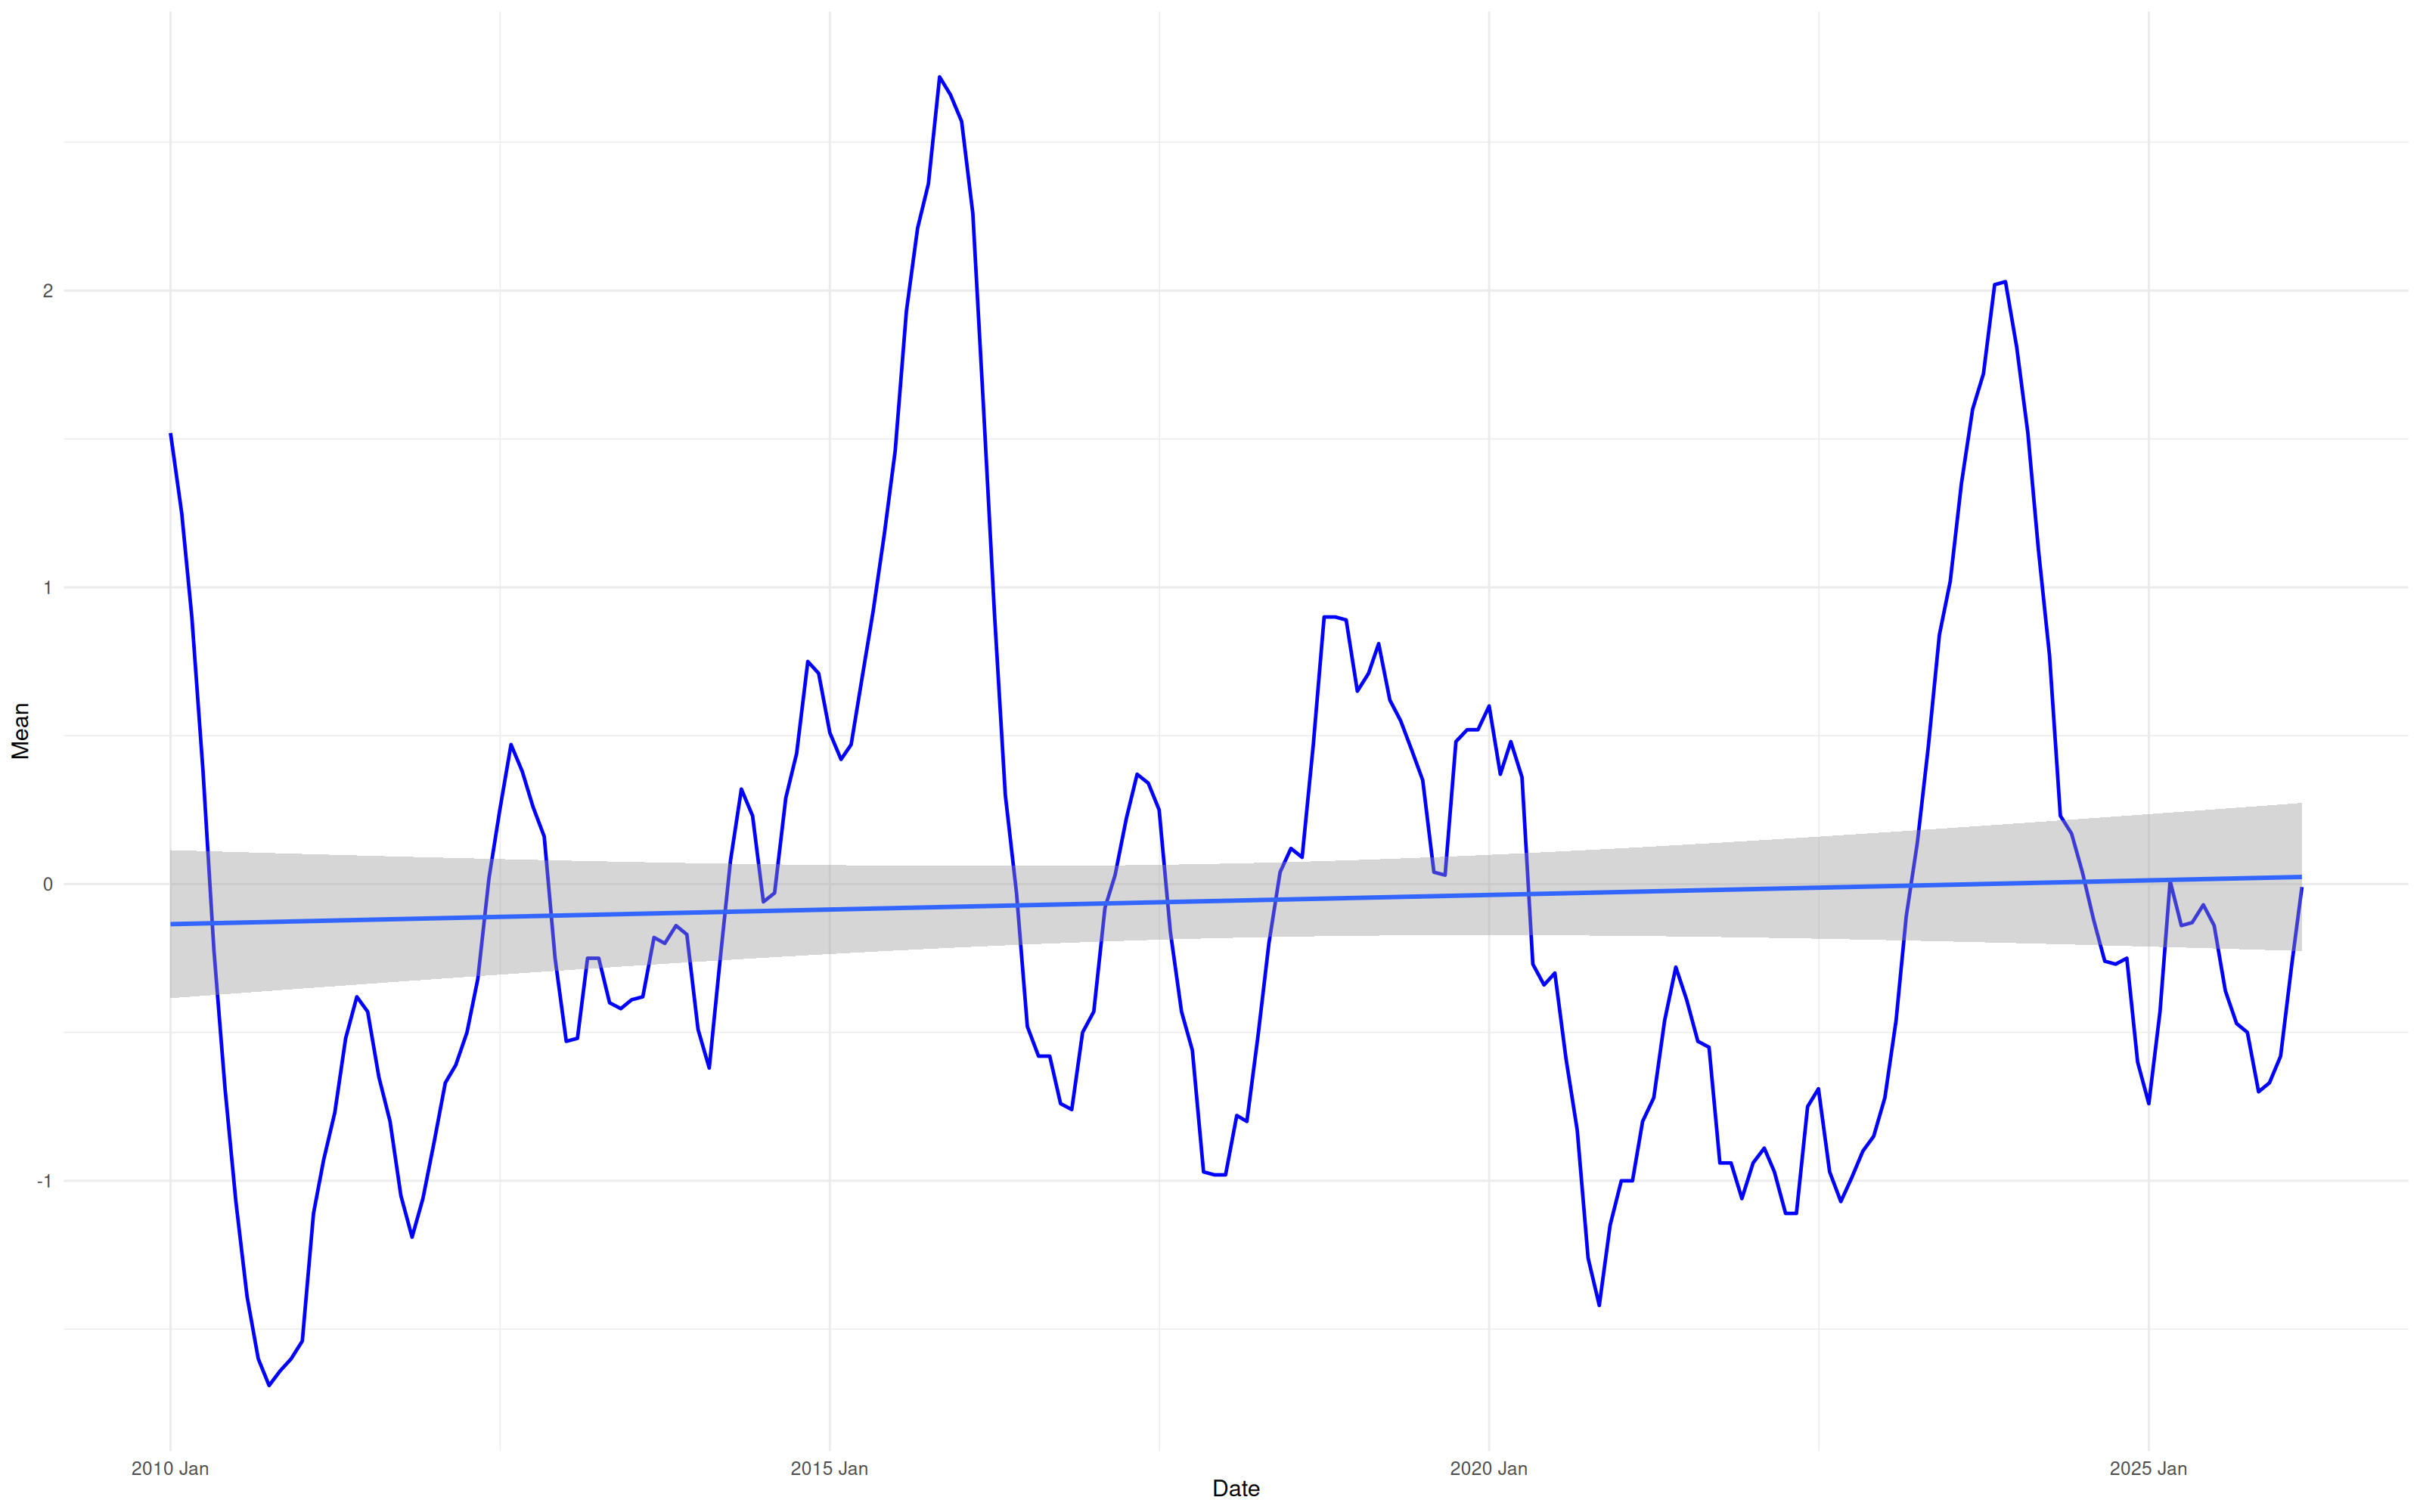

In [22]:


ggplot(data.frame(nina34), aes(x = Date, y = Mean)) +
  geom_line(color = "blue", linewidth = 0.8) +
#  geom_point(data = extremos, aes(x = Date, y = Mean), color = "red", size = 3.2) +
  geom_smooth(method = "lm") +
  theme_minimal()

# Ajustando modelos para a série

Vamos ajustar alguns modelos para a série temporal. Inicialmente, selecionaremos um modelo ARIMA com menor critério AIC e um modelo ARIMA com menor critério BIC.
Em seguida repetiremos o procedimento para dois modelos ARIMAX com o mesmo critério.

## Modelos ARIMA

### AIC

In [23]:
ts_m$models <- c(
  ajusta_modelo(ts_m$ts, "aic", 1, sig_level = 0.05, xreg = NULL),
  ajusta_modelo(ts_m$ts, "bic", 1, sig_level = 0.05, xreg = NULL)
)

Warning message in executa_auto(ts_series, criterio, n, xreg = xreg):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "aic", 1, sig_level = 0.05, xreg = NULL):
“NAs introduced by coercion”
Warning message in executa_auto(ts_series, criterio, n, xreg = xreg):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "bic", 1, sig_level = 0.05, xreg = NULL):
“NAs introduced by coercion”


In [24]:
## Ajustar modelos ARIMA sem regressão

ts_m$models <- c(
  ajusta_modelo(ts_m$ts, "aic", 1, sig_level = 0.05, xreg = NULL),
  ajusta_modelo(ts_m$ts, "bic", 1, sig_level = 0.05, xreg = NULL)
)

ts_m$models[[1]]$name <- sprintf(
  "SARIMA(%d,%d,%d)(%d,%d,%d)[%d] (AIC)",
  ts_m$models[[1]]$orders["p"],
  ts_m$models[[1]]$orders["d"],
  ts_m$models[[1]]$orders["q"],
  ts_m$models[[1]]$orders["P"],
  ts_m$models[[1]]$orders["D"],
  ts_m$models[[1]]$orders["Q"],
  ts_m$freq
)

ts_m$models[[2]]$name <- sprintf(
  "ARIMA(%d,%d,%d)(%d,%d,%d)[%d] (BIC)",
  ts_m$models[[2]]$orders["p"],
  ts_m$models[[2]]$orders["d"],
  ts_m$models[[2]]$orders["q"],
  ts_m$models[[2]]$orders["P"],
  ts_m$models[[2]]$orders["D"],
  ts_m$models[[2]]$orders["Q"],
  ts_m$freq
)

Warning message in executa_auto(ts_series, criterio, n, xreg = xreg):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "aic", 1, sig_level = 0.05, xreg = NULL):
“NAs introduced by coercion”
Warning message in executa_auto(ts_series, criterio, n, xreg = xreg):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "bic", 1, sig_level = 0.05, xreg = NULL):
“NAs introduced by coercion”


In [25]:
resumo_modelos_arima <- tibble(
  Modelo = c(ts_m$models[[1]]$name, ts_m$models[[2]]$name),
  p = c(ts_m$models[[1]]$orders["p"], ts_m$models[[2]]$orders["p"]),
  d = c(ts_m$models[[1]]$orders["d"], ts_m$models[[2]]$orders["d"]),
  q = c(ts_m$models[[1]]$orders["q"], ts_m$models[[2]]$orders["q"]),
  P = c(ts_m$models[[1]]$orders["P"], ts_m$models[[2]]$orders["P"]),
  D = c(ts_m$models[[1]]$orders["D"], ts_m$models[[2]]$orders["D"]),
  Q = c(ts_m$models[[1]]$orders["Q"], ts_m$models[[2]]$orders["Q"])
)

resumo_modelos_arima |>
  gt() |>
	tab_header("Modelos ARIMA obtidos") |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(align = "center", columns = everything()) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

#### Teste dos coeficientes

In [26]:
ncoef <-  ts_m$models[[1]]$orders["p"] + ts_m$models[[1]]$orders["q"] + ts_m$models[[1]]$orders["P"] + ts_m$models[[1]]$orders["Q"]

coef_test <- as.data.frame(coeftest(ts_m$models[[1]]$fit)[1:ncoef, ])
coef_test <- mutate(.data = coef_test, coefficients = rownames(coef_test), .before = 1)

coef_test |>
  gt(rowname_col = "coefficients") |>
	tab_header(sprintf("Teste dos coeficientes: %s", ts_m$models[[1]]$name)) |>
  tab_options(
      table.width = "70%",
      table.background.color = "rgba(0, 0, 0, 0)",
      table.font.color.light = "black",
      table.font.weight = "700",
      column_labels.background.color = "#eeeeee",
      column_labels.font.weight = "bold",
      column_labels.font.size = "1.12rem",
      column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

#### Gráfico: valores reais vs valores ajustados (in-sample)

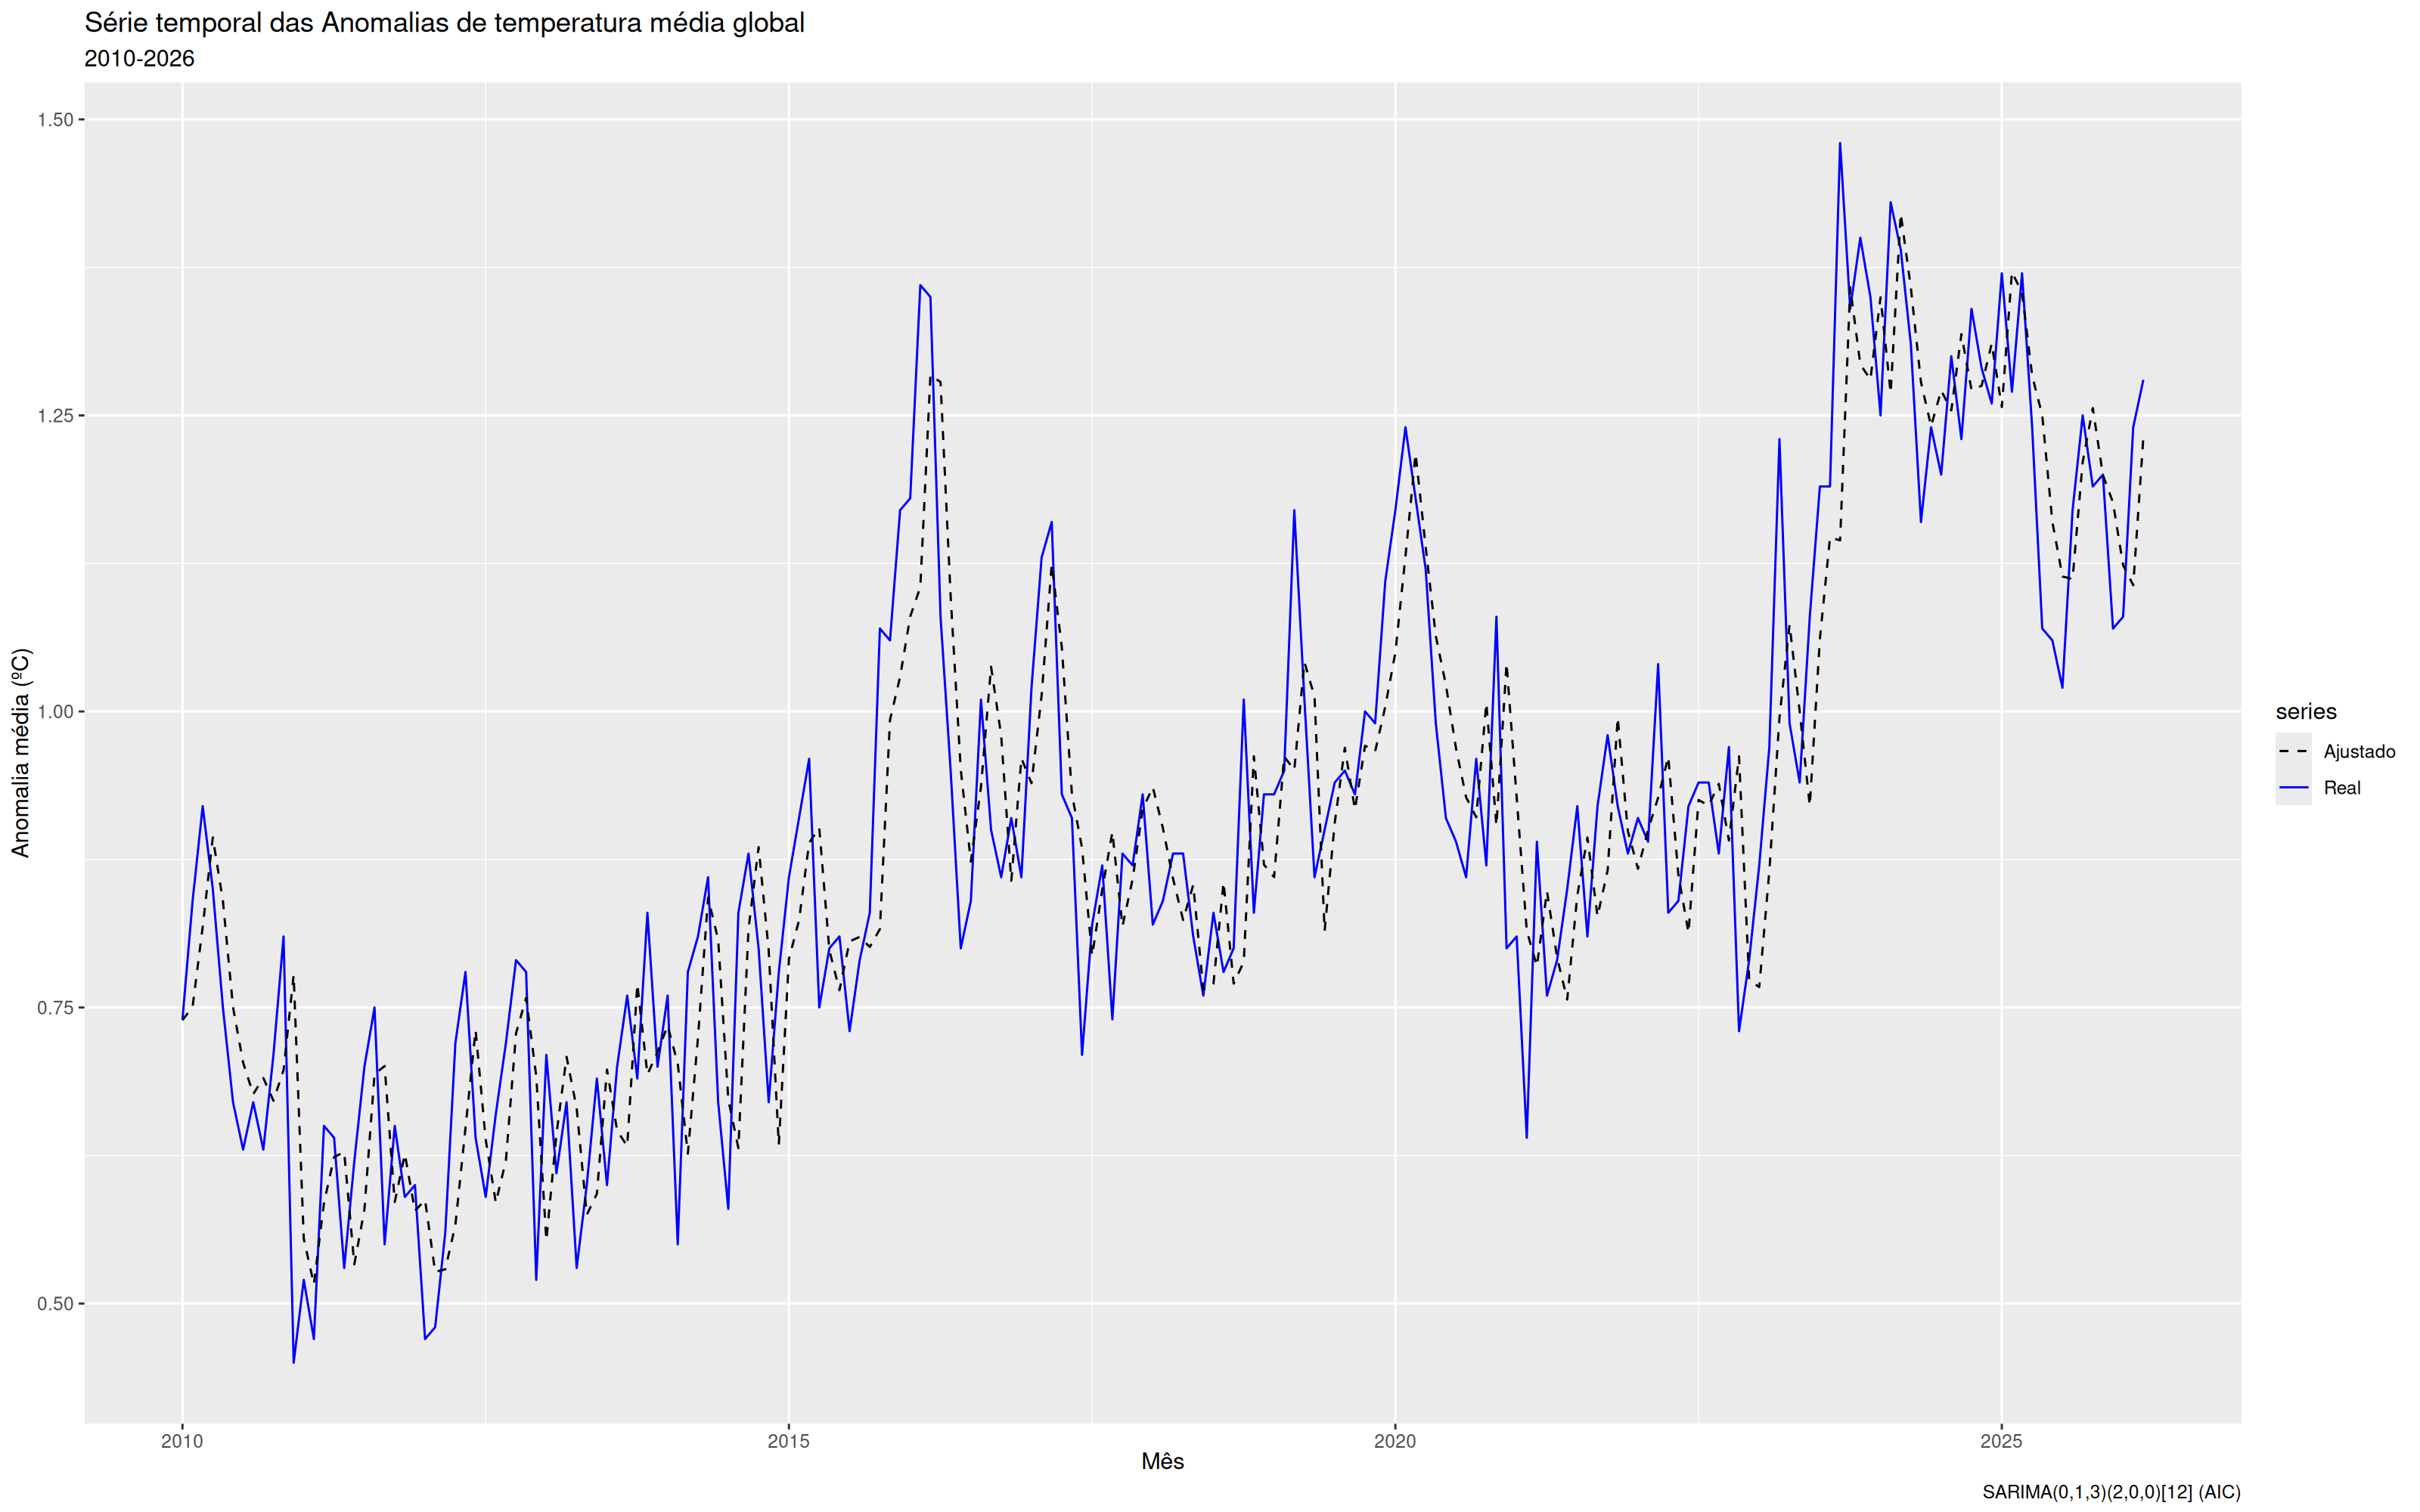

In [27]:
fitted_vals <- fitted(ts_m$models[[1]]$fit)

autoplot(ts_m$ts, series = "Real") +
  autolayer(fitted_vals, series = "Ajustado", linetype = "dashed") +
  labs(
    title = ts_m$title,
    subtitle = ts_m$subtitle,
    x = ts_m$xlabel,
    y = ts_m$ylabel,
    caption = ts_m$models[[1]]$name
  ) +
  scale_colour_manual(values = c("black", "blue"))


#### Testes de diagnóstico

In [28]:
data.frame(
  test = c("Ljung-Box", "ARCH", "Shapiro-Wilk", "Lilliefors", "Jarque-Bera"),
  h0 = c("resíduos não correlacionados", "variância constante", rep("há normalidade", 3)),
  alpha = rep(sig_level, 5),
  p_value = c(
    ts_m$models[[1]]$diagnosis$tests$LjungBox$p.value,
    ts_m$models[[1]]$diagnosis$tests$ARCH$p.value,
    ts_m$models[[1]]$diagnosis$tests$Shapiro$p.value,
    ts_m$models[[1]]$diagnosis$tests$Lilliefors$p.value,
    ts_m$models[[1]]$diagnosis$tests$JarqueBera$p.value
  )
) |>
  mutate(reject_h0 = p_value < alpha) |>
  gt() |>
	tab_header(sprintf("Diagnóstico do modelo %s", ts_m$models[[1]]$name)) |>
  cols_label(
    test = "Teste",
    h0 = md("$\\mathcal{H}_{0}$"),
    alpha = md("$\\alpha$"),
    p_value = "P-valor",
    reject_h0 = md("Rejeitar $\\mathcal{H}_{0}?$")
  ) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

#### checkresiduals do modelo

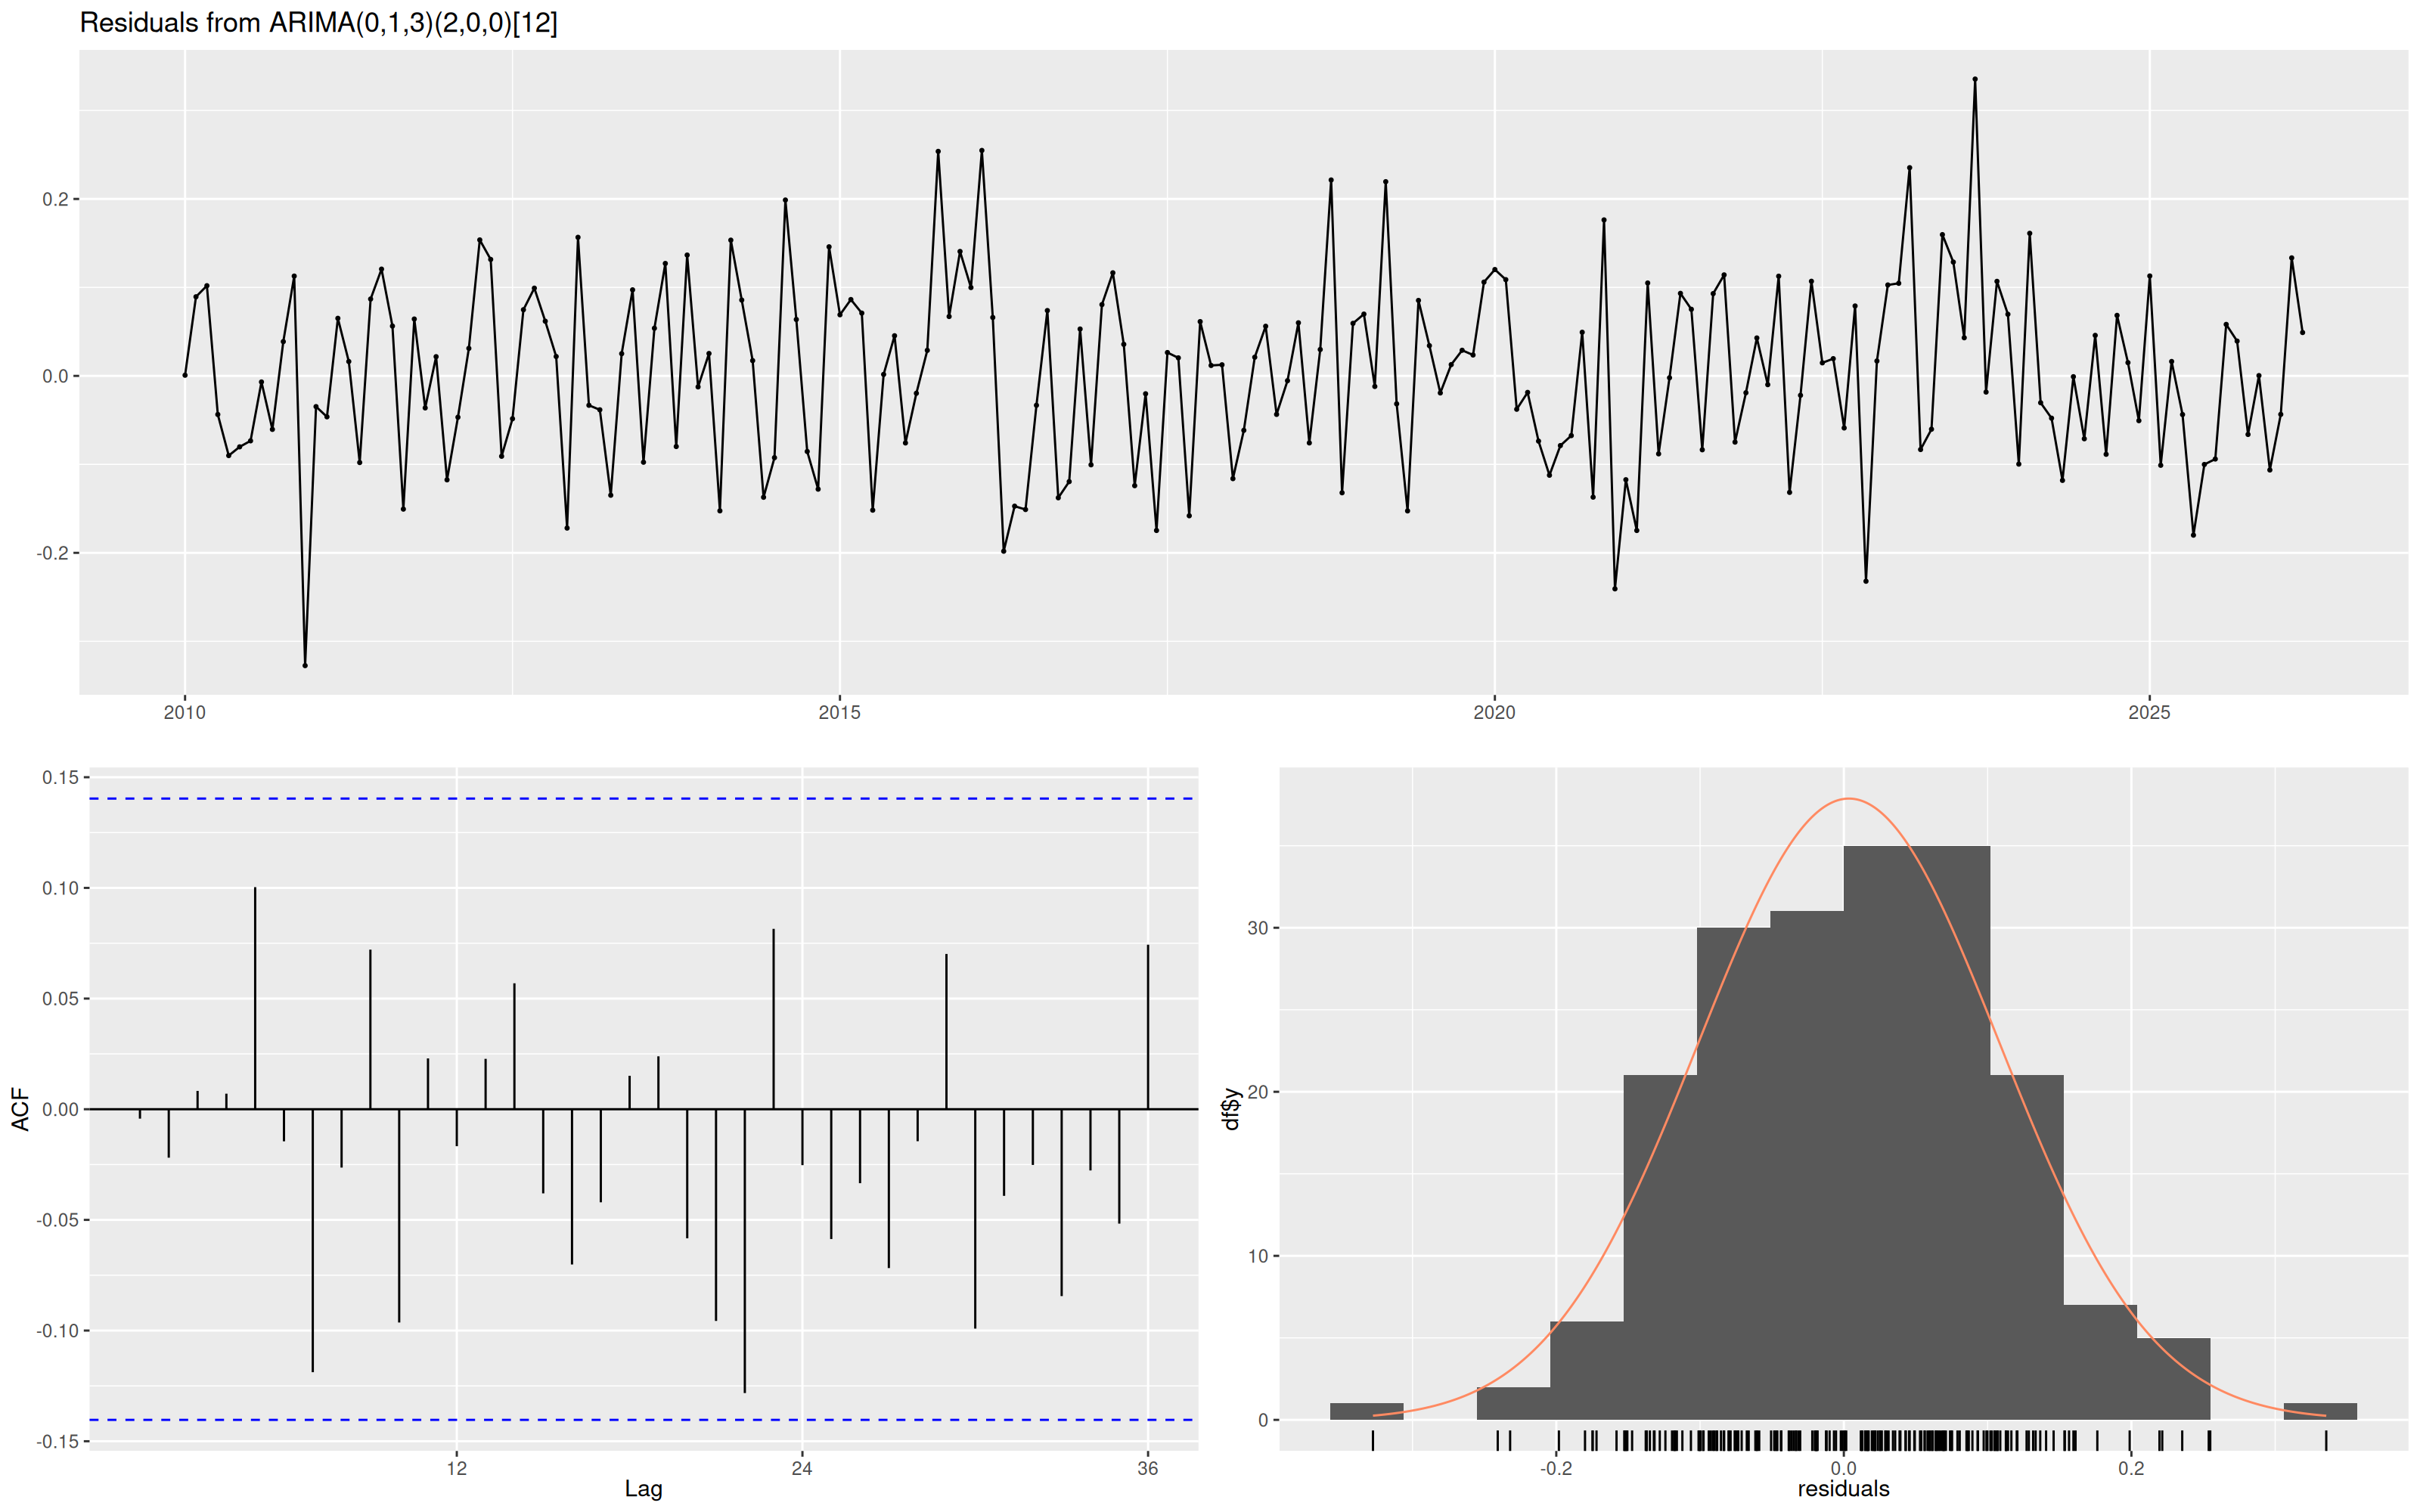

In [29]:
capture_out <- capture.output(checkresiduals(ts_m$models[[1]]$fit))

### BIC

#### Teste dos coeficientes

In [30]:
ncoef <-  ts_m$models[[2]]$orders["p"] + ts_m$models[[2]]$orders["q"] + ts_m$models[[2]]$orders["P"] + ts_m$models[[2]]$orders["Q"]

coef_test <- as.data.frame(coeftest(ts_m$models[[2]]$fit)[1:ncoef, ])
coef_test <- mutate(.data = coef_test, coefficients = rownames(coef_test), .before = 1)

coef_test |>
  gt(rowname_col = "coefficients") |>
	tab_header(sprintf("Teste dos coeficientes: %s", ts_m$models[[2]]$name)) |>
  tab_options(
      table.width = "70%",
      table.background.color = "rgba(0, 0, 0, 0)",
      table.font.color.light = "black",
      table.font.weight = "700",
      column_labels.background.color = "#eeeeee",
      column_labels.font.weight = "bold",
      column_labels.font.size = "1.12rem",
      column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

#### Gráfico: valores reais vs valores ajustados (in-sample)

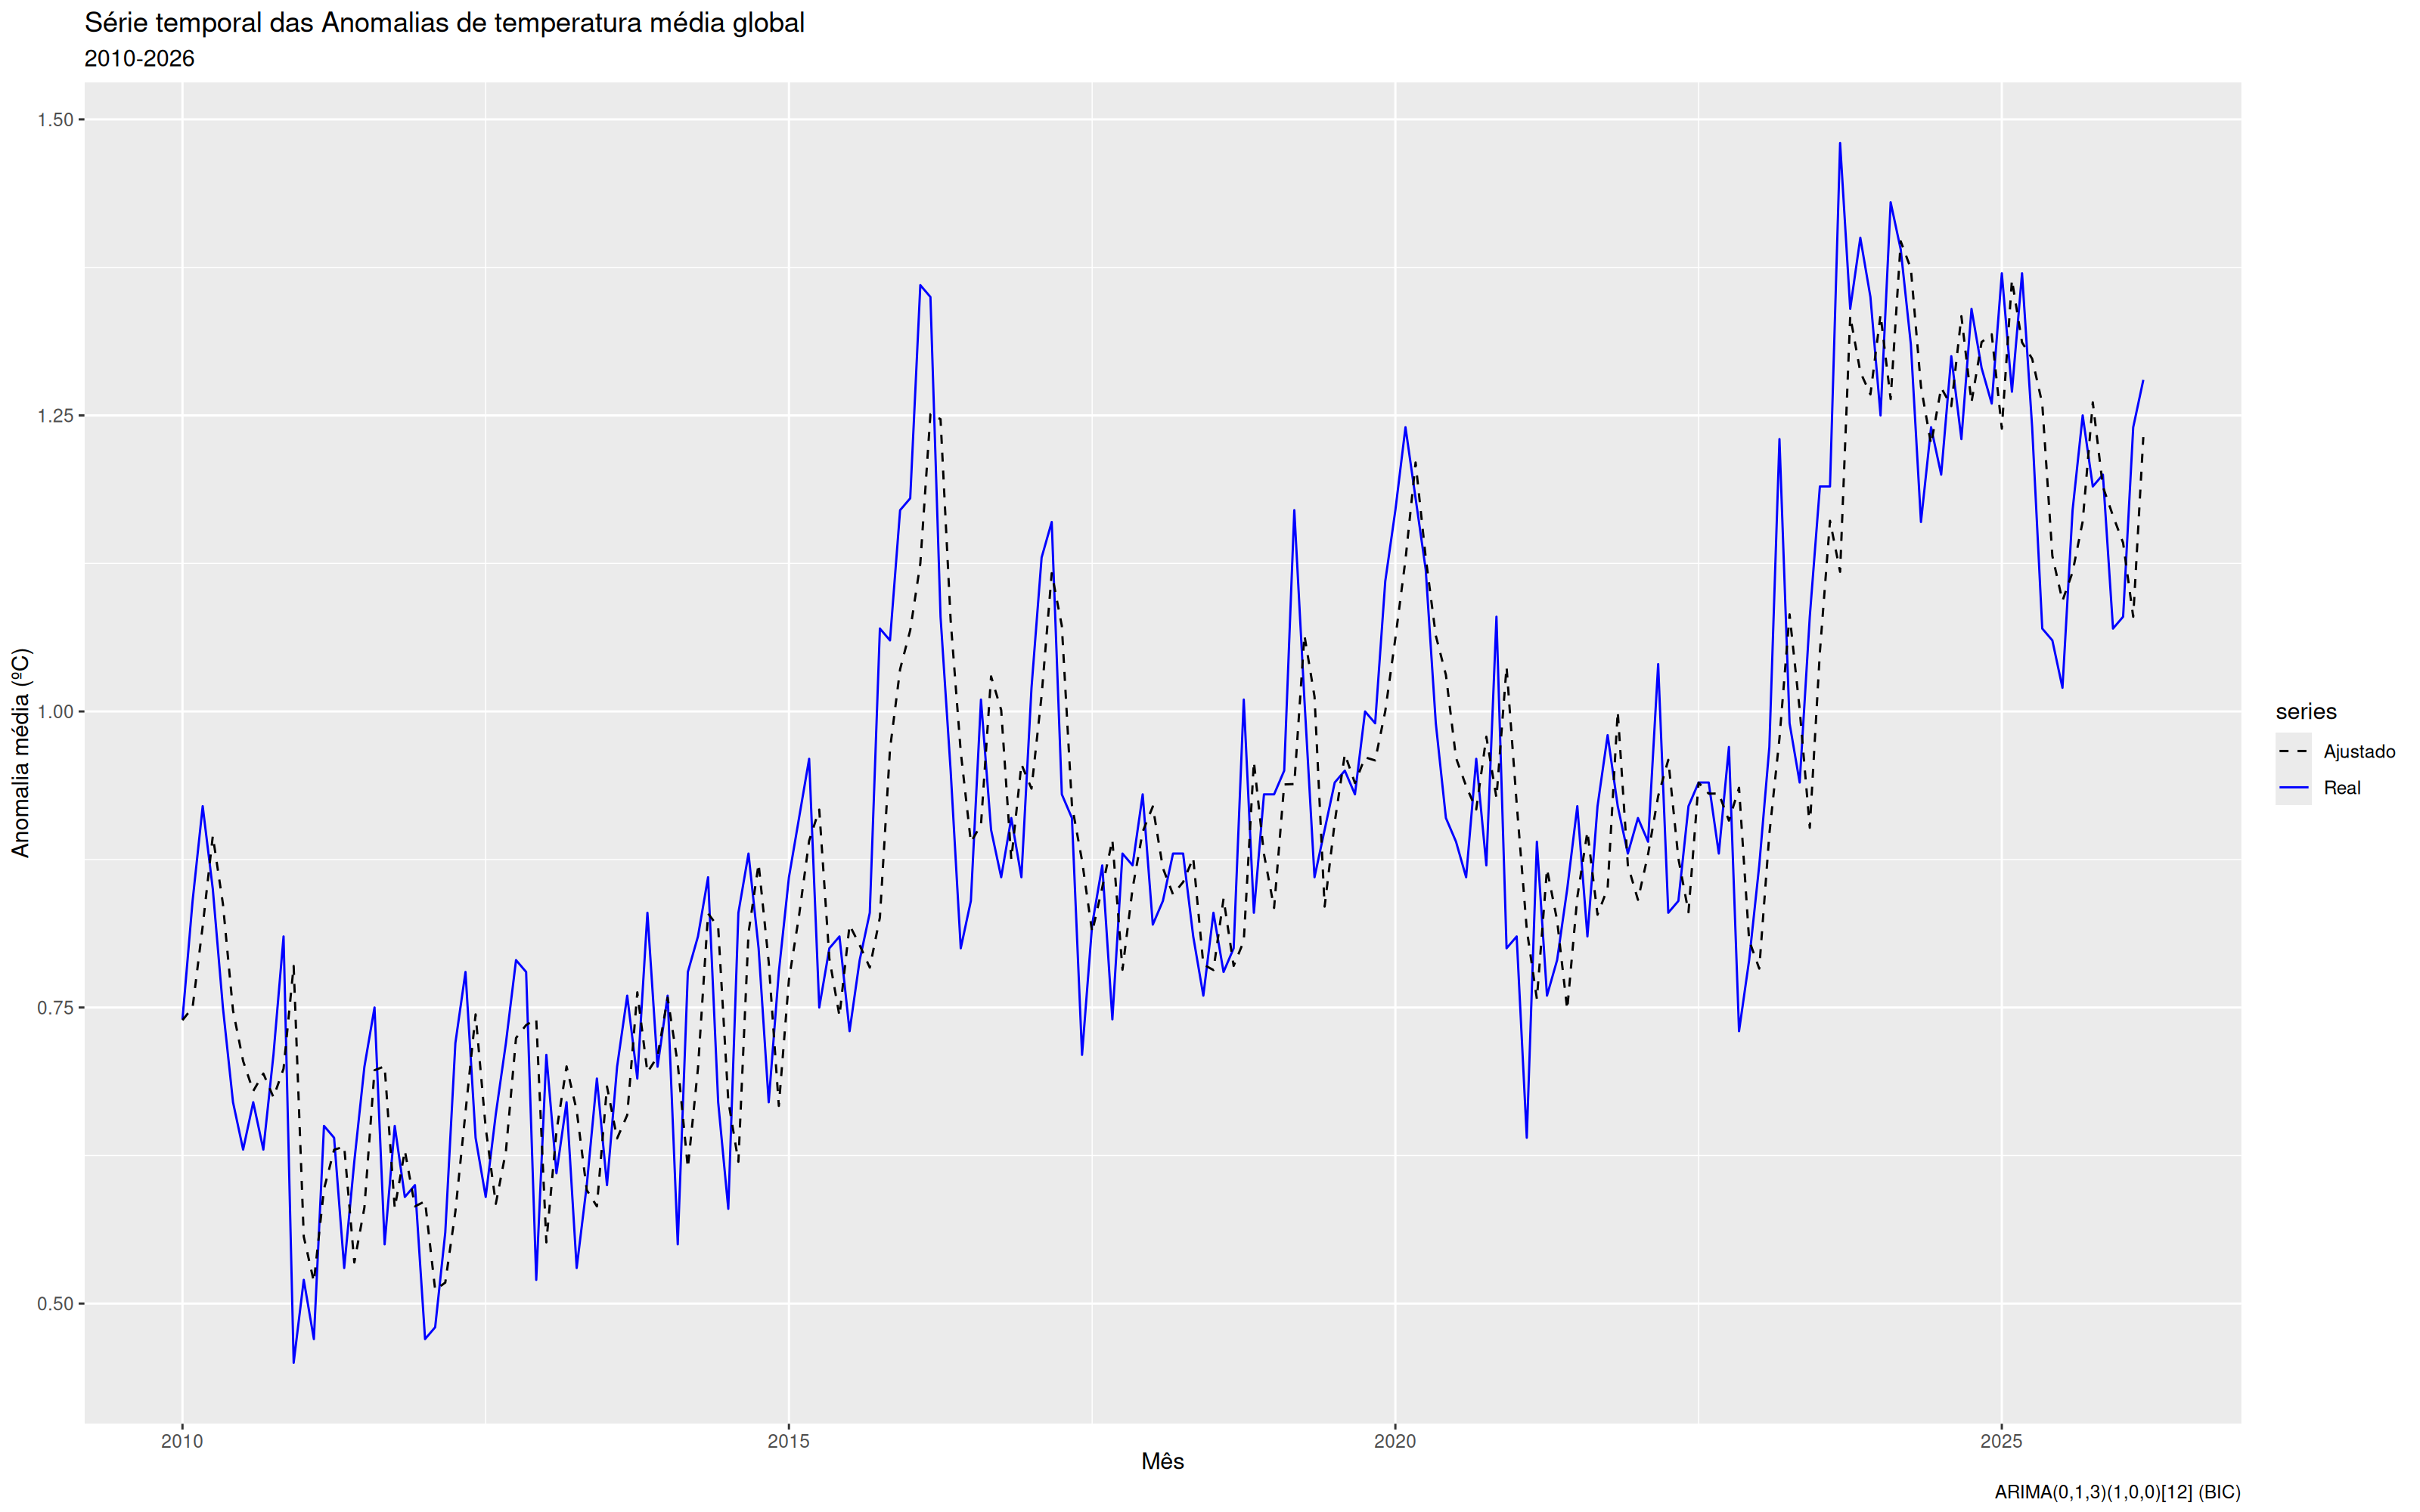

In [31]:
fitted_vals <- fitted(ts_m$models[[2]]$fit)

autoplot(ts_m$ts, series = "Real") +
  autolayer(fitted_vals, series = "Ajustado", linetype = "dashed") +
  labs(
    title = ts_m$title,
    subtitle = ts_m$subtitle,
    x = ts_m$xlabel,
    y = ts_m$ylabel,
    caption = ts_m$models[[2]]$name
  ) +
  scale_colour_manual(values = c("black", "blue"))

#### Testes de diagnóstico

In [32]:
data.frame(
  test = c("Ljung-Box", "ARCH", "Shapiro-Wilk", "Lilliefors", "Jarque-Bera"),
  h0 = c("resíduos não correlacionados", "variância constante", rep("há normalidade", 3)),
  alpha = rep(sig_level, 5),
  p_value = c(
    ts_m$models[[2]]$diagnosis$tests$LjungBox$p.value,
    ts_m$models[[2]]$diagnosis$tests$ARCH$p.value,
    ts_m$models[[2]]$diagnosis$tests$Shapiro$p.value,
    ts_m$models[[2]]$diagnosis$tests$Lilliefors$p.value,
    ts_m$models[[2]]$diagnosis$tests$JarqueBera$p.value
  )
) |>
  mutate(reject_h0 = p_value < alpha) |>
  gt() |>
  cols_label(
    test = "Teste",
    h0 = md("$\\mathcal{H}_{0}$"),
    alpha = md("$\\alpha$"),
    p_value = "P-valor",
    reject_h0 = md("Rejeitar $\\mathcal{H}_{0}?$")
  ) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Teste,H0\mathcal{H}_{0}H0​,α\alphaα,P-valor,Rejeitar H0?\mathcal{H}_{0}?H0​?
Ljung-Box,resíduos não correlacionados,0.05,0.2694757,FALSE
ARCH,variância constante,0.05,0.7233182,FALSE
Shapiro-Wilk,há normalidade,0.05,0.3946704,FALSE
Lilliefors,há normalidade,0.05,0.2412073,FALSE
Jarque-Bera,há normalidade,0.05,0.8650574,FALSE


#### checkresiduals do modelo

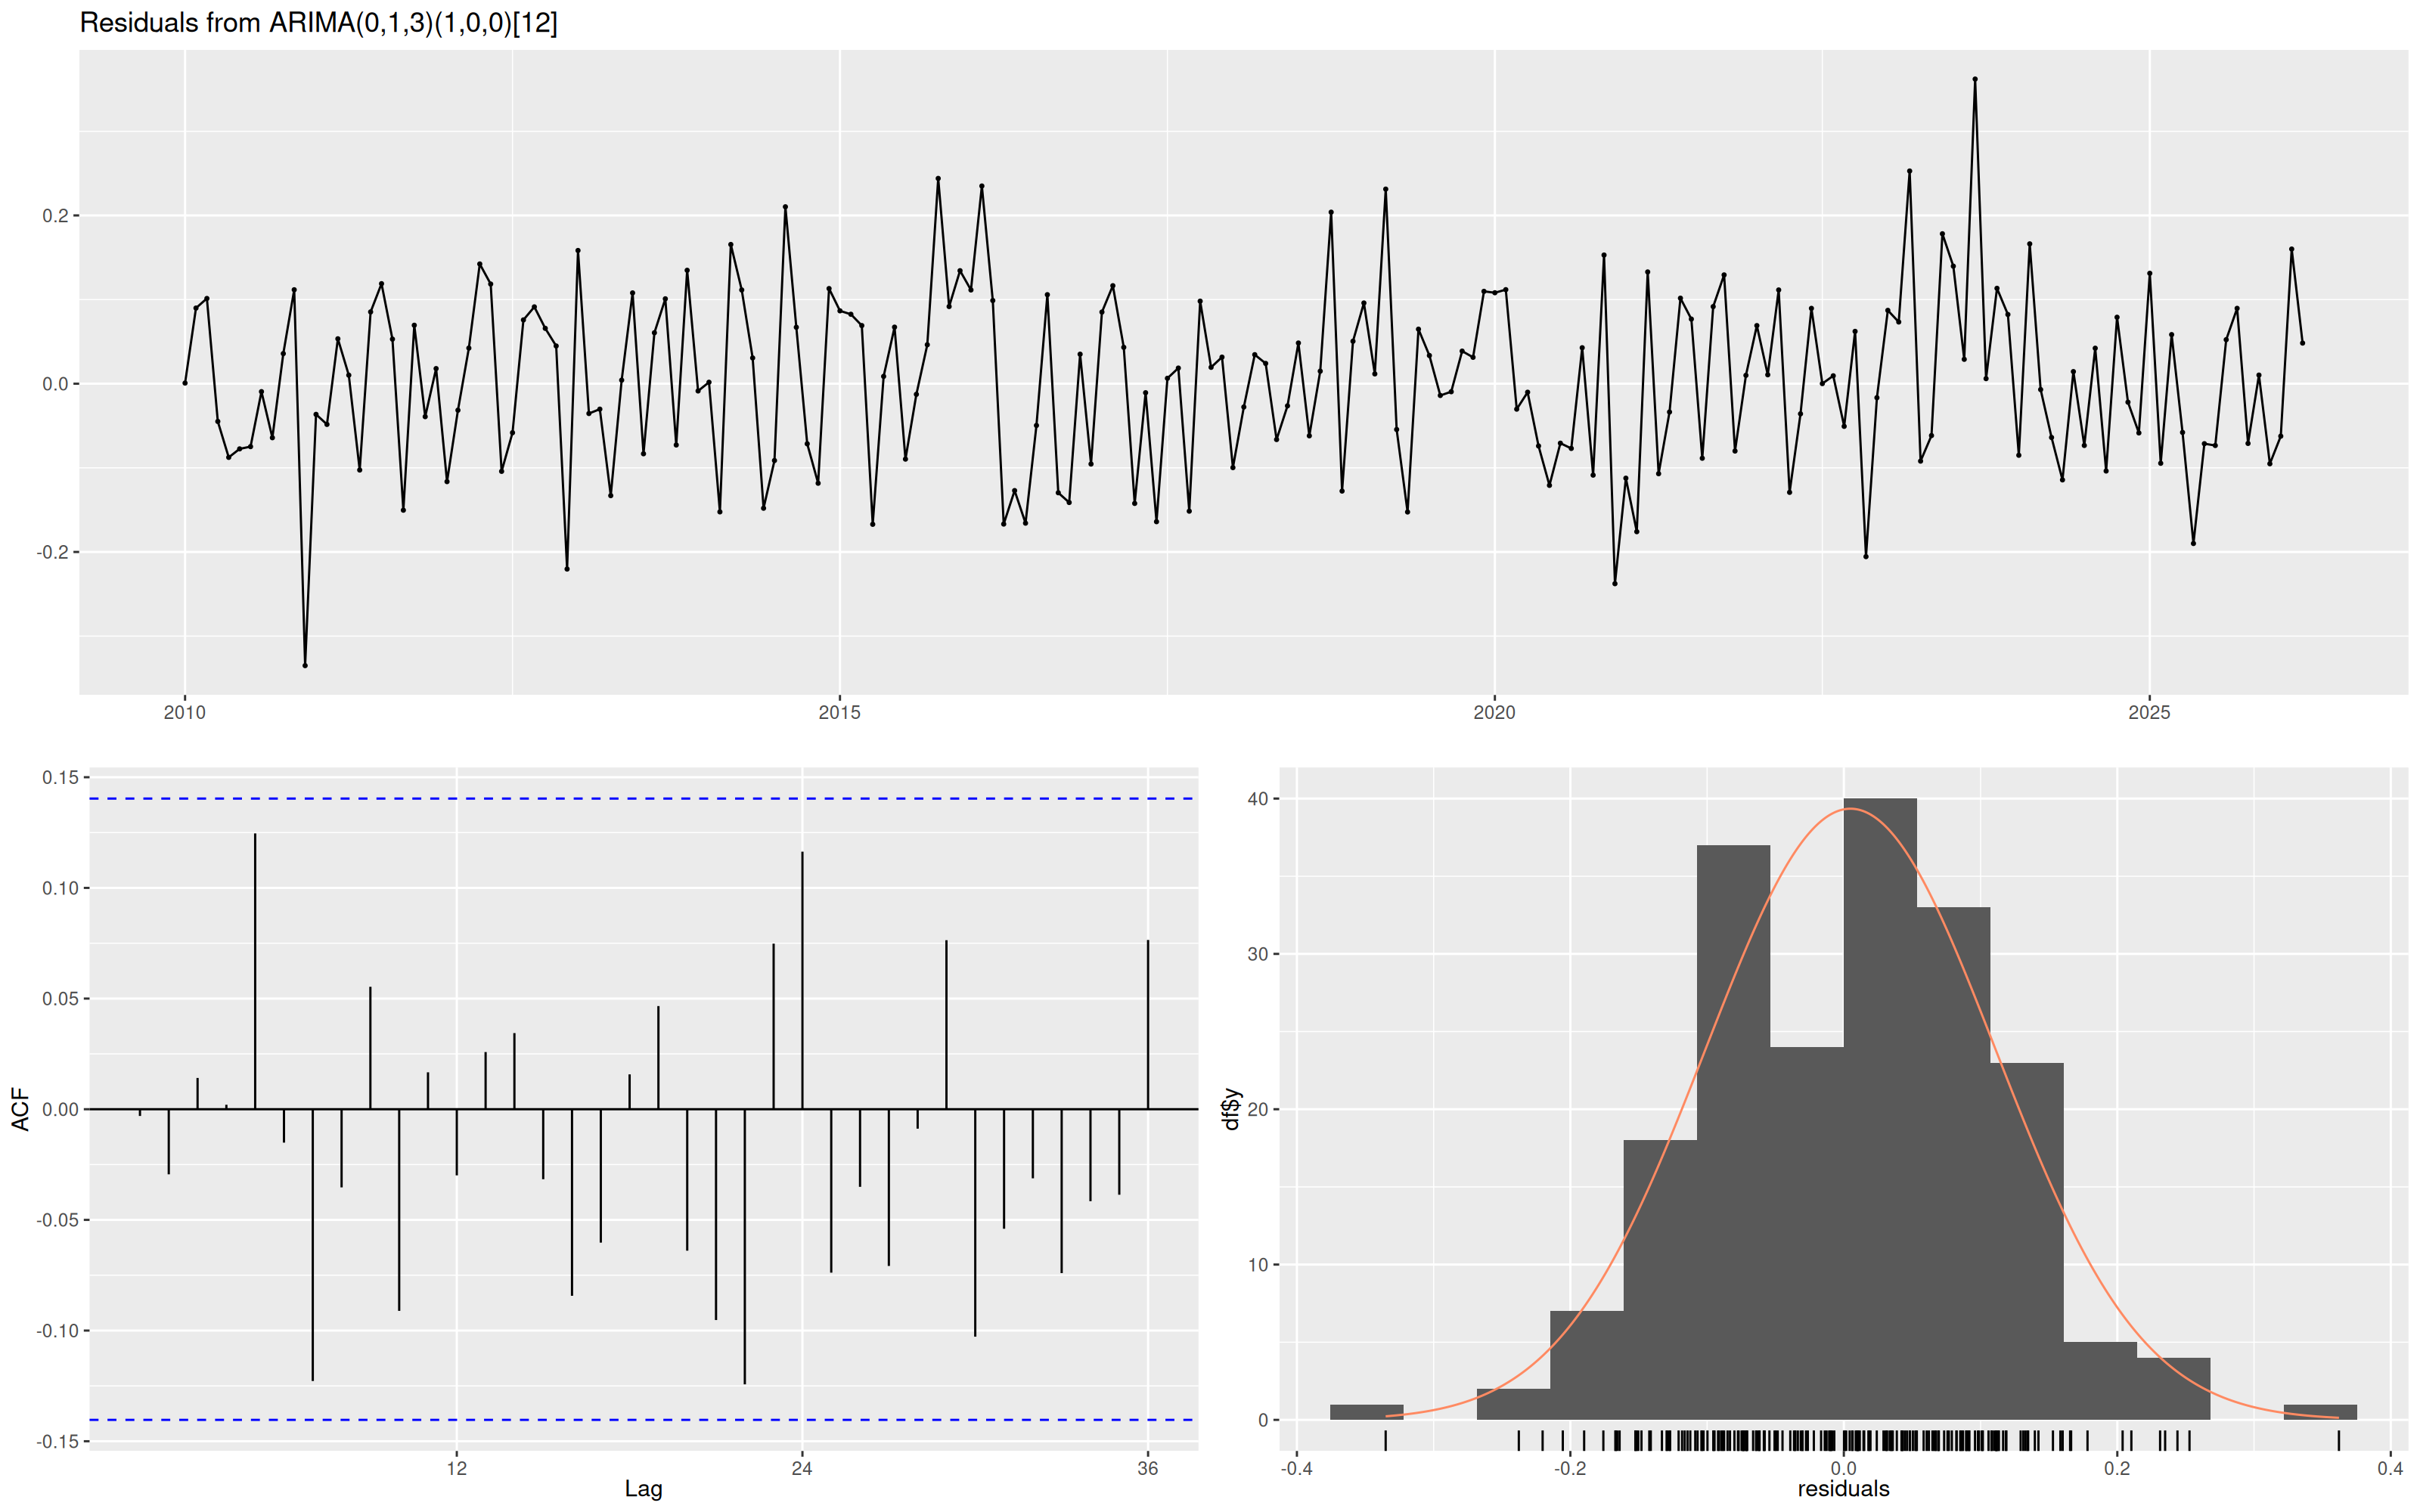

In [33]:
capture_out <- capture.output(checkresiduals(ts_m$models[[2]]$fit))

## Modelos ARIMAX

Vamos agora ajustar dois modelos SARIMAX com a inclusão de uma variável regressora que representa as anomalias médias da temperatura da superfície do mar na região Niño 3.4.
O período de referência utilizado é o mesmo da série principal, janeiro de 2005 a março de 2026.

In [38]:
ts_m$models <- c(
  ts_m$models,
  ajusta_modelo(ts_m$ts, "aic", 3, sig_level = 0.05, xreg = nina34$Mean),
  ajusta_modelo(ts_m$ts, "bic", 3, sig_level = 0.05, xreg = nina34$Mean)
)

ts_m$models[[3]]$name <- sprintf(
  "ARIMAX(%d,%d,%d)(%d,%d,%d)[%d] (AIC)",
  ts_m$models[[3]]$orders["p"],
  ts_m$models[[3]]$orders["d"],
  ts_m$models[[3]]$orders["q"],
  ts_m$models[[3]]$orders["P"],
  ts_m$models[[3]]$orders["D"],
  ts_m$models[[3]]$orders["Q"],
  ts_m$freq
)

ts_m$models[[4]]$name <- sprintf(
  "ARIMAX(%d,%d,%d)(%d,%d,%d)[%d] (BIC)",
  ts_m$models[[4]]$orders["p"],
  ts_m$models[[4]]$orders["d"],
  ts_m$models[[4]]$orders["q"],
  ts_m$models[[4]]$orders["P"],
  ts_m$models[[4]]$orders["D"],
  ts_m$models[[4]]$orders["Q"],
  ts_m$freq
)

Warning message in executa_auto(ts_series, criterio, n, xreg = xreg):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "aic", 3, sig_level = 0.05, xreg = nina34$Mean):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "aic", 3, sig_level = 0.05, xreg = nina34$Mean):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "aic", 3, sig_level = 0.05, xreg = nina34$Mean):
“NAs introduced by coercion”
Warning message in executa_auto(ts_series, criterio, n, xreg = xreg):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "bic", 3, sig_level = 0.05, xreg = nina34$Mean):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "bic", 3, sig_level = 0.05, xreg = nina34$Mean):
“NAs introduced by coercion”
Warning message in ajusta_modelo(ts_m$ts, "bic", 3, sig_level = 0.05, xreg = nina34$Mean):
“NAs introduced by coercion”


In [39]:
resumo_modelos_arimax <- tibble(
  Modelo = c(ts_m$models[[3]]$name, ts_m$models[[4]]$name),
  p = c(ts_m$models[[3]]$orders["p"], ts_m$models[[4]]$orders["p"]),
  d = c(ts_m$models[[3]]$orders["d"], ts_m$models[[4]]$orders["d"]),
  q = c(ts_m$models[[3]]$orders["q"], ts_m$models[[4]]$orders["q"]),
  P = c(ts_m$models[[3]]$orders["P"], ts_m$models[[4]]$orders["P"]),
  D = c(ts_m$models[[3]]$orders["D"], ts_m$models[[4]]$orders["D"]),
  Q = c(ts_m$models[[3]]$orders["Q"], ts_m$models[[4]]$orders["Q"])
)

resumo_modelos_arimax |>
  gt() |>
	tab_header("Modelos ARIMAX obtidos") |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(align = "center", columns = everything()) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

### AIC

#### Teste dos coeficientes

In [40]:
ncoef <-  ts_m$models[[3]]$orders["p"] + ts_m$models[[3]]$orders["q"] + ts_m$models[[3]]$orders["P"] + ts_m$models[[3]]$orders["Q"] + 1

coef_test <- as.data.frame(coeftest(ts_m$models[[3]]$fit)[1:ncoef, ])
coef_test <- mutate(.data = coef_test, coefficients = rownames(coef_test), .before = 1)

coef_test |>
  gt(rowname_col = "coefficients") |>
	tab_header(sprintf("Teste dos coeficientes: %s", ts_m$models[[3]]$name)) |>
  tab_options(
      table.width = "70%",
      table.background.color = "rgba(0, 0, 0, 0)",
      table.font.color.light = "black",
      table.font.weight = "700",
      column_labels.background.color = "#eeeeee",
      column_labels.font.weight = "bold",
      column_labels.font.size = "1.12rem",
      column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

In [41]:
cor(avg_gtemp$Mean, nina34$Mean)

[1] 0.4267862

#### Gráfico: valores reais vs valores ajustados (in-sample)

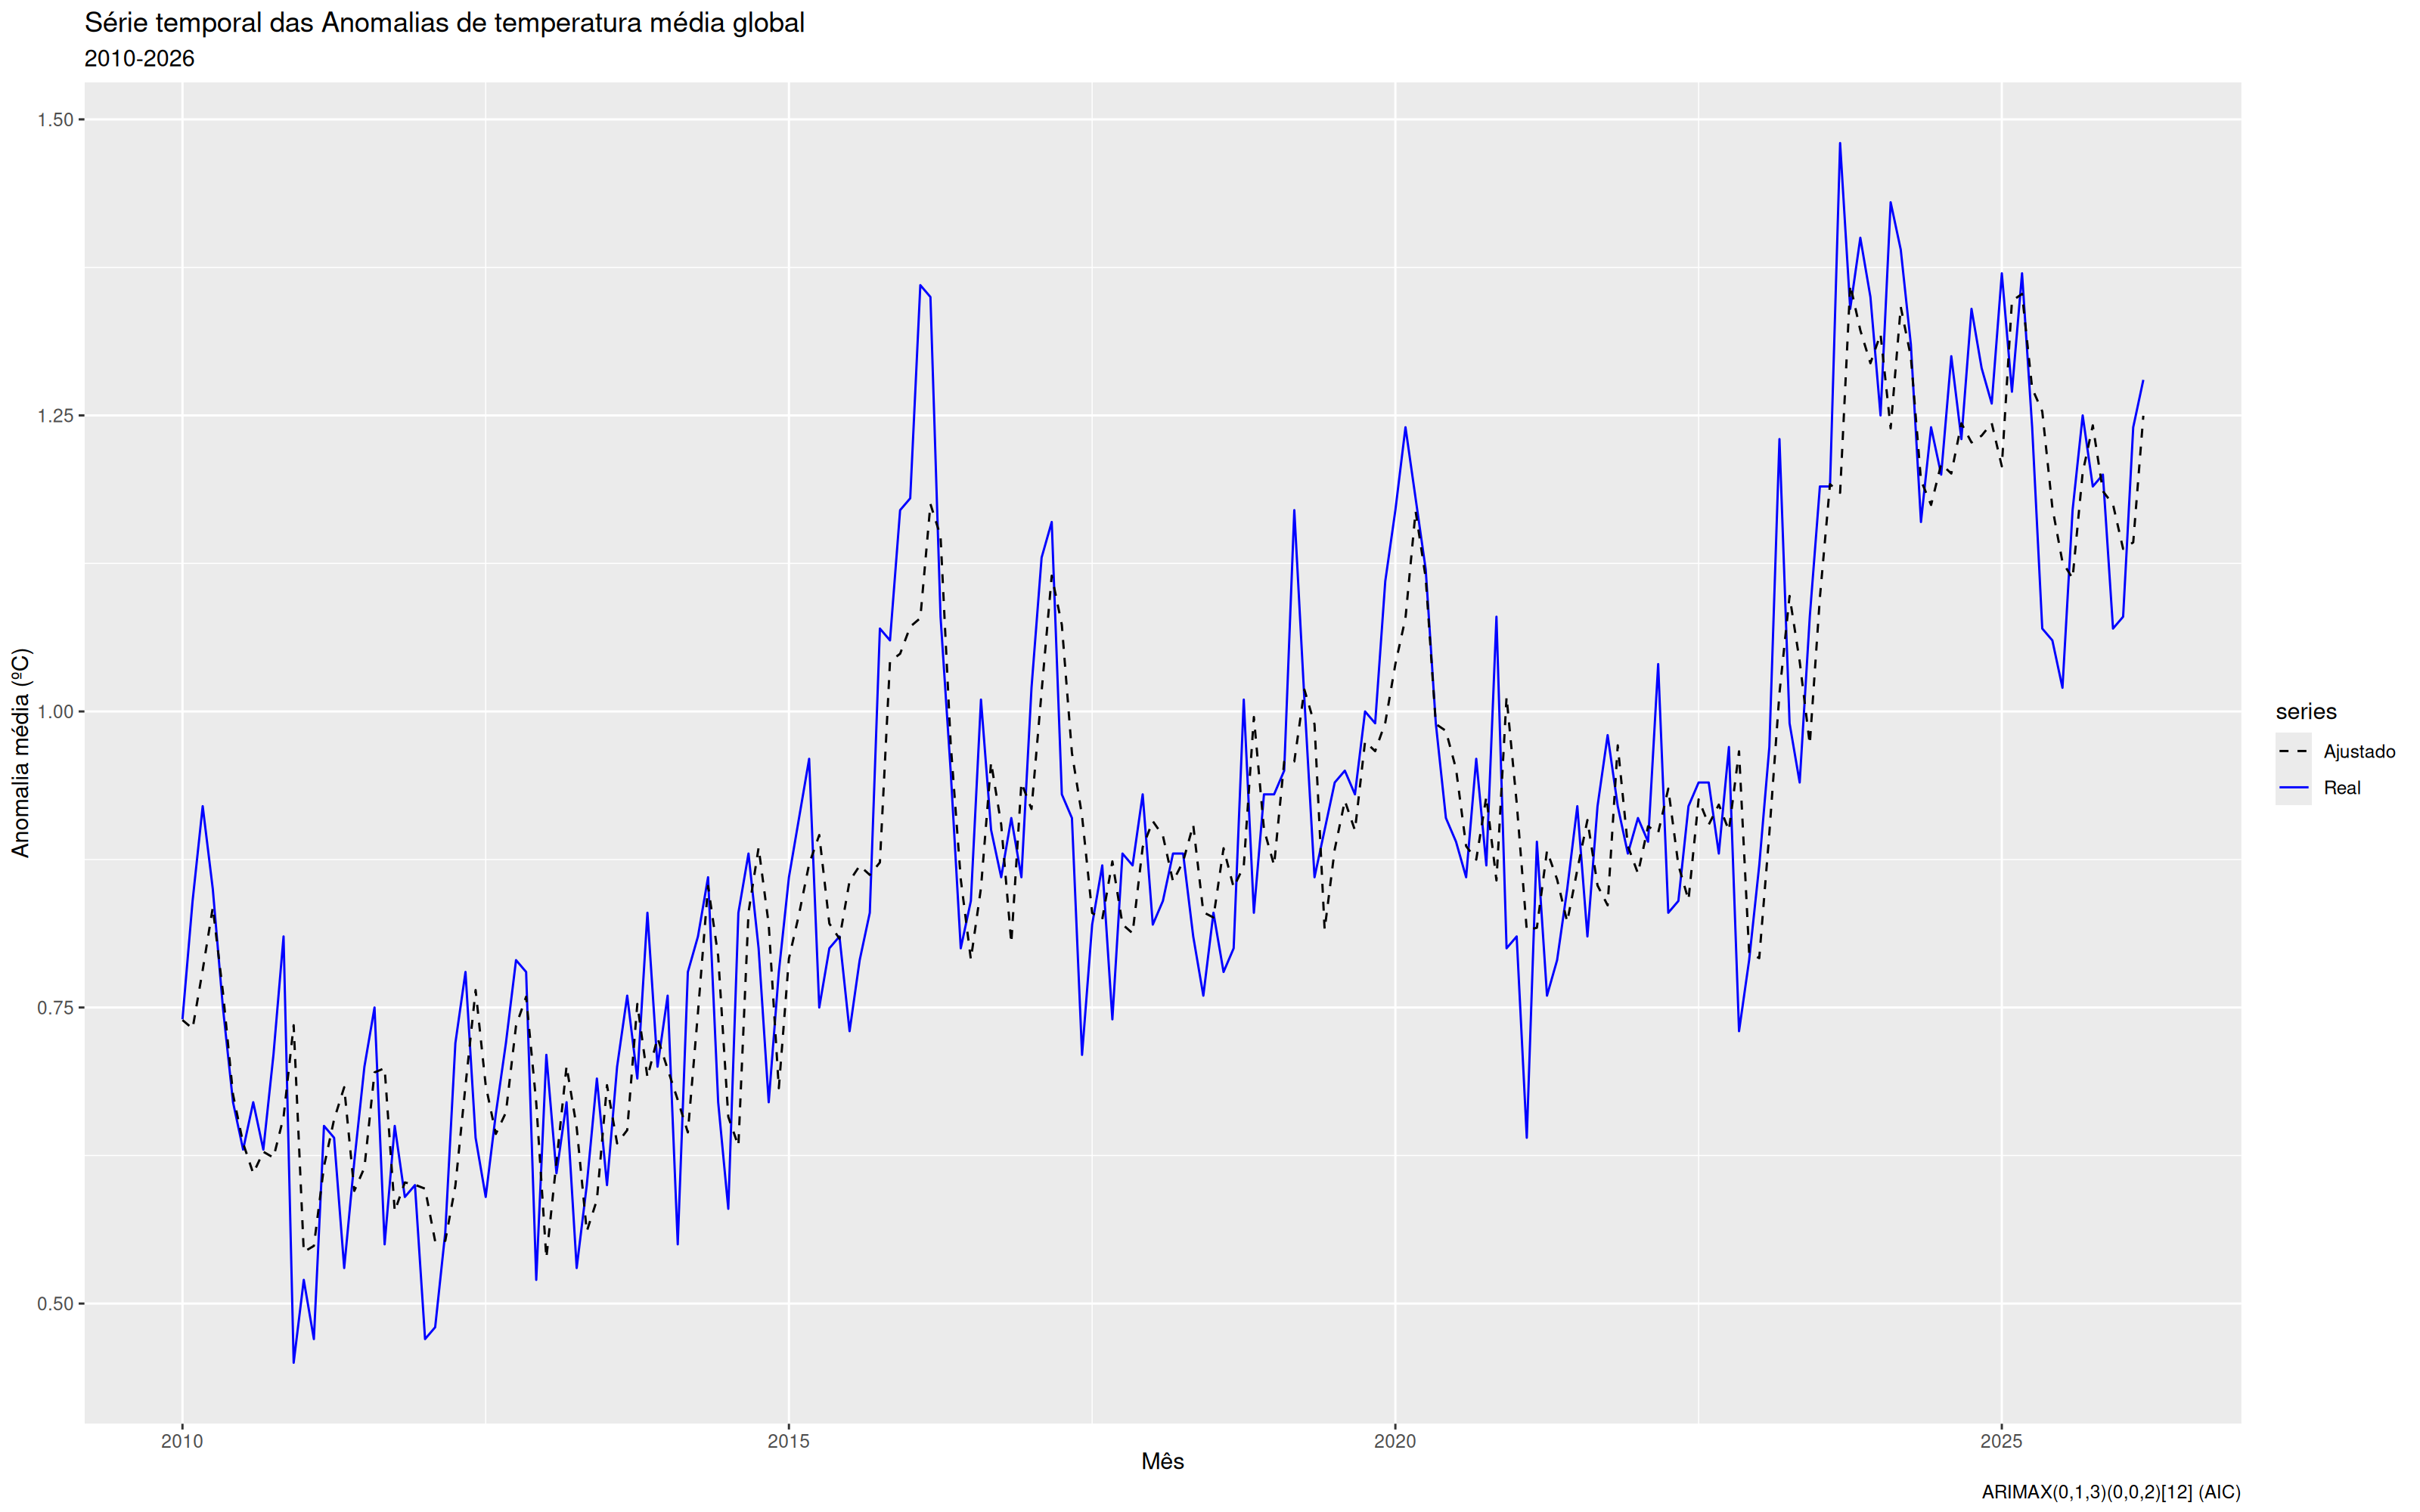

In [42]:
fitted_vals <- fitted(ts_m$models[[3]]$fit)

autoplot(ts_m$ts, series = "Real") +
  autolayer(fitted_vals, series = "Ajustado", linetype = "dashed") +
  labs(
    title = ts_m$title,
    subtitle = ts_m$subtitle,
    x = ts_m$xlabel,
    y = ts_m$ylabel,
    caption = ts_m$models[[3]]$name
  ) +
  scale_colour_manual(values = c("black", "blue"))

#### Testes de diagnóstico

In [43]:
data.frame(
  test = c("Ljung-Box", "ARCH", "Shapiro-Wilk", "Lilliefors", "Jarque-Bera"),
  h0 = c("resíduos não correlacionados", "variância constante", rep("há normalidade", 3)),
  alpha = rep(sig_level, 5),
  p_value = c(
    ts_m$models[[3]]$diagnosis$tests$LjungBox$p.value,
    ts_m$models[[3]]$diagnosis$tests$ARCH$p.value,
    ts_m$models[[3]]$diagnosis$tests$Shapiro$p.value,
    ts_m$models[[3]]$diagnosis$tests$Lilliefors$p.value,
    ts_m$models[[3]]$diagnosis$tests$JarqueBera$p.value
  )
) |>
  mutate(reject_h0 = p_value < alpha) |>
  gt() |>
	tab_header(sprintf("Diagnóstico do modelo %s", ts_m$models[[3]]$name)) |>
  cols_label(
    test = "Teste",
    h0 = md("$\\mathcal{H}_{0}$"),
    alpha = md("$\\alpha$"),
    p_value = "P-valor",
    reject_h0 = md("Rejeitar $\\mathcal{H}_{0}?$")
  ) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

#### checkresiduals do modelo

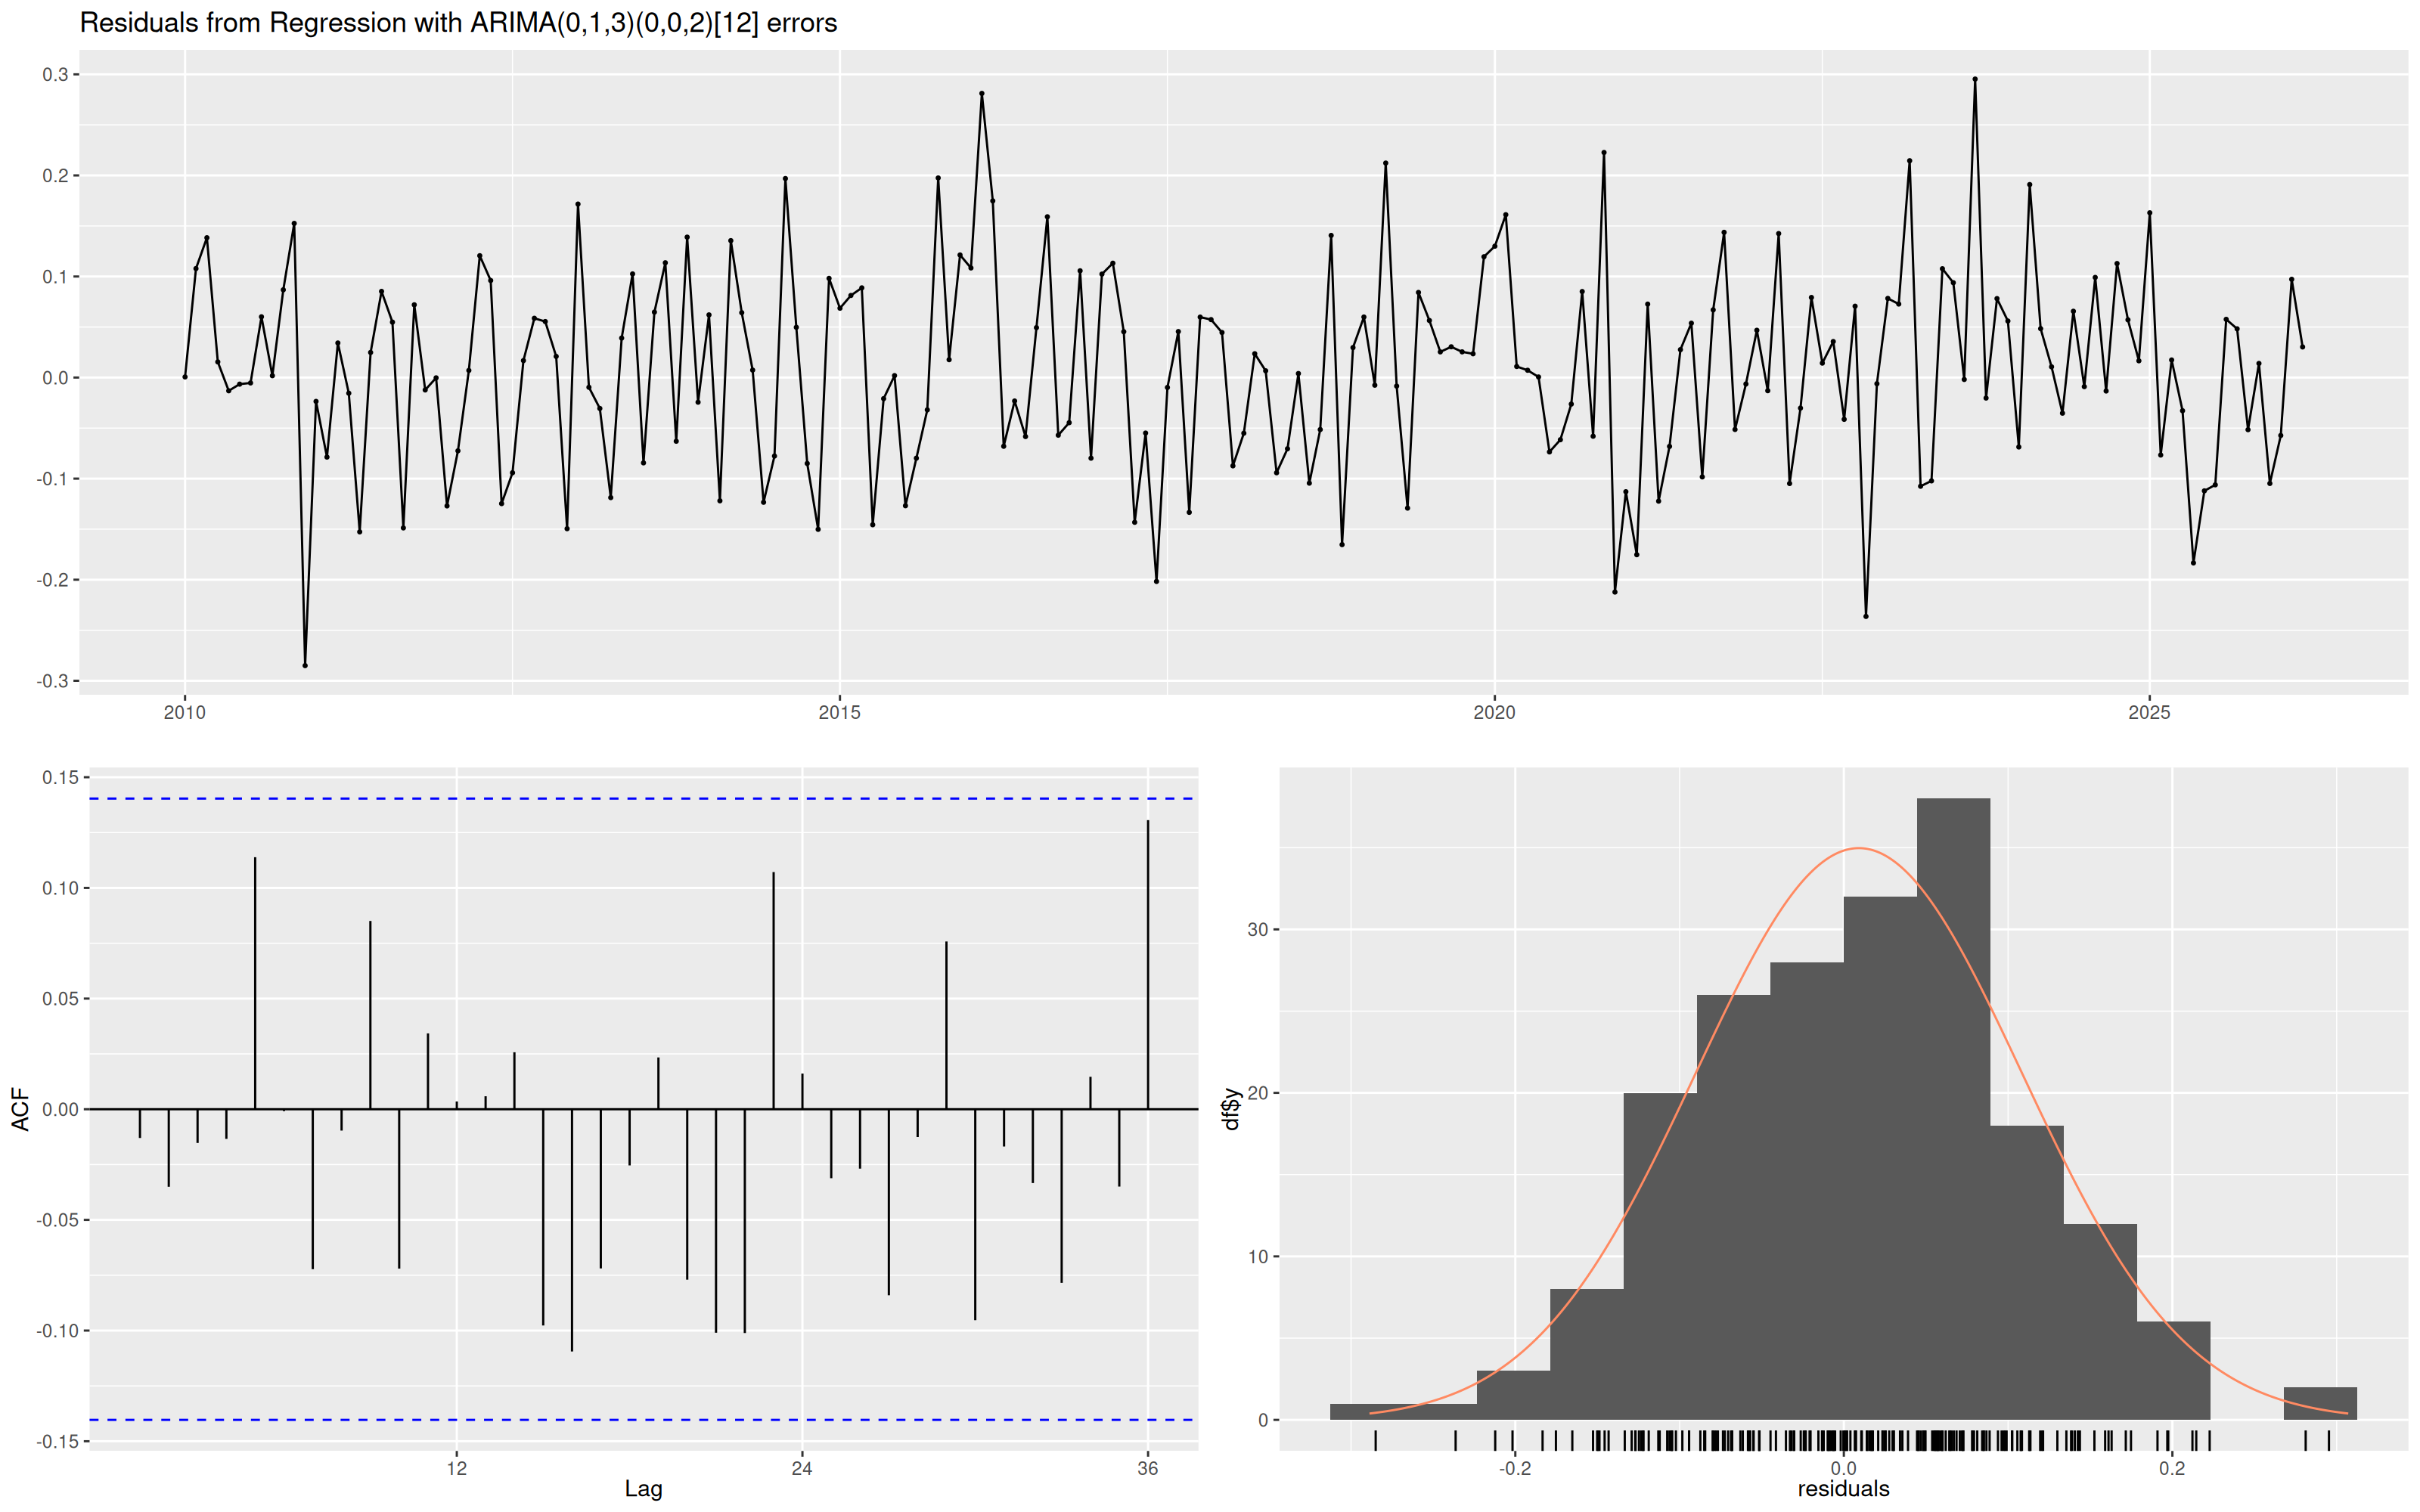

In [44]:
capture_out <- capture.output(checkresiduals(ts_m$models[[3]]$fit))

### BIC

#### Teste dos coeficientes

In [45]:
ncoef <-  ts_m$models[[4]]$orders["p"] + ts_m$models[[4]]$orders["q"] + ts_m$models[[4]]$orders["P"] + ts_m$models[[4]]$orders["Q"] + 1

coef_test <- as.data.frame(coeftest(ts_m$models[[4]]$fit)[1:ncoef, ])
coef_test <- mutate(.data = coef_test, coefficients = rownames(coef_test), .before = 1)

coef_test |>
  gt(rowname_col = "coefficients") |>
	tab_header(sprintf("Teste dos coeficientes: %s", ts_m$models[[4]]$name)) |>
  tab_options(
      table.width = "70%",
      table.background.color = "rgba(0, 0, 0, 0)",
      table.font.color.light = "black",
      table.font.weight = "700",
      column_labels.background.color = "#eeeeee",
      column_labels.font.weight = "bold",
      column_labels.font.size = "1.12rem",
      column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

O teste dos coeficientes indica que a regressão da média mensal de manchas solares **não** é significativa para o período de 2005-2026, nesse modelo ARIMAX obtido pelo critéiro de informação BIC.

#### Gráfico: valores reais vs valores ajustados (in-sample)

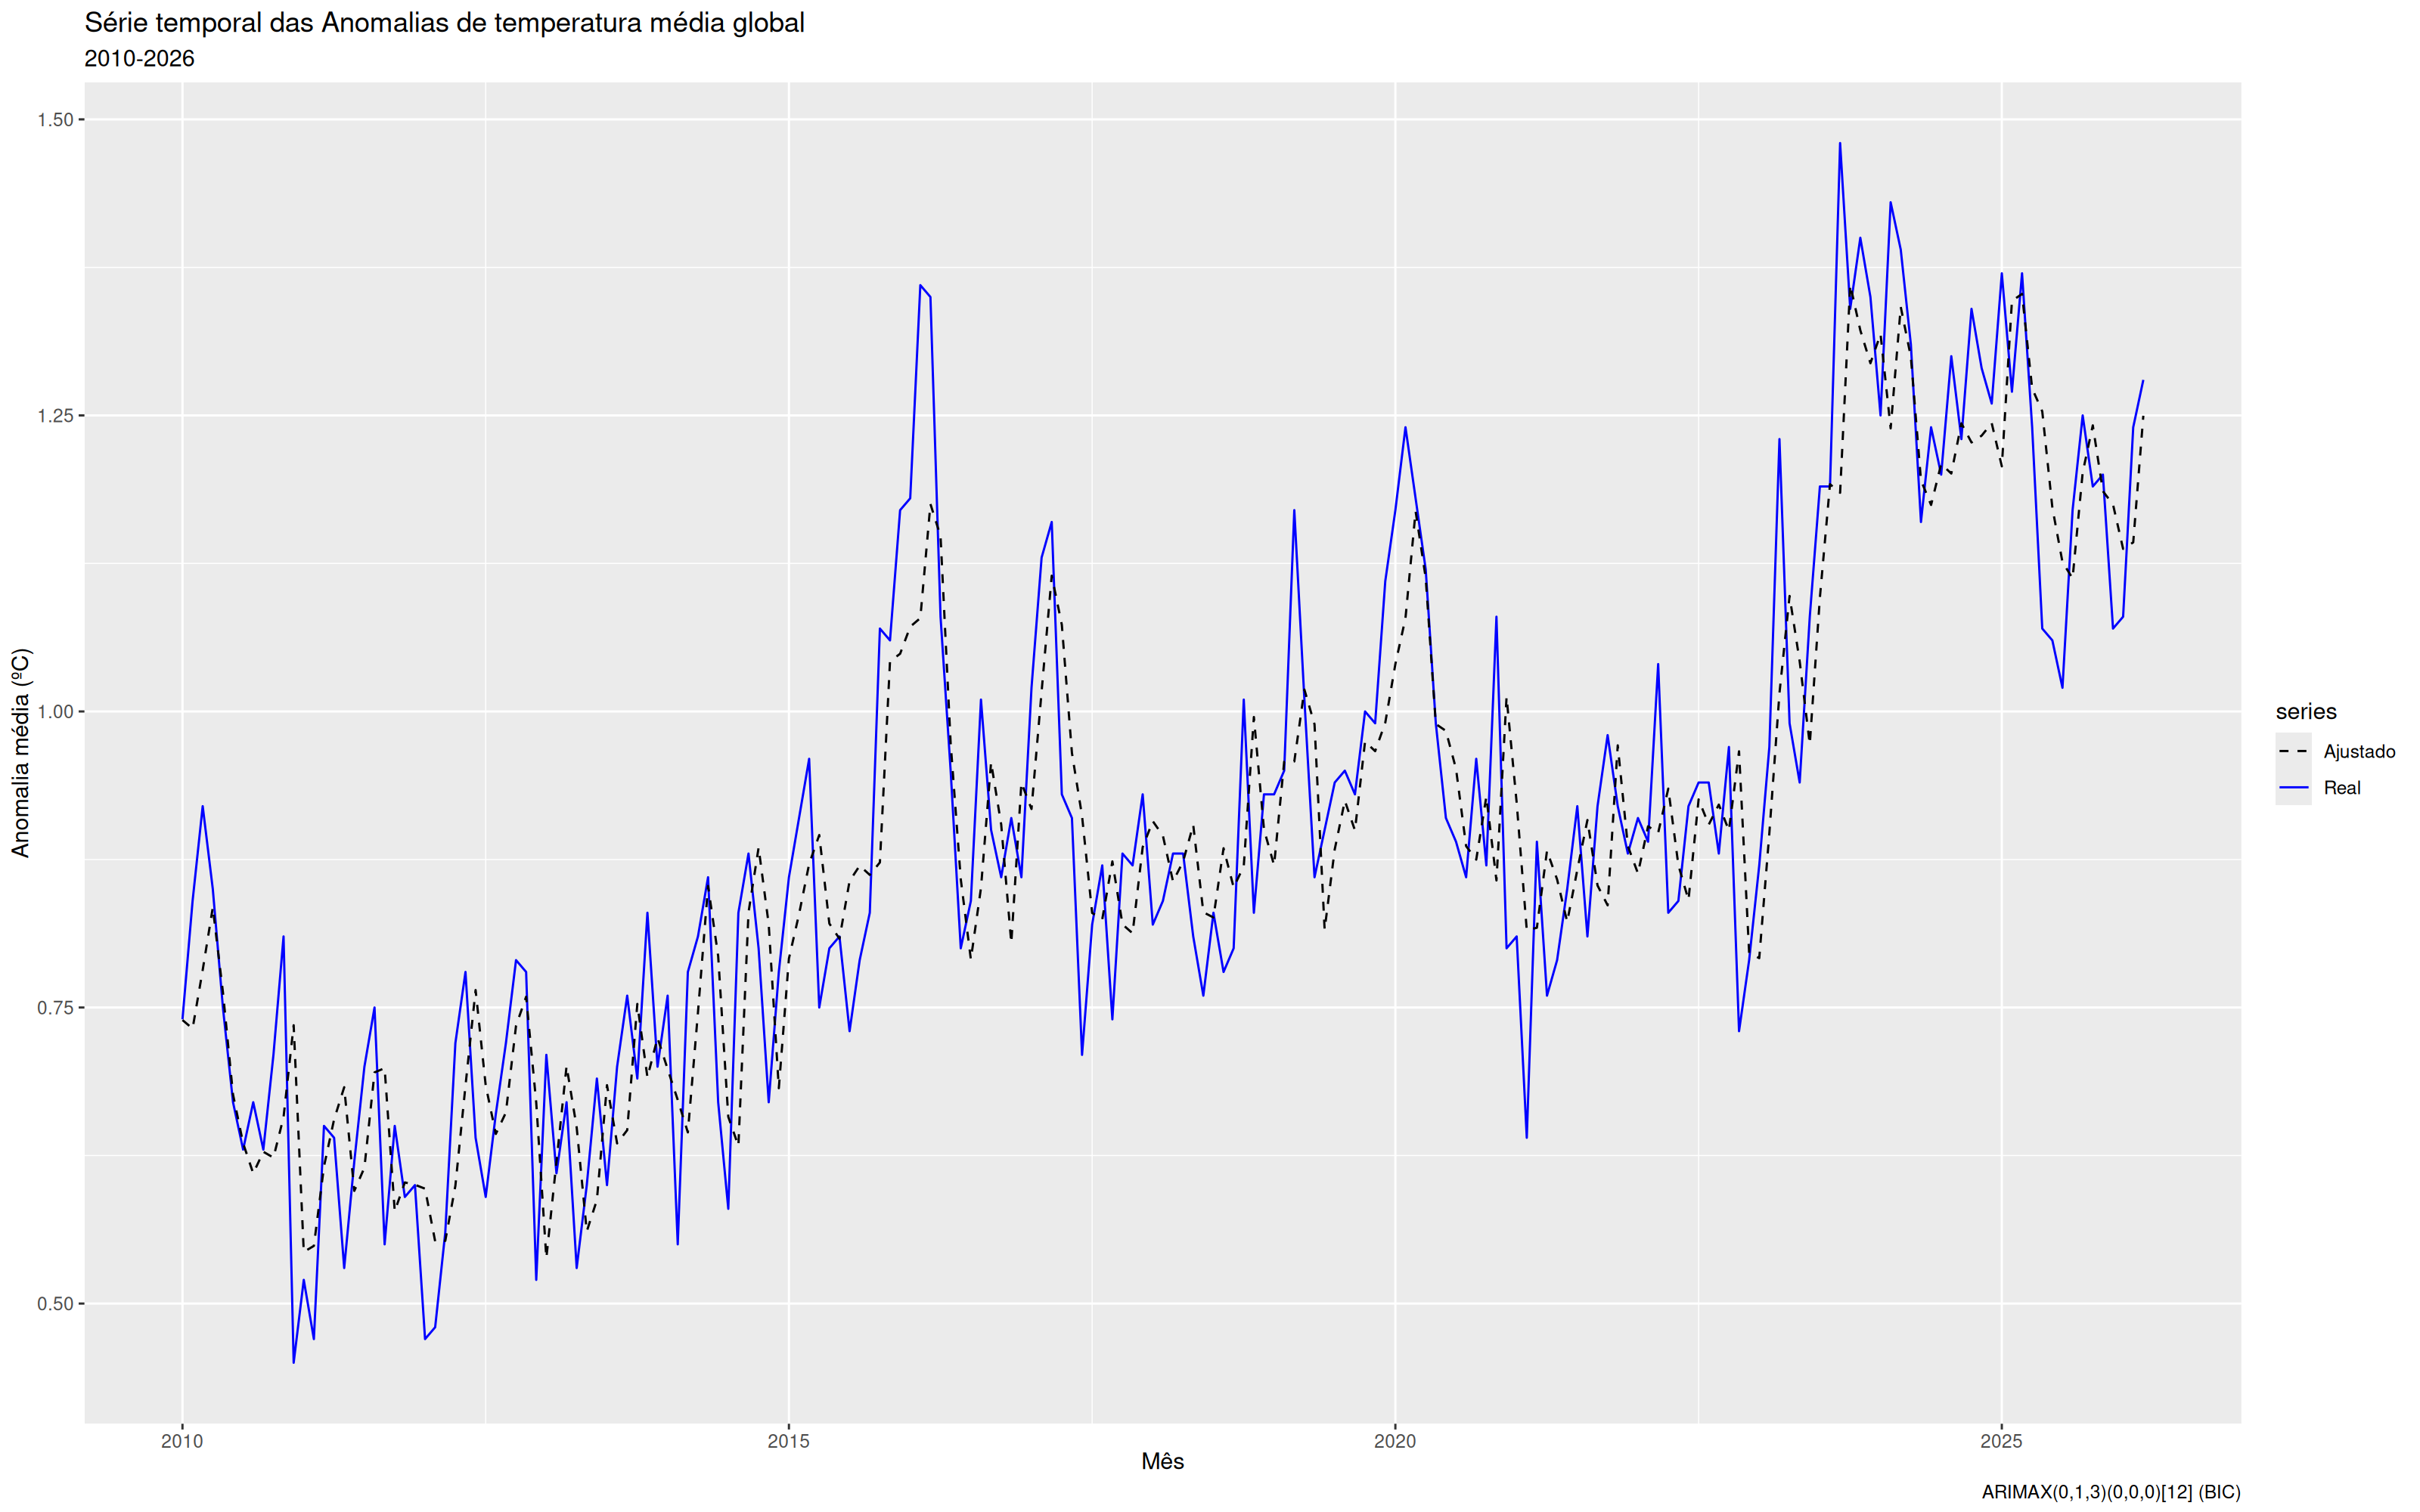

In [46]:
autoplot(ts_m$ts, series = "Real") +
  autolayer(fitted_vals, series = "Ajustado", linetype = "dashed") +
  labs(
    title = ts_m$title,
    subtitle = ts_m$subtitle,
    x = ts_m$xlabel,
    y = ts_m$ylabel,
    caption = ts_m$models[[4]]$name
  ) +
  scale_colour_manual(values = c("black", "blue"))

#### Testes de diagnóstico

In [47]:
data.frame(
  test = c("Ljung-Box", "ARCH", "Shapiro-Wilk", "Lilliefors", "Jarque-Bera"),
  h0 = c("resíduos não correlacionados", "variância constante", rep("há normalidade", 3)),
  alpha = rep(sig_level, 5),
  p_value = c(
    ts_m$models[[4]]$diagnosis$tests$LjungBox$p.value,
    ts_m$models[[4]]$diagnosis$tests$ARCH$p.value,
    ts_m$models[[4]]$diagnosis$tests$Shapiro$p.value,
    ts_m$models[[4]]$diagnosis$tests$Lilliefors$p.value,
    ts_m$models[[4]]$diagnosis$tests$JarqueBera$p.value
  )
) |>
  mutate(reject_h0 = p_value < alpha) |>
  gt() |>
	tab_header(sprintf("Diagnóstico do modelo %s", ts_m$models[[4]]$name)) |>
  cols_label(
    test = "Teste",
    h0 = md("$\\mathcal{H}_{0}$"),
    alpha = md("$\\alpha$"),
    p_value = "P-valor",
    reject_h0 = md("Rejeitar $\\mathcal{H}_{0}?$")
  ) |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(columns = everything(), align = "center") |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

#### checkresiduals do modelo

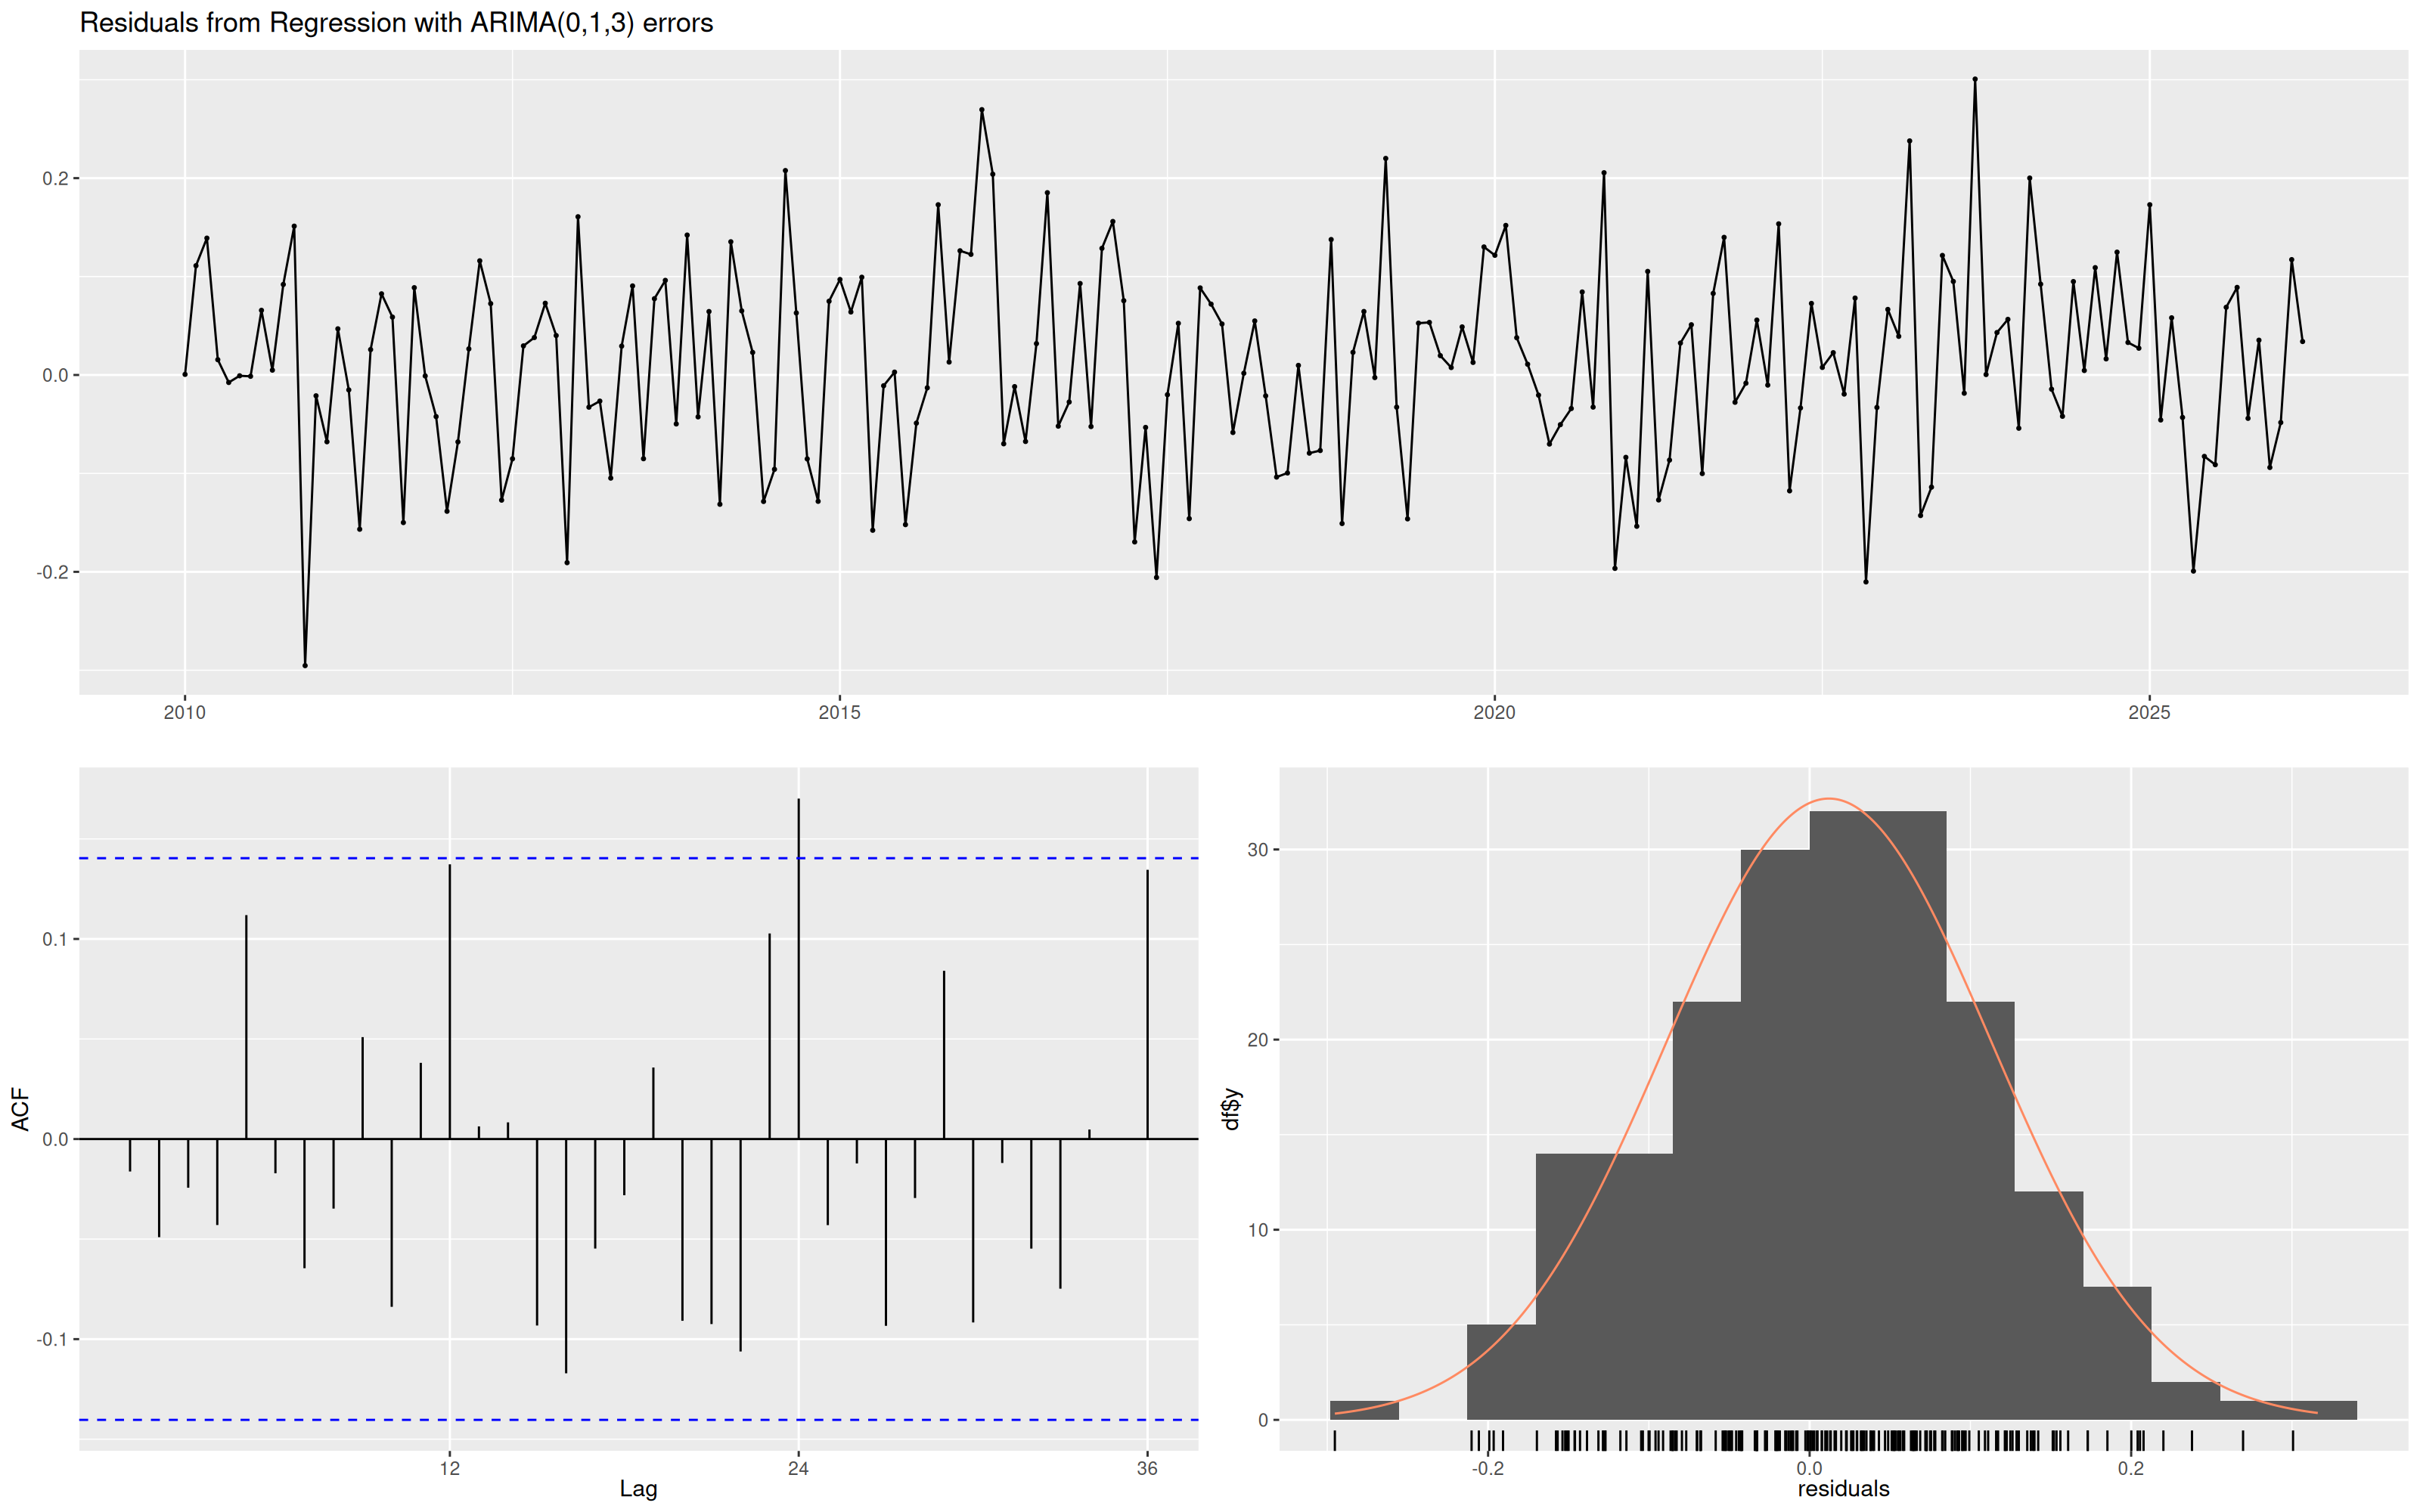

In [48]:
capture_out <- capture.output(checkresiduals(ts_m$models[[4]]$fit))

## Resumo geral - modelos ARIMA/ARIMAX

A tabela a seguir apresenta todos os modelos ARIMA e ARIMAX que foram obtidos até então.

In [49]:
rbind(resumo_modelos_arima, resumo_modelos_arimax) |>
	as.data.frame() |>
  gt() |>
	tab_header("Modelos ARIMA/ARIMAX obtidos") |>
  tab_options(
    table.width = "70%",
    table.background.color = "rgba(0, 0, 0, 0)",
    table.font.color.light = "black",
    table.font.weight = "700",
    column_labels.background.color = "#eeeeee",
    column_labels.font.weight = "bold",
    column_labels.font.size = "1.12rem",
    column_labels.padding = "10px"
  ) |>
  cols_align(align = "center", columns = everything()) |>
	print_gt()

Shiny tags cannot be represented in plain text (need html)

Todos os quatro modelos passaram no testes de diagnóstico que são constituídos por:

- teste de Ljung-Box para verificação da hipótese de resíduos não correlacionados,
- teste ARCH para verificação da hipótese de variância constante dos resíduos ao longo do tempo,
- testes de normalidade de: Shapiro-Wilk, Lilliefors e Jarque-Bera.

Contudo, foi constatado pelo teste dos coeficientes que os modelos ARIMAX, ajustados com a variável exógena de número médio mensal de manchas solares, não foram significativos. 

## Modelo BPARMA

Agora faremos o ajuste de um modelo para a série a partir do novo modelo dinâmico baseado na distribuição Beta-Prime, proposto por **Kleber**.

In [58]:
tail(nina34$Mean, 6)

[1] -0.50 -0.70 -0.67 -0.58 -0.27 -0.01

In [66]:
str(ts(ts_m$ts[1:(length(ts_m$ts) - 6)]))

 Time-Series [1:189] from 1 to 189: 0.74 0.84 0.92 0.85 0.75 0.67 0.63 0.67 0.63 0.71 ...


In [92]:
y <- avg_gtemp[1:(length(avg_gtemp$Mean) - 6),]
subs <- ts(y$Mean, start = c(2010, 1), end = c(2025, 9), freq = 12)
subs

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2010,0.74,0.84,0.92,0.85,0.75,0.67,0.63,0.67,0.63,0.71,0.81,0.45
2011,0.52,0.47,0.65,0.64,0.53,0.62,0.70,0.75,0.55,0.65,0.59,0.60
2012,0.47,0.48,0.56,0.72,0.78,0.64,0.59,0.66,0.72,0.79,0.78,0.52
2013,0.71,0.61,0.67,0.53,0.60,0.69,0.60,0.70,0.76,0.69,0.83,0.70
2014,0.76,0.55,0.78,0.81,0.86,0.67,0.58,0.83,0.88,0.80,0.67,0.78
2015,0.86,0.91,0.96,0.75,0.80,0.81,0.73,0.79,0.83,1.07,1.06,1.17
2016,1.18,1.36,1.35,1.08,0.95,0.80,0.84,1.01,0.90,0.86,0.91,0.86
2017,1.02,1.13,1.16,0.93,0.91,0.71,0.82,0.87,0.74,0.88,0.87,0.93
2018,0.82,0.84,0.88,0.88,0.81,0.76,0.83,0.78,0.80,1.01,0.83,0.93
2019,0.93,0.95,1.17,1.01,0.86,0.90,0.94,0.95,0.93,1.00,0.99,1.11


In [94]:
fit <- gbparma(y = subs, ar = 1, ma = 1,
              mu.link = "log", prec.link = "log", h1 = 6, 
              X = cbind(nina34$Mean[1:(length(nina34$Mean) - 6)]), X_hat = cbind(tail(nina34$Mean, 6)),
							resid = 1, diag = 0)

ERROR: Error in switch(link, logit = {: EXPR must be a length 1 vector


# Referências